# LAST NOTEBOOK: TESTING IMPLEMENTATION INTO UCDMCMC

To make sure the emcee pipeline integrates well into ucdmcmc, we will take the core.py file from ucdmcmc, paste it into a cell below, add the emcee pipeline as well and make sure everything works as intended!

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sys
import itertools
import astropy.units as u
import emcee
import scipy.interpolate
import corner
import copy

sys.path.append("/Users/epritchard/Research/") #these paths are for evan's computer they wont work for you (can just delete or comment them)
import TAPS

sys.path.append("/Users/epritchard/Research/CSL_Summer_2026/") #these paths are for evan's computer they wont work for you (can just delete or comment them)
import ucdmcmc_test.src.ucdmcmc.core as ucd



Welcome to the Spex Prism Library Analysis Toolkit (SPLAT)!
You are currently using version 2025.12.26

If you make use of any features of this toolkit for your research, please remember to cite the SPLAT paper:

Burgasser et al. (2017, Astro. Soc. India Conf. Series 14, p. 7); Bibcode: 2017ASInC..14....7B

If you make use of any spectra or models in this toolkit, please remember to cite the original source.
Please report any errors are feature requests to our github page, https://github.com/aburgasser/splat/




Welcome to the UCDMCMC spectral fitting code!
This code is designed to conduct both grid and MCMC fitting of spectral data of ultracool dwarfs
You are currently using version dated 2026.04.03

If you make use of this code for your research, please remember to cite our Zenodo DOI:
	10.5281/zenodo.16923762 (https://doi.org/10.5281/zenodo.16923762)
If you make use of any spectra or models in this toolkit, please remember to cite the original source.
Please report any errors are

## In theory!

All you need to do is run this big cell below, initialize a modelset and spectrum, then feed them into fitemcee() and it should automatically work!

In [8]:
"""
    ucdmcmc

    Package Description
    -------------------

    UCDMCMC performs spectral model fitting of cool stars, brown dwarfs, and exoplanets using predefined published grids.
    Options are available to conduct straight grid fits (best fit among individual grids) and MCMC (interpolation between grids).
    UCDMCMC makes heavy use of the SPLAT package, which must be installed separately from https://github.com/aburgasser/splat.
    Please try the provided tutorial for examples of how to use UCDMCMC routines.

    Pre-set models
    --------------
    UCDMCMC comes with the following models pre-loaded in the models/ folder:

    * atmo20 - ATMO2020 model set from Phillips et al. (2020) bibcode: 2020A%26A...637A..38P
    * atmo20pp - ATMO2020++ model set from Meisner et al. (2023) bibcode: 2023AJ....166...57M
    * btcond - BT-Dusty model set from Allard et al. (2012) bibcode: 2012RSPTA.370.2765A
    * btdusty16 - BT-Dusty model set from Allard et al. (2012) bibcode: 2012RSPTA.370.2765A
    * btsettl08 - BT-Settled model set from Allard et al. (2012) bibcode: 2012RSPTA.370.2765A
    * dback24 - Sonora Diamondback model set from Morley et al. (2024) bibcode: 2024ApJ...975...59M
    * elfowl24 - Sonora Elfowl model set from Mukherjee et al. (2024) bibcode: 2024ApJ...963...73M
    * elfowl24-ph3 - Sonora Elfowl model set with PH3 kept a vertical mixing abundance from Beiler et al. (2024) bibcode: 2024ApJ...973...60B
    * elfowl25 - Sonora Elfowl model set v2 with CO2 enhanced from Wogan et al. (2025) bibcode: 2025RNAAS...9..108W
    * karalidi21 - Sonora Cholla model set from Karalidi et al. (2021) bibcode: 2021ApJ...923..269K
    * lowz - LOWZ model set from Meisner et al. (2021) bibcode: 2021ApJ...915..120M
    * sand24 - SAND model set from Alvardo et al. (2024) bibcode: 2024RNAAS...8..134A
    * sonora21 - Sonora Bobcat model set from Marley et al. (2021) bibcode: 2021ApJ...920...85M
    * tremblin15 - Model set from Tremblin et al. (2015) bibcode: 2015ApJ...804L..17T

    These are calculated for a subset of the following instruments:

    * EUCLID: template for Euclid IR spectral data, covering 0.9-1.9 micron data at a median resolution of 350
        [no template at this time]
    * NIR: generic low resolution NIR range, covering 0.85-2.4 micron at a median resolution of 442,
    * SPEX-PRISM: IRTF SpeX PRISM mode, covering 0.65-2.56 micron at a median resolution of 423, 
        using data for 2MASS J0559-1404 from Burgasser et al. (2006) as a template
    * JWST-NIRSPEC-PRISM: JWST NIRSPEC PRISM, covering 0.5--6 micron at a median resolution of [TBD],
        using data for UNCOVER 33436 from Burgasser et al. (2024) as a template
    * JWST-NIRSPEC-G395H: JWST NIRSPEC G395H, covering 0.5--6 micron at a median resolution of 590
        [no template at this time]
    * JWST-MIRI-LRS: JWST MIRI LRS, covering 4.55--13.5 micron at a median resolution of [TBD]
        [no template at this time]
    * JWST-NIRSPEC-MIRI: combination of NIRSPEC PRISM and MIRI LRS, covering 2.8-5.2 micron at a median resolution of [TBD],
        using data for SDSS J1624+0029 from Beiler et al. (2024) as a template.


    More information can be found at the ucdmcmc github page at http://www.github.com/aburgasser/ucdmcmc/

    If you use this code for your work, please cite the zenodo link with the appropriate version: https://doi.org/10.5281/zenodo.16923762
"""

# WHAT NEEDS TO BE DONE
# - emcee fitting
# - add in examples for JWST MIRI LRS and NIRSPEC G395H
# - fitting in f_nu or f_lam
# - shift model functions to model class
# - more robust reddening function
# - comparison plot with x and y log scales
# - swtich from print statements to logging
# - telluric corection/fitting

# basic packages
import copy
import glob
import gc
import os
import re
import requests
import sys
import time
import tracemalloc
import warnings
import itertools

# external packages
#from astropy.coordinates import SkyCoord, EarthLocation, CartesianRepresentation, CartesianDifferential, Galactic, Galactocentric
import astropy.constants as const
from astropy.io import fits
import astropy.units as u
import corner
import emcee
import matplotlib.pyplot as plt
import numpy as np
np.seterr(all="ignore")
from packaging.version import parse
import pandas
from scipy.interpolate import griddata,interp1d
from scipy import stats, signal
from scipy.interpolate import LinearNDInterpolator
import spectres # https://ui.adsabs.harvard.edu/abs/2017arXiv170505165C/abstract
from statsmodels.stats.weightstats import DescrStatsW
from tqdm import tqdm

#######################################################
#######################################################
#################   INITIALIZATION  ###################
#######################################################
#######################################################


# reference parameters
VERSION = '2026.04.03'
__version__ = VERSION
GITHUB_URL = 'http://www.github.com/aburgasser/ucdmcmc/'
ZENODO_URL = 'https://doi.org/10.5281/zenodo.16923762'
DOI = '10.5281/zenodo.16923762'

# folders
CODE_PATH = os.path.dirname(os.path.abspath("/Users/epritchard/Research/CSL_Summer_2026/ucdmcmc_test/src/ucdmcmc/core.py"))
MODEL_FOLDER = os.path.join(CODE_PATH,'models/')
MODEL_URL = "http://spexarchive.coolstarlab.ucsd.edu/ucdmcmc"
ALT_MODEL_FOLDER = os.path.join(os.path.expanduser('~'),'.ucdmcmc_models','')
SPECTRA_FOLDER = os.path.join(CODE_PATH,'spectra/')
MODEL_FILE_PREFIX = 'models_'
WAVE_FILE_PREFIX = 'wave_'

# defaults
DEFAULT_WAVE_UNIT = u.micron
DEFAULT_FLUX_UNIT = u.erg/u.s/u.cm/u.cm/u.micron
DEFAULT_FLAM_UNIT = u.erg/u.s/u.cm/u.cm/u.micron
DEFAULT_FNU_UNIT = u.Jy
DEFAULT_WAVE_NAME = 'wave'
DEFAULT_FLUX_NAME = 'flux'
DEFAULT_NOISE_NAME = 'noise'
WHITESPACE = re.compile(r'\s+')

# baseline wavelength grid
DEFAULT_WAVE_RANGE = [1.,5.]
DEFAULT_RESOLUTION = 300

# code parameters
ERROR_CHECKING = True
if ERROR_CHECKING==False: warnings.filterwarnings("ignore") 


# parameters
PARAMETERS = {
    'teff': {'type': float,'label': r'T$_{eff}$ (K)','fmt': '{:.0f}','step':25,'altname': ['temperature','temp','t'],'default': 1000,'limits':[0,10000]},
    'logg': {'type': float,'label': r'$\log{g}$ (cm/s$^2$)','fmt': '{:.2f}','step':0.1,'altname': ['gravity','grav','g'],'default': 5.0,'limits':[0,8.0]},
    'z': {'type': float,'label': '[M/H]','fmt': '{:.2f}','step':0.1,'altname': ['metallicity','m/h','fe/h'],'default': 0.,'limits':[-6,2]},
    'enrich': {'type': float,'label': r'[$\alpha$/Fe]','fmt': '{:.2f}','step':0.05,'altname': ['alpha','alpha/fe','en','a'],'default': 0.,'limits':[-6,2]},
    'co': {'type': float,'label': 'C/O','fmt': '{:.2f}','step':0.05,'altname': ['c/o'],'default': 0.458,'limits':[0,10]},
    'kzz': {'type': float,'label': r'$\log\kappa_\mathrm{zz}$ (cm$^2$/s)','fmt': '{:.2f}','step':0.25,'altname': ['mix','mixing','k'],'default': 4.,'limits':[0,20]},
    'fsed': {'type': float,'label': r'$f_\mathrm{sed}$','fmt': '{:.2f}','step':0.25,'altname': ['sed','sedimentation','f'],'default': 4.,'limits':[0,20]},
    'cld': {'type': str,'label': 'Cloud Model','fmt': '{}','step':-99,'altname': ['cloud','c'],'default': '','limits':[]},
    'mlt': {'type': str,'label': 'Mixing Length Scale','fmt': '{:.1f}','step':0.1,'altname': ['ml'],'default': 1.0,'limits':[]},
    'broad': {'type': str,'label': 'Pressure Line Broadening','fmt': '{}','step':-99,'altname': ['brd','b'],'default': '','limits':[]},
    'ad': {'type': float,'label': r'$\gamma$','fmt': '{:.3f}','step':0.01,'altname': ['diffusion','diff','adiabat','gamma'],'default': 1.0,'limits':[0,2]},
    'av': {'type': float,'label': r'$A_V$','fmt': '{:.2f}','step':0.01,'altname': ['reddening','extinction','ext','red'],'default': 0.,'limits':[0,1000]},
    'pshift': {'type': float,'label': r'$\Delta$p','fmt': '{:.2f}','step':0.01,'altname': ['pixel shift','pixshift','delta pixel','dpix','dp'],'default': 0.,'limits':[-1000,1000]},
    'wshift': {'type': float,'label': r'$\Delta\lambda$ (Ang)','fmt': '{:.2f}','step':0.01,'altname': ['wave shift','delta wave','dwave','dw'],'default': 0.,'limits':[-1000,1000]},
    'rv': {'type': float,'label': r'RV (km/s)','fmt': '{:.1f}','step':0.1,'altname': ['radial velocity','velocity','vrad'],'default': 0.,'limits':[-3000,3000]},
    'vsini': {'type': float,'label': r'$vsin{i}$ (km/s)','fmt': '{:.1f}','step':0.1,'altname': ['rotational velocity','rotation','rot','vrot'],'default': 0.,'limits':[0,1000]},
    'lsf': {'type': float,'label': r'LSF ($\mu$m)','fmt': '{:.3f}','step':1.e-4,'altname': ['line spread function','line broadening','broadening'],'default': 0.,'limits':[0,10]},
    'foff': {'type': float,'label': r'$\epsilon_f$','fmt': '{:.2f}','step':0.01,'altname': ['flux shift','flux offset','dflux','eflux','df','ef'],'default': 0.,'limits':[-10,10]},
    'telluric': {'type': float,'label': r'$\alpha$','fmt': '{:.2f}','step':0.01,'altname': ['tellabs','tell'],'default': 0.,'limits':[0,10]},
    'radius': {'type': float,'label': r'R (R$_\odot$)','fmt': '{:.3f}','step':0.001,'altname': ['rad','r'],'default': 0.08,'limits':[0,1000]},
    'chis': {'type': float,'label': r'$\chi^2$','fmt': '{:.0f}','step':-99,'altname': ['chi'],'default': 1.,'limits':[0,1e30]}
}
ALT_PARAMETERS = ['av','pshift','wshift','rv','vsini','lsf','foff']
PARAMETER_PLOT_LABELS = {}
for x in list(PARAMETERS.keys()): PARAMETER_PLOT_LABELS[x] = PARAMETERS[x]['label']
DEFAULT_MCMC_STEPS = {}
for x in list(PARAMETERS.keys()): DEFAULT_MCMC_STEPS[x] = PARAMETERS[x]['step']

# instruments
DEFINED_INSTRUMENTS = {
    'NIR': {'instrument_name': 'Generic near-infrared (0.9-2.45 micron at R = 300)', 'altname': ['NEAR-INFRARED','IR'], 'wave_range': [0.9,2.45]*u.micron, 'resolution': 300, 'npix': 2, 'bibcode': '', 'sample': 'NIR_TRAPPIST1_Davoudi2024.csv','sample_name': 'TRAPPIST-1', 'sample_bibcode': '2024ApJ...970L...4D', 'absolute': False},
    'OIR': {'instrument_name': 'Generic optical and infrared (0.3-30 micron at R = 300)', 'altname': ['OPTICAL-INFRARED','O-IR'], 'wave_range': [0.3,30]*u.micron, 'resolution': 300, 'npix': 2, 'bibcode': '', 'sample': '','sample_name': '', 'sample_bibcode': '', 'absolute': False},
    'EUCLID': {'instrument_name': 'EUCLID NISP', 'altname': ['EUC'], 'wave_range': [0.9,1.9]*u.micron, 'resolution': 350, 'npix': 2, 'bibcode': '2025A%26A...697A...3E', 'sample': 'EUCLID_J0359-4740_Dominguez-Tagle2025.csv','sample_name': 'EUCLID J0359-4740', 'sample_bibcode': '2025ApJ...991...84D', 'absolute': False},
    'FIRE-PRISM': {'instrument_name': 'FIRE Prism', 'altname': ['FIRE-LR'], 'wave_range': [0.8,2.5]*u.micron, 'resolution': 250, 'npix': 2, 'bibcode': '2013PASP..125..270S', 'sample': 'FIRE-PRISM_Ross458C_Burgasser2010.csv','sample_name': 'Ross 458C', 'sample_bibcode': '2010ApJ...725.1405B', 'absolute': True},
    'FIRE-ECHELLE': {'instrument_name': 'FIRE Echelle', 'altname': ['FIRE'], 'wave_range': [0.8,2.5]*u.micron, 'resolution': 6000, 'npix': 2, 'bibcode': '2013PASP..125..270S', 'sample': 'FIRE-ECHELLE_J0722-0540_Bochanski2011.csv','sample_name': 'UGPS J0722-0540', 'sample_bibcode': '2011AJ....142..169B', 'absolute': True},
    'JWST-NIRSPEC-PRISM': {'instrument_name': 'JWST NIRSpec (prism mode)', 'altname': ['JWST-NIRSPEC','NIRSPEC'], 'wave_range': [0.6,5.3]*u.micron, 'resolution': 150, 'npix': 2, 'bibcode': '2022A%26A...661A..82B', 'sample': 'JWST-NIRSPEC-PRISM_Wolf1130C_Burgasser2025.csv','sample_name': 'Wolf 1130C', 'sample_bibcode': '2025Sci...390..697B', 'absolute': True},
    'JWST-NIRSPEC-G395H': {'instrument_name': 'JWST NIRSpec (G395H mode)', 'altname': ['G395H','NIRSPEC-G395H'], 'wave_range': [2.8,5.2]*u.micron, 'resolution': 2000, 'npix': 2, 'bibcode': '2022A%26A...661A..82B', 'sample': 'JWST-NIRSPEC-G395H_Wolf1130C_Burgasser2025.csv','sample_name': 'Wolf 1130C', 'sample_bibcode': '2025Sci...390..697B', 'absolute': True},
    'JWST-MIRI-LRS': {'instrument_name': 'JWST MIRI (LRS mode)', 'altname': ['MIRI','JWST-MIRI'], 'wave_range': [4.6,13.5]*u.micron, 'resolution': 150, 'npix': 2, 'bibcode': '', 'sample': 'JWST-MIRI-LRS_J1624+0029_Beiler2024.csv','sample_name': 'SDSS J1624+0029', 'sample_bibcode': '2024ApJ...973..107B', 'absolute': True},
    'JWST-NIRSPEC-MIRI': {'instrument_name': 'JWST NIRSpec (prism mode) + MIRI (LRS mode)', 'altname': ['NIRSPEC-MIRI','JWST-LOWRES'], 'wave_range': [0.8,12.2]*u.micron, 'resolution': 150, 'npix': 2, 'bibcode': '', 'sample': 'JWST-NIRSPEC-MIRI_J1624+0029_Beiler2024.csv','sample_name': 'SDSS J1624+0029', 'sample_bibcode': '2024ApJ...973..107B', 'absolute': True},
    'KECK-NIRES': {'instrument_name': 'Keck NIRES', 'altname': ['NIRES'], 'wave_range': [0.94,2.45]*u.micron, 'resolution': 2700, 'npix': 2, 'bibcode': '2000SPIE.4008.1048M', 'sample': 'KECK-NIRES_J0722-0540_Theissen2022.csv', 'sample_name': 'UGPS J0722-0540', 'sample_bibcode': '2022RNAAS...6..151T', 'absolute': True},
#	'KECK-LRIS-RED': {'instrument_name': 'Keck LRIS Red', 'altname': ['LRIS','LRIS-RED'], 'wave_range': [0.55,1.0]*u.micron, 'resolution': 3000, 'bibcode': '', 'sample': '','sample_bibcode': '', 'absolute': False},
#	'KECK-LRIS-BLUE': {'instrument_name': 'Keck LRIS Blue', 'altname': ['LRIS-BLUE'], 'wave_range': [0.3,0.6]*u.micron, 'resolution': 3000, 'bibcode': '', 'sample': '','sample_bibcode': '', 'absolute': False},
    'ROMAN-GRISM': {'instrument_name': 'Roman Grism (G150)', 'altname': ['ROMAN-G150','NGRST-GRISM','ROMAN-G'], 'wave_range': [1,1.93]*u.micron, 'resolution': 450, 'npix': 2, 'bibcode': '2024JATIS..10a4003B', 'sample': '','sample_name': '', 'sample_bibcode': '', 'absolute': True},
    'ROMAN-PRISM': {'instrument_name': 'Roman Prism (P127)', 'altname': ['ROMAN-P127','NGRST-PRISM','ROMAN-P'], 'wave_range': [0.75,1.80]*u.micron, 'resolution': 130, 'npix': 2, 'bibcode': '2024JATIS..10a4003B', 'sample': '','sample_name': '', 'sample_bibcode': '', 'absolute': True},
#	'SHANE-KAST-BLUE': {'instrument_name': 'Shane Kast Red', 'altname': ['KAST','KAST-RED'], 'wave_range': [0.3,1.0]*u.micron, 'resolution': 1800, 'bibcode': '', 'sample': '','sample_bibcode': ''},
#	'SHANE-KAST-RED': {'instrument_name': 'Shane Kast Blue', 'altname': ['KAST-BLUE'], 'wave_range': [0.3,1.0]*u.micron, 'resolution': 1800, 'bibcode': '', 'sample': '','sample_bibcode': ''},
    'SPEX-PRISM': {'instrument_name': 'IRTF SpeX prism', 'altname': ['SPEX'], 'wave_range': [0.7,2.5]*u.micron, 'resolution': 150, 'npix': 2, 'bibcode': '2003PASP..115..362R', 'sample': 'SPEX-PRISM_J0559-1404_Burgasser2006.csv','sample_name': '2MASS J0559-1404', 'sample_bibcode': '2006ApJ...637.1067B', 'absolute': True},
    'SPEX-SXD': {'instrument_name': 'IRTF SpeX SXD', 'altname': ['SXD'], 'wave_range': [0.7,2.5]*u.micron, 'resolution': 2000, 'npix': 2, 'bibcode': '2003PASP..115..362R', 'sample': 'SPEX-SXD_J0559-1404_Cushing2005.csv','sample_name': '2MASS J0559-1404', 'sample_bibcode': '2005ApJ...623.1115C', 'absolute': True},
    'SPHEREX': {'instrument_name': 'SPHEREx', 'altname': ['SPX'], 'wave_range': [0.75,5.0]*u.micron, 'resolution': 50, 'npix': 2, 'bibcode': '2020SPIE11443E..0IC', 'sample': '','sample_name': '', 'sample_bibcode': '', 'absolute': False},
    'STIS-SXD': {'instrument_name': 'HST/STIS + IRTF/SpeX/SXD', 'altname': ['STIS'], 'wave_range': [0.2,2.5]*u.micron, 'resolution': 2000, 'npix': 2, 'bibcode': '2003PASP..115..362R', 'sample': '','sample_name': 'Wolf 1130A', 'sample_bibcode': '', 'absolute': False},
    'XSHOOTER-VIS': {'instrument_name': 'VLT/X-SHOOTER VIS band', 'altname': ['XVIS'], 'wave_range': [0.57,1.01]*u.micron, 'resolution': 13000, 'npix': 3, 'bibcode': '2011A&A...536A.105V', 'sample': 'XSHOOTER-VIS_J1256-6202_Zhang2019.csv','sample_name': 'VVV J12564163-6202039', 'sample_bibcode': '2019MNRAS.486.1840Z', 'absolute': False},
    'XSHOOTER-NIR': {'instrument_name': 'VLT/X-SHOOTER NIR band', 'altname': ['XNIR'], 'wave_range': [1.00,2.45]*u.micron, 'resolution': 9600, 'npix': 3, 'bibcode': '2011A&A...536A.105V', 'sample': 'XSHOOTER-NIR_J1256-6202_Zhang2019.csv','sample_name': 'VVV J12564163-6202039', 'sample_bibcode': '2019MNRAS.486.1840Z', 'absolute': False},
}

DEFINED_SPECTRAL_MODELS = {\
    'atmo20': {'instruments': {}, 'name': 'ATMO2020', 'citation': 'Phillips et al. (2020)', 'bibcode': '2020A%26A...637A..38P', 'altname': ['atmos','phillips','phi20','atmos2020','atmos20','atmo2020','atmo20'], 'default': {'teff': 1500., 'logg': 5.0, 'z': 0.0, 'kzz': 0.,'cld': 'LC','broad': 'A','ad': 1.0,'logpmin': -8, 'logpmax': 4}}, \
    'atmo20pp': {'instruments': {}, 'name': 'ATMO2020++', 'citation': 'Meisner et al. (2023)', 'bibcode': '2023AJ....166...57M', 'altname': ['atmo','atmo++','meisner23','mei23','atmo2020++','atmo20++','atmos2020++','atmos20++'], 'default': {'teff': 1200., 'logg': 5.0, 'z': 0.0,'kzz': 5.0}}, \
    'btcond': {'instruments': {}, 'name': 'BT Cond', 'citation': 'Allard et al. (2012)', 'bibcode': '2012RSPTA.370.2765A', 'altname': ['dusty-cond','bt-cond','btc'], 'default': {'teff': 1500., 'logg': 5.0, 'z': 0.0, 'enrich': 0.0}}, \
    'btdusty16': {'instruments': {}, 'name': 'BT Dusty 2016', 'citation': 'Allard et al. (2012)', 'bibcode': '2012RSPTA.370.2765A', 'altname': ['btdusty2016','dusty16','dusty2016','dusty-bt','bt-dusty','bt-dusty2016','btdusty','bt-dusty16','btd'], 'default': {'teff': 2000., 'logg': 5.0, 'z': 0.0, 'enrich': 0.0}}, \
    'btsettl08': {'instruments': {}, 'name': 'BT Settl 2008', 'citation': 'Allard et al. (2012)', 'bibcode': '2012RSPTA.370.2765A', 'altname': ['allard','allard12','allard2012','btsettl','btsettled','btsettl08','btsettl2008','BTSettl2008','bts','bts08'], 'default': {'teff': 1000., 'logg': 5.0, 'z': 0., 'enrich': 0.}}, \
    'btsettl15': {'instruments': {}, 'name': 'BT Settl 2015', 'citation': 'Allard et al. (2015)', 'bibcode': '2015A&A...577A..42B', 'altname': ['allard15','allard2015','btsettl015','btsettl2015','BTSettl2015','bts15'],  'default': {'teff': 1500., 'logg': 5.0, 'z': 0.}}, \
    'burrows06': {'instruments': {}, 'name': 'Burrows et al. (2006)', 'citation': 'Burrows et al. (2006)', 'bibcode': '2006ApJ...640.1063B', 'altname': ['burrows','burrows2006'], 'default': {'teff': 1000., 'logg': 5.0, 'z': 0., 'cld': 'nc'}}, \
    'dback24': {'instruments': {}, 'name': 'Sonora Diamondback', 'citation': 'Morley et al. (2024)', 'bibcode': '2024ApJ...975...59M', 'altname': ['dback','diamondback','sonora-diamondback','sonora-dback','diamondback24','morley24','mor24'], 'default': {'teff': 1200., 'logg': 5.0, 'z': 0., 'fsed': 2.}}, \
    'drift': {'instruments': {}, 'name': 'Drift', 'citation': 'Witte et al. (2011)', 'bibcode': '2011A&A...529A..44W', 'altname': ['witte','witte11','witte2011','helling'], 'default': {'teff': 1000., 'logg': 5.0, 'z': 0.}}, \
    'elfowl24': {'instruments': {}, 'name': 'Sonora Elfowl', 'citation': 'Mukherjee et al. (2024)', 'bibcode': '2024ApJ...963...73M', 'altname': ['elfowl','sonora-elfowl','elfowl24','mukherjee','mukherjee24','muk24'], 'default': {'teff': 1000., 'logg': 5.0, 'z': 0., 'co': 1, 'kzz': 2.}}, \
    'elfowl24-lowteff': {'instruments': {}, 'name': 'Sonora Elfowl (275-600 K)', 'citation': 'Mukherjee et al. (2024)', 'bibcode': '2024ApJ...963...73M', 'altname': ['elfowl-low','sonora-elfowl-low','elfowl24-low','mukherjee-low','mukherjee24-low','muk24-low'], 'default': {'teff': 500., 'logg': 5.0, 'z': 0., 'co': 1, 'kzz': 2.}}, \
    'elfowl24-midteff': {'instruments': {}, 'name': 'Sonora Elfowl (600-1500 K)', 'citation': 'Mukherjee et al. (2024)', 'bibcode': '2024ApJ...963...73M', 'altname': ['elfowl-mid','sonora-elfowl-mid','elfowl24-mid','mukherjee-mid','mukherjee24-mid','muk24-mid'], 'default': {'teff': 1000., 'logg': 5.0, 'z': 0., 'co': 1, 'kzz': 2.}}, \
    'elfowl24-highteff': {'instruments': {}, 'name': 'Sonora Elfowl (1500-2400 K)', 'citation': 'Mukherjee et al. (2024)', 'bibcode': '2024ApJ...963...73M', 'altname': ['elfowl-high','sonora-elfowl-high','elfowl24-high','mukherjee-high','mukherjee24-high','muk24-high'], 'default': {'teff': 2000., 'logg': 5.0, 'z': 0., 'co': 1, 'kzz': 2.}}, \
    'elfowl24-ph3': {'instruments': {}, 'name': 'Sonora Elfowl + PH3', 'citation': 'Beiler et al. (2024)', 'bibcode': '2024ApJ...973...60B', 'altname': ['elfowl-ph3','sonora-elfowl-ph3','beiler24','beiler','bei24'], 'default': {'teff': 1000., 'logg': 5.0, 'z': 0., 'co': 1, 'kzz': 2.}}, \
    'elfowl25': {'instruments': {}, 'name': 'Sonora Elfowl 2025', 'citation': 'Wogan et al. (2025)', 'bibcode': '2025RNAAS...9..108W', 'altname': ['elfowl2','elfowl-v2','elfowl-co2','sonora-elfowl-co2','wog25'], 'default': {'teff': 1000., 'logg': 5.0, 'z': 0., 'co': 1, 'kzz': 2.0}}, \
    'elfowl25-lowteff': {'instruments': {}, 'name': 'Sonora Elfowl 2025 (275-600 K)', 'citation': 'Wogan et al. (2025)', 'bibcode': '2025RNAAS...9..108W', 'altname': ['elfowl2-low','elfowl-v2-low','elfowl-co2-low','sonora-elfowl-co2-low','wog25-low'], 'default': {'teff': 500., 'logg': 5.0, 'z': 0., 'co': 1, 'kzz': 2.0}}, \
    'elfowl25-midteff': {'instruments': {}, 'name': 'Sonora Elfowl 2025 (600-1500 K)', 'citation': 'Wogan et al. (2025)', 'bibcode': '2025RNAAS...9..108W', 'altname': ['elfowl2-mid','elfowl-v2-mid','elfowl-co2-mid','sonora-elfowl-co2-mid','wog25-mid'], 'default': {'teff': 1000., 'logg': 5.0, 'z': 0., 'co': 1, 'kzz': 2.0}}, \
    'elfowl25-highteff': {'instruments': {}, 'name': 'Sonora Elfowl 2025 (1500-2400 K)', 'citation': 'Wogan et al. (2025)', 'bibcode': '2025RNAAS...9..108W', 'altname': ['elfowl2-high','elfowl-v2-high','elfowl-co2-high','sonora-elfowl-co2-high','wog25-high'], 'default': {'teff': 2000., 'logg': 5.0, 'z': 0., 'co': 1, 'kzz': 2.0}}, \
    'exorem21': {'instruments': {}, 'name': 'Exo-REM 2021', 'citation': 'Blain et al. (2021)', 'bibcode': '2021A&A...646A..15B,', 'altname': ['exorem','exorem2021','exo-rem','blain2021','blain21','bla21'], 'default': {'teff': 1000., 'logg': 5.0, 'z': 0., 'co': 0.45, 'cld': 'SIMPLE'}}, \
    'helios': {'instruments': {}, 'name': 'Helios', 'citation': 'Kitzmann et al. (2020)', 'bibcode': '2020ApJ...890..174K', 'altname': ['kitzmann20','kitzmann2020','kit20','helios-r2','helios20','helios2020'], 'default': {'teff': 1000., 'logg': 5.0, 'z': 0., 'kzz': 4.}}, \
    'karalidi21': {'instruments': {}, 'name': 'Sonora Cholla', 'citation': 'Karalidi et al. (2021)', 'bibcode': '2021ApJ...923..269K', 'altname': ['karalidi2021','karalidi','sonora-cholla','cholla'], 'default': {'teff': 1000., 'logg': 5.0, 'z': 0., 'kzz': 4.}}, \
    'lacy23': {'instruments': {}, 'name': 'Lacy & Burrows (2023)', 'citation': 'Lacy & Burrows (2023)', 'bibcode': '2023ApJ...950....8L', 'altname': ['lacy2023','lac23','lacy'], 'default': {'teff': 500., 'logg': 4.5, 'z': 0., 'cld': 'NC', 'kzz': 0.}}, \
    'lowz': {'instruments': {}, 'name': 'LowZ models', 'citation': 'Meisner et al. (2021)', 'bibcode': '2021ApJ...915..120M', 'altname': ['meisner','meisner2021','mei21','line21','line2021'], 'default': {'teff': 1000., 'logg': 5.0, 'z': 0., 'kzz': 2., 'co': 0.85}}, \
    'madhu11': {'instruments': {}, 'name': 'Madhusudhan et al. (2011)', 'citation': 'Madhusudhan et al. (2011)', 'bibcode': '2011ApJ...737...34M', 'altname': ['madhu','madhusudhan','madhu11','madhu2011','madhusudhan2011'], 'default': {'teff': 1000., 'logg': 5.0, 'z': 0.,'cld': 'ae60', 'kzz': 2.,'fsed': 0.}}, \
    'morley12': {'instruments': {}, 'name': 'Morley et al. (2012)', 'citation': 'Morley et al. (2012)', 'bibcode': '2012ApJ...756..172M', 'altname': ['morley','morley2012'], 'default': {'teff': 1000., 'logg': 5.0, 'z': 0., 'fsed': 'f5'}}, \
    'morley14': {'instruments': {}, 'name': 'Morley et al. (2014)', 'citation': 'Morley et al. (2014)', 'bibcode': '2014ApJ...787...78M', 'altname': ['morley2014'], 'default': {'teff': 300., 'logg': 5.0, 'z': 0., 'fsed': 'f5', 'cld': 'h50'}}, \
    'newera25': {'instruments': {}, 'name': 'Phoenix New Era', 'citation': 'Hauschildt et al. (2025)', 'bibcode': '2025A%26A...698A..47H', 'altname': ['newera','hau25','phoenix-newera','phoenix25','phx25'], 'default': {'teff': 3000., 'logg': 5.0, 'z': 0., 'enrich': 0.0}}, \
    'sand24': {'instruments': {}, 'name': 'SAND', 'citation': 'Alvarado et al. (2024)', 'bibcode': '2024RNAAS...8..134A', 'altname': ['sand','san24','sand2024','alv24','alvardo2024','ger24','gerasimov2024'], 'default': {'teff': 1500., 'logg': 5.0, 'z': 0.1, 'enrich': 0.0}}, \
    'saumon12': {'instruments': {}, 'name': 'Saumon et al. (2012)', 'citation': 'Saumon et al. (2012)', 'bibcode': '2012ApJ...750...74S', 'altname': ['saumon','sau12'], 'default': {'teff': 1000., 'logg': 5.0, 'z': 0., 'co': 1}}, \
    'sonora21': {'instruments': {}, 'name': 'Sonora Bobcat', 'citation': 'Marley et al. (2021)', 'bibcode': '2021ApJ...920...85M', 'altname': ['marley2021','sonora','sonora2021','bobcat','sonora-bobcat'], 'default': {'teff': 1000., 'logg': 5.0, 'z': 0., 'co': 1}}, \
    'sphinx23': {'instruments': {}, 'name': 'SPHINX', 'citation': 'Iyer et al. (2023)', 'bibcode': '2023ApJ...944...41I', 'altname': ['sphinx2023','sphinx','iyer2023','iyer','iyer23'], 'default': {'teff': 2000., 'logg': 5.0, 'z': 0., 'co': 1}}, \
    'sphinx25': {'instruments': {}, 'name': 'SPHINX 2', 'citation': 'Iyer et al. (2025)', 'bibcode': '2025arXiv251202269I', 'altname': ['sphinx2025','sphinx2','iyer25','iye25'], 'default': {'teff': 2000., 'logg': 5.0, 'z': 0., 'co': 1, 'cld': 'log-29', 'mlt': 1.}}, \
    'tremblin15': {'instruments': {}, 'name': 'Tremblin et al. (2015)', 'citation': 'Tremblin et al. (2015)', 'bibcode': '2015ApJ...804L..17T', 'altname': ['tremblin','tre15','tremblin2015'], 'default': {'teff': 1000., 'logg': 5.0, 'z': 0.0, 'kzz': 8.0, 'ad': 1.20}}, \
    # 'btnextgen': {'instruments': {}, 'name': 'BT NextGen', 'citation': 'Allard et al. (2012)', 'bibcode': '2012RSPTA.370.2765A', 'altname': ['nextgen-bt','btnextgen','btn'], 'default': {'teff': 3000., 'logg': 5.0, 'z': 0.0, 'enrich': 0.}}, \
    # 'cond01': {'instruments': {}, 'name': 'AMES Cond', 'citation': 'Allard et al. (2001)', 'bibcode': '2001ApJ...556..357A', 'altname': ['cond','cond-ames','amescond'], 'default': {'teff': 1000., 'logg': 5.0, 'z': 0.0}}, \
    # 'dusty01': {'instruments': {}, 'name': 'AMES Dusty', 'citation': 'Allard et al. (2001)', 'bibcode': '2001ApJ...556..357A', 'altname': ['dusty','dusty-ames','amesdusty'], 'default': {'teff': 1000., 'logg': 5.0, 'z': 0.0}}, \
    # 'saumon08': {'instruments': {}, 'name': 'Saumon & Marley 2008', 'citation': 'Saumon & Marley 2008', 'bibcode': '2008ApJ...689.1327S', 'altname': ['sau08','saumon2008'], 'default': {'teff': 1000., 'logg': 5.0, 'z': 0.}}, \
    # 'sonora18': {'instruments': {}, 'name': 'Sonora Alpha', 'citation': 'Marley et al. (2018)', 'bibcode': 'marley_mark_2018_1309035', 'altname': ['marley','marley18','marley2018','sonora2018'], 'default': {'teff': 1000., 'logg': 5.0, 'z': 0., 'cld': 'nc'}}, \
    # 'gerasimov20': {'instruments': {}, 'name': 'Gerasimov et al. 2020', 'citation': 'Gerasimov et al. (2020)', 'bibcode': '2020RNAAS...4..214G', 'altname': ['phxlowz','ger20'], 'default': {'teff': 1000., 'logg': 5.0, 'z': 0.}}, \
    # 'veyette': {'instruments': {}, 'name': 'Veyette et al. 2017', 'citation': 'Veyette et al. 2017', 'bibcode': '2017ApJ...851...26V', 'altname': ['veyette17','veyette2017'], 'default': {'teff': 3000., 'logg': 5.0, 'z': 0.0, 'enrich': 0.0, 'carbon': 0.0, 'oxygen': 0.0}}, \
}

# welcome message on load in
print('\n\nWelcome to the UCDMCMC spectral fitting code!')
print('This code is designed to conduct both grid and MCMC fitting of spectral data of ultracool dwarfs')
print('You are currently using version dated {}\n'.format(VERSION))
print('If you make use of this code for your research, please remember to cite our Zenodo DOI:')
print('\t{} ({})'.format(DOI,ZENODO_URL))
print('If you make use of any spectra or models in this toolkit, please remember to cite the original source.')
print('Please report any errors are feature requests to our github page, {}\n\n'.format(GITHUB_URL))
if ERROR_CHECKING==True: print('Currently running in error checking mode')

# check/setup ALT_MODEL_FOLDER
if os.path.exists(ALT_MODEL_FOLDER)==False:
    try: 
        os.mkdir(ALT_MODEL_FOLDER)
    except: 
        if ERROR_CHECKING==True: 
            print('Warning! Could not create model folder {}\nSet ucdmcmc.ALT_MODEL_FOLDER to your preferred model directory'.format(ALT_MODEL_FOLDER))



#######################################################
#######################################################
################  VARIOUS UTILITIES  ##################
#######################################################
#######################################################

# DATA DOWNLOADER
def downloadModel(file,url=MODEL_URL,targetdir=ALT_MODEL_FOLDER,overwrite=False,verbose=ERROR_CHECKING):
    '''
    TBD
    Purpose
    -------

    Downloads a model file from a given url to a specified folder

    Parameters
    ----------

    file : str
        Desired file, typically ends in '.h5'

    url = MODEL_URL : str
        Base url in which models are found

    targetdir = ALT_MODEL_FOLDER : str
        Full path to directory to download model set to

    overwrite = False : bool
        Set to True to allow an existing file to be overwritten

    verbose = ERROR_CHECKING : bool
        Set to True to return verbose output

    Outputs
    -------
    
    No explicit return; if successful, `file` is downloaded to `targetdir`

    Example
    -------

    >>> import ucdmcmc
    >>> TBD

    Dependencies
    ------------
        
    glob
    os
    response

    '''
# already have it?
    files = glob.glob(os.path.join(targetdir,file))
    if len(files)>0 and overwrite==False:
        if verbose==True: print('\n{} is already present in {}'.format(file,targetdir))
        return
# try to get it
    try:
        response = requests.get(os.path.join(url,file), stream=True)
        response.raise_for_status()  # Raise an exception for bad status codes
        with open(os.path.join(targetdir,file), 'wb') as f:
            for chunk in response.iter_content(chunk_size=8192): f.write(chunk)
        if verbose==True: print('\n{} downloaded from {}'.format(file,url))
    except requests.exceptions.RequestException as e:
        if verbose==True: print('\nError downloading {} from {}\n{}'.format(file,url,e))

    return


# GENERAL PURPOSE PROGRAM TO LOOK SOMETHING UP FROM A DICTIONARY
def checkName(ref,refdict,altref='altname',output=False,verbose=ERROR_CHECKING):
    '''

    Purpose
    -------

    General usage program to check if a key is present in a dictionary, with the option to look through alternate names

    Parameters
    ----------

    ref : str
        A string that corresponds to the relevant key

    refdict: dict
        Dictionary for which to search for a key

    altref = 'altname' : str
        If present, and refdict is a dictionary of dictionaries, will check the altname keys of the embedded dictionaries
        to identify alternate names

    output = False : bool
        Default returned value if key is missing

    verbose = ERROR_CHECKING : bool
        Set to True to return verbose output

    Outputs
    -------
    
    Returns the correct key from the dictionary, or if missing the value specified by output

    Example
    -------

    >>> import ucdmcmc
    >>> ucdmcmc.checkName('lowz',ucdmcmc.DEFINED_SPECTRAL_MODELS)

    'lowz'

    >>> ucdmcmc.checkName('meisner2021',ucdmcmc.DEFINED_SPECTRAL_MODELS)

    'lowz'

    >>> ucdmcmc.checkName('me',ucdmcmc.DEFINED_SPECTRAL_MODELS)

    Could not find item me in input dictionary; try: ['atmo20', 'btdusty16', 'btsettl08', 'burrows06', 
    'dback24', 'elfowl24', 'lowz', 'saumon12', 'sonora21', 'sand24']
    False

    Dependencies
    ------------
        
    copy

    '''

# check reference	
    refc = copy.deepcopy(ref)
    if not isinstance(refc,str): return output
    for k in list(refdict.keys()):
        if refc==k: output = k
        if altref in list(refdict[k].keys()):
            if refc in [x for x in list(refdict[k][altref])]: output = k

# return correct key or indicate an error
    if output == False:
        if verbose==True: print('\nCould not find item {} in input dictionary; try: {}'.format(ref,list(refdict.keys())))
    return output


# CHECKS IF SOMETHING IS A UNIT
def isUnit(s):
    '''

    Purpose
    -------

    Checks if something is an astropy unit quantity; written in response to the many ways that astropy codes unit quantities

    Parameters
    ----------

    s : various
        Quantity to check if unitted

    Outputs
    -------
    
    Returns True if unitted, False if not

    Example
    -------

    >>> import ucdmcmc
    >>> import astropy.units as u
    >>> ucdmcmc.isUnit(5)

    False
    
    >>> ucdmcmc.isUnit(5*u.m)

    True

    >>> ucdmcmc.isUnit((5*u.m).value)

    False

    Dependencies
    ------------
        
    astropy.unit

    '''

    return isinstance(s,u.quantity.Quantity) or \
        isinstance(s,u.core.Unit) or \
        isinstance(s,u.core.CompositeUnit) or \
        isinstance(s,u.core.IrreducibleUnit) or \
        isinstance(s,u.core.NamedUnit) or \
        isinstance(s,u.core.PrefixUnit)


# CHECKS IF SOMETHING IS A NUMBER
def isNumber(s):
    '''

    Purpose
    -------

    Checks if something is a number or can be converted into a non-nan float

    Parameters
    ----------

    s : various
        Quantity to check if a number

    Outputs
    -------
    
    Returns True if a number, False if not

    Example
    -------

    >>> import ucdmcmc
    >>> import astropy.units as u
    >>> ucdmcmc.isNumber(5)

    True
    
    >>> ucdmcmc.isNumber(5*u.m)

    True

    >>> ucdmcmc.isNumber('5')

    True

    >>> ucdmcmc.isNumber('five')

    False

    Dependencies
    ------------
        
    astropy.unit
    copy
    numpy

    '''
    s1 = copy.deepcopy(s)
    if isinstance(s1,bool): return False
    if isinstance(s1,u.quantity.Quantity): s1 = s1.value
    if isinstance(s1,float): return (True and not np.isnan(s1))
    if isinstance(s1,int): return (True and not np.isnan(s1))
    try:
        s1 = float(s1)
        return (True and not np.isnan(s1))
    except:
        return False


# CHECKS IF SOMETHING IS AN ARRAY
def isArray(s):
    '''

    Purpose
    -------

    Checks if something is an array, either list, tuple or numpy array

    Parameters
    ----------

    s : various
        Quantity to check if array

    Outputs
    -------
    
    Returns True if an array, False if not

    Example
    -------

    >>> import ucdmcmc
    >>> import numpy as np
    >>> ucdmcmc.isArray(5)

    False
    
    >>> ucdmcmc.isArray([5,6])

    True
    
    >>> ucdmcmc.isArray([])

    True

    >>> ucdmcmc.isArray(np.array([4,5]))

    True

    >>> ucdmcmc.isArray((5,6))

    True

    >>> ucdmcmc.isArray({5,6})

    True

    >>> ucdmcmc.isArray({'x':5,'y':6})

    False

    Dependencies
    ------------
        
    None

    '''

    return isinstance(s,list) or \
        isinstance(s,tuple) or \
        isinstance(s,set) or \
        isinstance(s,np.ndarray) 


# ROTATIONAL BROADENING KERNEL
def lsfRotation(vsini,vsamp,epsilon=0.6,verbose=ERROR_CHECKING):

    '''

    Purpose
    -------

    Generates a line spread function for rotational broadening, based on Gray (1992) 
    Ported over by Chris Theissen and Adam Burgasser from the IDL routine 
    `lsf_rotate <https://idlastro.gsfc.nasa.gov/ftp/pro/astro/lsf_rotate.pro>`_ writting by W. Landsman
    This code adapted from `SPLAT <https://github.com/aburgasser/splat>`_

    Parameters
    ----------

    vsini : float, int, or astropy quantity
        vsini of rotation, assumed in units of km/s if not specified
    
    vsamp : float, int, or astropy quantity
        sampling of lsf in velocity units, assumed same as vsini; vsamp must be smaller than vsini or else a delta function is returned

    epsilon = 0.6: float
        Limb darkening parameter based on Gray (1992)

    Outputs
    -------
    
    Line spread function kernel with length 2*vsini/vsamp (forced to be odd)

    Example
    -------

    >>> import ucdmcmc
    >>> kern = ucdmcmc.lsfRotation(30.,3.)
    >>> print(kern)
        array([ 0.		,  0.29053574,  0.44558751,  0.55691445,  0.63343877,
        0.67844111,  0.69330989,  0.67844111,  0.63343877,  0.55691445,
        0.44558751,  0.29053574,  0.		])

    Dependencies
    ------------
        
    astropy.unit
    copy
    numpy

    '''

# limb darkening parameters
    e1 = 2. * (1. - epsilon)
    e2 = np.pi * epsilon/2.
    e3 = np.pi * (1. - epsilon/3.)

# check units
    vunit = u.km/u.s
    if isUnit(vsini): vunit = vsini.unit
    else: vsini=vsini*vunit
    if isUnit(vsamp): vsamp = vsamp.to(vsini.unit)
    else: vsamp=vsamp*vsini.unit

# vsini must be > vsamp - if not, return a delta function
    if vsini.value <= vsamp.value:
        if verbose==True: print('\nWarning: velocity sampling {} is broader than vsini {}; returning delta function')  
        lsf = np.zeros(5)  
        lsf[2] = 1.
        return lsf

# generate LSF
    nsamp = np.ceil(2.*vsini.value/vsamp.value)
    if nsamp % 2 == 0: nsamp+=1
    x = np.arange(nsamp)-(nsamp-1.)/2.
    x = x*vsamp.value/vsini.value
    x2 = np.absolute(1.-x**2)

    return (e1*np.sqrt(x2) + e2*x2)/e3


# GENERAL SPECTRUM READING ROUTINE
def readSpectrum(file,wave_unit=DEFAULT_WAVE_UNIT,flux_unit=DEFAULT_FLUX_UNIT,dimensionless=False,
    comment='#',file_type='',delimiter='',hdunum=0,waveheader=False,crpix1='CRPIX1',crval1='CRVAL1',cdelt1='CDELT1',
    wavelog=False,remove_nans=True,no_zero_noise=True,verbose=ERROR_CHECKING):
    '''
    Purpose
    -------

    Reads in spectral data from a variety of formats

    Parameters
    ----------

    file : str
        file containing spectral data
    
    wave_unit = DEFAULT_WAVE_UNIT : astropy unit
        unit for wavelength array
    
    flux_unit = DEFAULT_FLUX_UNIT : astropy unit
        unit for flux and noise arrays
    
    dimensionless = False : bool
        Set to True to specify that the flux array is dimensionless (e.g., for reflectance or transmission spectra)

    comment = '#' : str
        Character to specify a comment line in an ascii file

    file_type = '' : str
        file type to override type inferred from file name (if left as ''). 
        Possible options include 
        * 'fit' or 'fits': fits file
        * 'csv': comma-delimited
        * 'tsv' or 'txt': tab-delimited 
        * 'pipe': pipe-delimited ('|')
        * 'tex': latex file ==> '&'-delimited

    delimiter = '' : str
        Specify to define or overrule default delimiter; if no delimiter specified or inferred from file, whitespace is assumed

    hdunum = 0 : int
        For fits files, the default fits level contained the data and header
    
    waveheader = False: bool
        For fits files, set to True to indicate wavelength array is specifed by header keywords
    
    crpix1 = 'CRPIX1', crval1 = 'CRVAL1', cdelt1='CDELT1' : str
        For fits files, keywords specifying the initial pixel and wavelength value and linear ramp for pixel to wavelength conversion

    wavelog = False: bool
        For fits files, set to True to indicate wavelength array is in log units

    remove_nans = True : bool
        Set to True to remove datapoints that have nan wave or flux values

    no_zero_noise = True : bool
        Set to True to replace noise values that are zero to nan
    
    verbose = ERROR_CHECKING : bool
        Set to True to return verbose output

    **kwargs = additional variables

    Outputs
    -------
    
    output : dict 
        Dictionary containing the variables wave, flux, noise, and header

    Example
    -------

    >>> import ucdmcmc
    >>> kern = ucdmcmc.lsfRotation(30.,3.)
    >>> print(kern)
        array([ 0.		,  0.29053574,  0.44558751,  0.55691445,  0.63343877,
        0.67844111,  0.69330989,  0.67844111,  0.63343877,  0.55691445,
        0.44558751,  0.29053574,  0.		])

    Dependencies
    ------------
        
    astropy.unit
    copy
    numpy

    '''

# prepare output
    wave,flux,noise = [],[],[]
    output = {'wave':wave,'flux':flux,'noise':noise,'header':{}}

# check inputs and keyword parameters
    if file == '': raise NameError('\nNo filename passed to readSpectrum')
    if not(isUnit(wave_unit)):
        if verbose==True: print('Warning: wave_unit {} is not an astropy unit; using default {}'.format(wave_unit,DEFAULT_WAVE_UNIT))
        wave_unit = DEFAULT_WAVE_UNIT
    if not(isUnit(flux_unit)):
        if verbose==True: print('Warning: flux_unit {} is not an astropy unit; using default {}'.format(flux_unit,DEFAULT_FLUX_UNIT))
        flux_unit = DEFAULT_FLUX_UNIT
    if dimensionless==True: flux_unit = u.dimensionless_unscaled

# if a url, make sure it exists
    if file[:4]=='http':
        if requests.get(file).status_code!=requests.codes.ok:
            raise ValueError('Cannot find remote file {}; check URL or your online status'.format(file))

# if a local file, make sure it exists
    else:
        if os.path.exists(os.path.normpath(file)) == False: 
            raise ValueError('Cannot find file {}\n\n'.format(file))

# determine which type of file
    if file_type=='': file_type = file.split('.')[-1]

# zipped file - extract root
    for k in ['gz','bz2','zip']:
        if k in file_type:
            file_type = (file.replace('.'+k,'')).split('.')[-1]

# fits - can be done with fits.open as local or online and w/ or w/o gzip/bzip2/pkzip
    if 'fit' in file_type.lower():
        with fits.open(os.path.normpath(file),ignore_missing_end=True,ignore_missing_simple=True,do_not_scale_image_data=True) as hdu:
            hdu.verify('silentfix+ignore')
            header = hdu[hdunum].header
            if 'NAXIS3' in list(header.keys()): d = np.copy(hdu[hdunum].data[0,:,:])
            else: d =  np.copy(hdu[hdunum].data)

# make sure file is oriented correctly
        if len(np.shape(d))>1:
            if np.shape(d)[0]>np.shape(d)[1]: d = np.transpose(d)

# wavelength is in header 
        if waveheader==True and len(d[:,0])<3:
            flux = d[0,:]
            if len(d[:,0]) > 1: noise = d[1,:]
            if crpix1 in list(header.keys()) and crval1 in list(header.keys()) and cdelt1 in list(header.keys()):
                wave = np.polyval([float(header[cdelt1]),float(header[crval1])],np.arange(len(flux))+float(header[crpix1]))
            else: 
                raise ValueError('\nCannot find {}, {}, and {} keywords in header of fits file {}'.format(crpix1,crval1,cdelt1,file))
# wavelength is explicitly in data array 
        else:
            wave = d[0,:]
            flux = d[1,:]
            if len(d[:,0]) > 2: noise = d[2,:]

# ascii - do with pandas as local or online and w/ or w/o gzip/bzip2/pkzip
    else:
        if 'csv' in file_type and delimiter=='': delimiter = ','
        elif ('tsv' in file_type or 'txt' in file_type) and delimiter=='': delimiter = '\t'
        elif 'pipe' in file_type and delimiter=='': delimiter = '|'
        elif 'tex' in file_type and delimiter=='': delimiter = '&'
# white space default
        else: delimiter = WHITESPACE

# initial read
        dp = pandas.read_csv(file,delimiter=delimiter,comment=comment,header=0)
        if len(dp.columns)<2: raise ValueError('Only detected one column of data in {}; at least wave and flux must be specified'.format(f))
# if numbers in first row, replace with header
        if isNumber(dp.columns[0])==True:
            cnames = ['wave','flux']
            if len(dp.columns)>2: cnames.append('noise')
            if len(dp.columns)>3: 
                for i in range(len(dp.columns))-3: cnames.append('c{}'.format(i))
            dp = pandas.read_csv(file,delimiter=delimiter,comment=comment,names=cnames)
# assume order is wave, flux, noise
        if 'wave' in list(dp.columns): wave = dp['wave']
        else: wave = np.array(dp[dp.columns[0]])
        if 'flux' in list(dp.columns): flux = dp['flux']
        else: flux = np.array(dp[dp.columns[1]])
        if len(dp.columns)>2:
            if 'noise' in list(dp.columns): noise = dp['noise']
            else: noise = np.array(dp[dp.columns[2]])
# placeholder header
        header = fits.Header()	  # blank header

#  no noise array specified
    if len(noise)==0: noise = [np.nan]*len(flux)

#  wavelength scale is logarithmic
    if 'wavelog'==True: wave = [10.**x for x in wave]

# final output dictionary
    output['wave'] = np.array(wave)
    output['flux'] = np.array(flux) 
    output['noise'] = np.array(noise)
    output['header'] = header

# make sure arrays have units
    if not isUnit(output['wave']): output['wave'] = output['wave']*wave_unit
    output['wave'].to(wave_unit)
    if not isUnit(output['flux']): output['flux'] = output['flux']*flux_unit
    output['flux'].to(flux_unit)
    if not isUnit(output['noise']): output['noise'] = output['noise']*flux_unit
    output['noise'].to(flux_unit)

# remove all parts of spectrum that are nans
    if remove_nans==True:
        w = np.where(np.logical_and(np.isnan(output['wave']) == False,np.isnan(output['flux']) == False))
        output['wave'] = output['wave'][w]
        output['flux'] = output['flux'][w]
        output['noise'] = output['noise'][w]

# force places where noise is zero to be NaNs
    if no_zero_noise==True:
        output['noise'][np.where(output['noise'] == 0.)] = np.nan

    return output


# RESAMPLE SPECTRUM ONTO A NEW WAVELENGTH SCALE
# RETAINED WHEN SPECTRES DOESN'T WORK
def resample(sp,wave,method='weighted integrate',wave_unit=DEFAULT_WAVE_UNIT,flux_unit=DEFAULT_FLUX_UNIT,default_noise=np.nan,smooth=1,verbose=ERROR_CHECKING):
    '''
    
    Purpose
    -------

    Resamples a spectrum onto a wavelength grid with optional smoothing

    Parameters
    ----------

    sp : splat.Spectrum class
        splat Spectrum object to resample onto wave grid

    wave : np.ndarray or list
        wave grid to resample spectrum onto; if unitted, this is converted to units specified in `wave_unit`, 
        otherwise assumed to be in the units of `wave_unit`

    method = 'integrate' : str
        Method by which spectrum is resampled onto new wavelength grid; options are:
        * 'integrate': flux in integrated across wach wavelength grid point (also 'int')
        * 'weighted integrate' (default): weighted integration, where weights are equal to 1/uncertainty**2 (also 'wint')
        * 'mean': mean value in each wavelength grid point is used (also 'average', 'mn', 'ave')
        * 'weighted mean': weighted mean value with weights are equal to 1/uncertainty**2 (also 'wmn', 'weighted')
        * 'median': median value in each wavelength grid point is used (also 'wmn', 'weighted')

    default_noise = np.nan : int or float
        default noise value if not provided in noise array

    smooth = 1 : int
        pixel scale over which to do additional (boxcar) smoothing

    verbose = ERROR_CHECKING : bool
        Set to True to return verbose output

    Outputs
    -------
    
    Returns a spectrum object in which the orginal spectrum has been resampled onto the given wave grid, 
    with additional smoothing if noted. 

    Example
    -------

    >>> import splat
    >>> import ucdmcmc
    >>> sp1,sp2 = splat.getSpectrum(spt='T5')[:2] # grabs 2 T5 spectra from SPLAT library
    >>> sp2.toWavelengths(sp1.wave)
    >>> ucdmcmc.compareSpec(sp1.flux.value,sp2.flux.value,sp1.noise.value)
    (16279.746979311662, 0.9281232247150684, 561)

    Dependencies
    ------------
        
    `isUnit()`
    splat
    

    '''
# prepare input flux
#	 if isUnit(flux): flx0=flux.to(flux_unit).value
#	 else: flx0 = np.array(copy.deepcopy(flux))

# # prepare input uncertainty
#	 if isUnit(noise): unc0=noise.to(flux_unit).value
#	 else: unc0 = np.array(copy.deepcopy(noise))
#	 if len(noise)==0: 
#		 if isUnit(default_noise): dns=default_noise.to(flux_unit).value
#		 else: dns = np.array(copy.deepcopy(default_noise))
#		 unc0 = np.array([dns]*len(flx0))

# # prepare input wavelength grid
#	 if isUnit(wave0): wv0=wave0.to(wave_unit).value
#	 else: wv0 = np.array(copy.deepcopy(wave0))


# prepare output wavelength grid
    if isUnit(wave): wv=wave.to(sp.wave.unit).value
    else: wv = np.array(copy.deepcopy(wave))
    wshift = 2.*np.absolute(np.nanmedian(np.roll(wv,-1)-wv))


# trim if necessary
#	print(np.nanmin(sp.wave.value),np.nanmax(sp.wave.value),np.nanmin(wv),np.nanmax(wv))
    sp.trim([wv[0]-3.*wshift,wv[-1]+3.*wshift])
#	print(np.nanmin(sp.wave.value),np.nanmax(sp.wave.value),len(sp.wave))
    # wv0 = wv0[wtr]
    # flx0 = flx0[wtr]
    # unc0 = unc0[wtr]
    # wtr = np.where(np.logical_and(wv0>=wv[0]-3.*wshift,wv0<=wv[0]+3.*wshift))
    # if len(wv0[wtr])==0:
    #	 raise ValueError('Input wavelength grid {:.2f}-{:2f} does not overlap with new input wavelength grid {:.2f}-{:.2f}'.format(np.nanmin(wv0),np.nanmax(wv0),np.nanmin(wv),np.nanmax(wv)))

# prepare spectrum object
    # spc = copy.deepcopy(sp)
    # spc.trim([wv[0]-3.*wshift,wv[-1]+3.*wshift])

# run interpolation
    flx = [np.nan]*len(wv)
    unc = [np.nan]*len(wv)
    smind = int(smooth)
    for i,w in enumerate(wv):
        if i<smind: wrng = [w-(wv[smind]-w),wv[smind]]
        elif i>=len(wave)-smind: wrng = [wv[i-smind],w+(w-wv[i-smind])]
        else: wrng = [wv[i-smind],wv[i+smind]]
        wsel = np.where(np.logical_and(sp.wave.value>=wrng[0],sp.wave.value<=wrng[1]))
        cnt = len(sp.wave.value[wsel])
# expand range
        if cnt <= 1:
            wsel = np.where(np.logical_and(sp.wave.value>=wrng[0]-wshift,sp.wave.value<=wrng[1]+wshift))
            cnt = len(sp.wave.value[wsel])
        if cnt >= 1:
            flx0s = sp.flux.value[wsel]
            unc0s = sp.noise.value[wsel]
            wv0s = sp.wave.value[wsel]
            wn = np.where(~np.isnan(flx0s))
            if len(flx0s[wn])>0:
                if method.lower() in ['mean','mn','average','ave']:
                    flx[i] = np.nanmean(flx0s[wn])
                    if np.isfinite(np.nanmax(unc0s))==True: unc[i] = np.nanmean(unc0s[wn])/((len(unc0s[wn])-1)**0.5)
                elif method.lower() in ['weighted mean','wmn','weighted']:
                    wts = 1./unc0s[wn]**2
                    if np.isnan(np.nanmin(wts))==True: wts = np.ones(len(wv0s[wn]))
                    flx[i] = np.nansum(wts*flx0s[wn])/np.nansum(wts)
                    if np.isfinite(np.nanmax(unc0s))==True: unc[i] = (np.nansum(wts*unc0s[wn]**2)/np.nansum(wts))**0.5
                elif method.lower() in ['integrate','int']:
                    wts = np.ones(len(wv0s[wn]))
                    if cnt > 1: 
                        flx[i] = np.trapz(wts*flx0s[wn],wv0s[wn])/np.trapz(wts,wv0s[wn])
                        if np.isfinite(np.nanmax(unc0s))==True: unc[i] = (np.trapz(wts*unc0s[wn]**2,wv0s[wn])/np.trapz(wts,wv0s[wn]))**0.5
                    else:
                        flx[i] = np.nansum(wts*flx0s[wn])/np.nansum(wts)
                        if np.isfinite(np.nanmax(unc0s))==True: unc[i] = (np.nansum(wts*unc0s[wn]**2)/np.nansum(wts))**0.5
                elif method.lower() in ['weighted integrate','wint']:
                    wts = 1./unc0s[wn]**2
                    if np.isnan(np.nanmin(wts))==True: wts = np.ones(len(wv0s[wn]))
                    if cnt > 1: 
                        flx[i] = np.trapz(wts*flx0s[wn],wv0s[wn])/np.trapz(wts,wv0s[wn])
                        if np.isfinite(np.nanmax(unc0s))==True: unc[i] = (np.trapz(wts*unc0s[wn]**2,wv0s[wn])/np.trapz(wts,wv0s[wn]))**0.5
                    else:
                        flx[i] = np.nansum(wts*flx0s[wn])/np.nansum(wts)
                        if np.isfinite(np.nanmax(unc0s))==True: unc[i] = (np.nansum(wts*unc0s[wn]**2)/np.nansum(wts))**0.5
                    # unc[i] = (np.trapz(np.ones(len(wv0[wn])),wv0[wn])/np.trapz(1/unc0[wn]**2,wv0[wn]))**0.5
                    # flx[i] = np.trapz(flx0[wn],wv0[wn])/np.trapz(np.ones(len(wv0[wn])),wv0[wn])
# median by default
                else:
                    flx[i] = np.nanmedian(flx0s[wn])
                    if np.isfinite(np.nanmax(unc0s))==True: unc[i] = flx[i]/np.nanmedian(flx0s[wn]/unc0s[wn])
        # else:
        #	 print('no wavepoints in {:.2f}-{:.2f}'.format(wrng[0],wrng[1]))
#					unc[i] = np.nanmedian(unc0[wn])/((len(unc0[wn])-1)**0.5)

# return flux
    # return flx*flux_unit

# return Spectrum object
    return Spectrum(wave=np.array(wv)*sp.wave.unit,flux=flx*sp.flux.unit,noise=unc*sp.flux.unit,name=sp.name)




#######################################################
#######################################################
###########  SPLAT-LIKE SPECTRUM CLASS  ###############
#######################################################
#######################################################

class Spectrum(object):
    '''
    Description
    -----------

        Spectrum class based on `SPLAT <http://www.github.com/aburgasser/splat>_`
        This is a temporary structure until astropy.specutils is completed

    '''

    def __init__(self, *args, wave=np.array([]), flux=np.array([]), noise=np.array([]), name='', instrument='', 
        filename='', wave_unit=DEFAULT_WAVE_UNIT,flux_unit=DEFAULT_FLUX_UNIT, verbose=ERROR_CHECKING, **kwargs):
        '''
        Purpose
        -------

            Initialize an instance of a Spectrum class based on `SPLAT <http://www.github.com/aburgasser/splat>_`
            This is a temporary structure until astropy.specutils is completed

        Parameters
        ----------

        args : various
            Optional array arguments, as follows:
            * single string ==> filename
            * single pandas Dataframe - must contain wave and flux vectors
            * single dictionary - must contain wave and flux elements
            * single array - must have at least two array elements interpretted as wave and flux vectors
            * two or more arrays ==> interpreted as wave, flux, and optionally noise

        wave = np.array([]) : np.ndarray
            Input wavelength array
        
        flux = np.array([]) : np.ndarray
            Input flux array
        
        noise = np.array([]) : np.ndarray
            Input noise array
        
        name = '' : str
            Name for source; assumed filename if that is provided

# STOPPED HERE

        wave_unit = DEFAULT_WAVE_UNIT : astropy unit
            unit for wavelength array
        
        flux_unit = DEFAULT_FLUX_UNIT : astropy unit
            unit for flux and noise arrays
        
        dimensionless = False : bool
            Set to True to specify that the flux array is dimensionless (e.g., for reflectance or transmission spectra)

        comment = '#' : str
            Character to specify a comment line in an ascii file

        file_type = '' : str
            file type to override type inferred from file name (if left as ''). 
            Possible options include 
            * 'fit' or 'fits': fits file
            * 'csv': comma-delimited
            * 'tsv' or 'txt': tab-delimited 
            * 'pipe': pipe-delimited ('|')
            * 'tex': latex file ==> '&'-delimited

        delimiter = '' : str
            Specify to define or overrule default delimiter; if no delimiter specified or inferred from file, whitespace is assumed

        hdunum = 0 : int
            For fits files, the default fits level contained the data and header
        
        waveheader = False: bool
            For fits files, set to True to indicate wavelength array is specifed by header keywords
        
        crpix1 = 'CRPIX1', crval1 = 'CRVAL1', cdelt1='CDELT1' : str
            For fits files, keywords specifying the initial pixel and wavelength value and linear ramp for pixel to wavelength conversion

        wavelog = False: bool
            For fits files, set to True to indicate wavelength array is in log units

        remove_nans = True : bool
            Set to True to remove datapoints that have nan wave or flux values

        no_zero_noise = True : bool
            Set to True to replace noise values that are zero to nan
        
        verbose = ERROR_CHECKING : bool
            Set to True to return verbose output

        **kwargs = additional variables

        Outputs
        -------
        
        output : dict 
            Dictionary containing the variables wave, flux, noise, and header

        Example
        -------

        >>> import ucdmcmc
        >>> kern = ucdmcmc.lsfRotation(30.,3.)
        >>> print(kern)
            array([ 0.		,  0.29053574,  0.44558751,  0.55691445,  0.63343877,
            0.67844111,  0.69330989,  0.67844111,  0.63343877,  0.55691445,
            0.44558751,  0.29053574,  0.		])

        Dependencies
        ------------
            
        astropy.unit
        copy
        numpy
        '''
# address some alternative keyword names
        self.wave = wave
        self.flux = flux
        self.noise = noise
        self.name = name
        self.instrument = instrument
        for x in ['inst','instr']: self.instrument = kwargs.get(x,self.instrument)
        self.filename = ''
        for x in ['file','filename','input']: self.filename = kwargs.get(x,self.filename)

# option 1: a filename is given
        if len(args) == 1:
            if isinstance(args[0],str)==True: self.filename = args[0]

# option 2: a pandas dataframe is given and at least wave and flux are specified
            elif isinstance(args[0],pandas.core.frame.DataFrame)==True:
                if 'wave' in list(args[0].columns) and 'flux' in list(args[0].columns):
                    for k in list(args[0].columns): setattr(self,k,args[0][k])
                else: 
                    if verbose==True: print('Passed a pandas array that is missing wave and/or flux columns')

# option 3: a dictionary is passed (e.g,. output of readSpectrum)
            elif isinstance(args[0],dict)==True:
                if 'wave' in list(args[0].keys()) and 'flux' in list(args[0].keys()):
                    for k in list(args[0].keys()): setattr(self,k,args[0][k])
                else: 
                    if verbose==True: print('Passed a dictionary that is missing wave and/or flux arrays')

# option 4: an array is passed that has more than one subarray
            elif isArray(args[0])==True:
                if len(args[0])>=2 and isArray(args[0][0]):
                    self.wave = args[0][0]
                    self.flux = args[0][1]
                    if len(args[0])>=3: self.noise = args[0][2]
                else: 
                    if verbose==True: print('Passed an array that does not have at least two subarrays (wave and flux)')
            else:
                pass

# option 5: multiple lists or numpy arrays are given
# interpret as wave, flux, and optionally noise
        elif len(args) > 1:
            if isArray(args[0]) and isArray(args[1]):
            # if (isinstance(args[0],list) or isinstance(args[0],np.ndarray)) and \
            # 	(isinstance(args[1],list) or isinstance(args[1],np.ndarray)):
                self.wave = args[0]
                self.flux = args[1]
            else:
                if verbose==True: print('Multiple inputs need to be lists or numpy arrays')

            if len(args) > 2:
                if isArray(args[2]):
#				if isinstance(args[2],list) or isinstance(args[2],np.ndarray):
                    self.noise = args[2]
        else:
            pass

# read in file
        if len(self.wave)==0 and len(self.flux)==0 and self.filename != '':
            if self.name=='': self.name=self.filename

# read in spectrum, being careful not to overwrite specifically assigned quantities
            rs = readSpectrum(self.filename,**kwargs)
            for k in list(rs.keys()): 
                if k not in list(kwargs.keys()): setattr(self,k.lower(),rs[k])

# None of this worked; create an empty Spectrum object (can be used for copying)
        if len(self.wave)==0 and len(self.flux)==0:
            if verbose==True: print('Warning: Creating an empty Spectrum object')
            return

# make sure wave, flux, and noise arrays have same lengths
        if len(self.wave) != len(self.flux):
            raise ValueError('Cannot creat Spectrum object; wavelength array len {:.0f} differs from flux array len {:.0f}'.format(len(self.wave),len(self.flux)))
        if len(self.noise) != len(self.flux):
            if len(self.noise)==0: self.noise=np.array([np.nan]*len(self.flux))
            else: raise ValueError('Cannot creat Spectrum object; noise array len {:.0f} differs from flux array len {:.0f}'.format(len(self.wave),len(self.flux)))

# convert to numpy arrays
        if not isinstance(self.wave,np.ndarray): self.wave = np.array(self.wave)
        if not isinstance(self.flux,np.ndarray): self.flux = np.array(self.flux)
        if not isinstance(self.noise,np.ndarray): self.noise = np.array(self.noise)

# assure wave, flux, noise have units
        if not isUnit(self.wave): self.wave = np.array(self.wave)*wave_unit
        self.wave.to(wave_unit,equivalencies=u.spectral())
        if not isUnit(self.flux): self.flux = np.array(self.flux)*flux_unit
        self.flux.to(flux_unit,equivalencies=u.spectral_density(self.wave))
        if not isUnit(self.noise): self.noise = np.array(self.noise)*flux_unit
        self.noise.to(flux_unit,equivalencies=u.spectral_density(self.wave))

# create a copy to store as the original
        self.original = copy.deepcopy(self)

        return


# copy function
    def __copy__(self):
        '''
        Purpose
        -------
        Make a copy of a Spectrum object
        '''
        s = type(self)(verbose=False)
        s.__dict__.update(self.__dict__)
        return s

# alt copy function
    def copy(self):
        '''
        Purpose
        -------
        Make a copy of a Spectrum object
        '''
        return self.__copy__()

# representation of spectrum
    def __repr__(self):
        '''
        Purpose
        -------
        A simple representation of the Spectrum object
        '''
        return '{} spectrum of {}'.format(self.instrument,self.name)

    def info(self,file=''):
        '''
        Purpose
        -------
        Provides a brief summary of relevant properties of a spectrum

        Parameters
        ----------
        file = '' : str
            file to save information to if desired; by default prints to screen 

        
        :Outputs:
            None

        :Example:
           TBD
        '''

# check and unit convert new wavelength array
        line = '\n{} spectrum of {}\n'.format(self.instrument,self.name)
        line=line+'\nWave range = {:.2f}--{:.2f} {}'.format(np.nanmin(self.wave.value),np.nanmax(self.wave.value),self.wave.unit) 
        line=line+'\nFlux range = {:.2e}--{:.2e} {}'.format(np.nanmin(self.flux.value),np.nanmax(self.flux.value),self.flux.unit)
        res = np.nanmedian(self.wave.value)/np.nanmedian(self.wave.value-np.roll(self.wave.value,1))
        line=line+'\nAverage 1-pixel resolution = {:.0f}'.format(res)
        snr = self.flux.value/self.noise.value
        snrq = np.nanquantile(snr,[0.5,0.9])
        line=line+'\nS/N = {:.0f} (50%), {:.0f} (90%)\n'.format(snrq[0],snrq[1])
# optional parameters:		
        if hasattr(self,'citation'): line=line+'\nSpectrum reference {}'.format(self.citation)
        if hasattr(self,'bibcode'): line=line+'\nCitation bibcode reference {} (https://ui.adsabs.harvard.edu/abs/{}/abstract)\n'.format(self.bibcode,self.bibcode)
        if file != '':
            ww = openw(file,'w')
            ww.printf(line)
            ww.close()
        else: print(line)
        return


# map onto a given wavelength scale
    def toWavelengths(self,new_wave,replace=np.nan,verbose=ERROR_CHECKING):
        '''
        :Purpose: 
            Maps a spectrum onto a new wavelength grid via interpolation or integral resampling

        :Required Inputs:
            :param wave: wavelengths to map to

        :Optional Inputs:
            :param force = True: proceed with conversion even if wavelength ranges are not perfectly in range
            :param verbose = False: provide verbose feedback
        
        :Outputs:
            None; Spectrum object is changed

        :Example:
           TBD
        '''

# check and unit convert new wavelength array
        nwv = copy.deepcopy(new_wave)
        if not isArray(nwv):
            if verbose==True: print('toWavelengths: input wave array {} is not a proper array; no action taken'.format(nwv))
            return
        if not isUnit(nwv):
            if isUnit(nwv[0]): 
                try: nwv = np.array([(x.to(self.wave.unit)).value for x in nwv])
                except: 
                    if verbose==True: print('toWavelengths: cannot convert input wave unit {} to spectrum wave unit {} no action taken'.format(nwv[0],self.wave.unit))
                    return
            nwv = nwv*self.wave.unit
        try: nwv.to(self.wave.unit)
        except: 
            if verbose==True: print('toWavelengths: cannot convert input wave unit {} to spectrum wave unit {} no action taken'.format(nwv.unit,self.wave.unit))
            return

# try using spectres
#		print(self.wave,self.flux,self.noise)
        nflx,nns = spectres.spectres(nwv.value,self.wave.value,self.flux.value,spec_errs=self.noise.value,fill=replace,verbose=verbose)

# if failed, use built in resample program
        if np.isnan(np.nanmedian(nflx)):
            newsp = resample(self,nwv)
            nflx = newsp.flux.value
            nns = newsp.noise.value


        self.wave = nwv
        self.flux = nflx*self.flux.unit
        self.noise = nns*self.flux.unit
        return


# addition
    def __add__(self,other):
        '''
        :Purpose: A representation of addition for Spectrum objects which correctly interpolates as a function of wavelength and combines variances

        :Output: a new Spectrum object equal to the spectral sum of the inputs

        :Example:
           >>> import splat
           >>> sp1 = splat.getSpectrum(lucky=True)[0]
           >>> sp2 = splat.getSpectrum(lucky=True)[0]
           >>> sp3 = sp1 + sp2
           >>> sp3
            Spectrum of 2MASS J17373467+5953434 + WISE J174928.57-380401.6
        '''
# map to wavelength range
        if self.wave.unit!=other.wave.unit: other.wave = other.wave.to(self.wave.unit)
        if list(self.wave.value)!=list(other.wave.value): other.toWavelengths(self.wave)

# convert flux units
        other.flux = other.flux.to(self.flux.unit,equivalencies=u.spectral_density(self.wave))
        other.noise = other.noise.to(self.flux.unit,equivalencies=u.spectral_density(self.wave))

# # make a copy and identify wavelength range that is overlapping
        sp = copy.deepcopy(self)
#		 sp.wave = self.wave.value[np.where(np.logical_and(self.wave.value < np.nanmax(other.wave.value),self.wave.value > np.nanmin(other.wave.value)))]
#		 sp.wave=sp.wave*self.wave_unit

# # generate interpolated axes
#		 f1 = interp1d(self.wave.value,self.flux.value,bounds_error=False,fill_value=0.)
#		 f2 = interp1d(other.wave.value,other.flux.value,bounds_error=False,fill_value=0.)
#		 n1 = interp1d(self.wave.value,self.variance.value,bounds_error=False,fill_value=0.)
#		 n2 = interp1d(other.wave.value,other.variance.value,bounds_error=False,fill_value=0.)

# add & uncertainty
        sp.flux = self.flux+other.flux
        if len(self.noise)==len(other.noise) and np.all(np.isnan(self.noise.value))==False and np.all(np.isnan(other.noise.value))==False:
            sp.noise = ((self.noise.value**2+other.noise.value**2)**0.5)*self.flux.unit
        elif len(self.noise)==len(sp.flux) and np.all(np.isnan(self.noise.value))==False: sp.noise = self.noise
        elif len(other.noise)==len(sp.flux) and np.all(np.isnan(other.noise.value))==False: sp.noise = other.noise
        else: sp.noise = np.array([np.nan]*len(sp.flux))*sp.flux.unit

# update information
        sp.name = self.name+' + '+other.name

# reset original
        sp.original = copy.deepcopy(sp)
        return sp

# subtraction
    def __sub__(self,other):
        '''
        :Purpose: A representation of subtraction for Spectrum objects which correctly interpolates as a function of wavelength and combines variances

        :Output: a new Spectrum object equal to the spectral difference of the inputs

        :Example:
           >>> import splat
           >>> sp1 = splat.getSpectrum(lucky=True)[0]
           >>> sp2 = splat.getSpectrum(lucky=True)[0]
           >>> sp3 = sp1 - sp2
           >>> sp3
            Spectrum of 2MASS J17373467+5953434 - WISE J174928.57-380401.6
        '''
# map to wavelength range
        if self.wave.unit!=other.wave.unit: other.wave = other.wave.to(self.wave.unit)
        if list(self.wave.value)!=list(other.wave.value): other.toWavelengths(self.wave)

# convert flux units
        other.flux = other.flux.to(self.flux.unit,equivalencies=u.spectral_density(self.wave))
        other.noise = other.noise.to(self.flux.unit,equivalencies=u.spectral_density(self.wave))

# make a copy and fill in wavelength to be overlapping
        sp = copy.deepcopy(self)
#		 sp.wave = self.wave.value[np.where(np.logical_and(self.wave.value < np.nanmax(other.wave.value),self.wave.value > np.nanmin(other.wave.value)))]
# # this fudge is for astropy 1.*
#		 if not isUnit(sp.wave):
#			 sp.wave=sp.wave*self.wave.unit

# generate interpolated axes
        # f1 = interp1d(self.wave.value,self.flux.value,bounds_error=False,fill_value=0.)
        # f2 = interp1d(other.wave.value,other.flux.value,bounds_error=False,fill_value=0.)
        # n1 = interp1d(self.wave.value,self.variance.value,bounds_error=False,fill_value=0.)
        # n2 = interp1d(other.wave.value,other.variance.value,bounds_error=False,fill_value=0.)

# subtract & uncertainty
# #		sp.flux = (f1(sp.wave.value)-f2(sp.wave.value))*self.flux.unit
# 		sp.flux = self.flux-other.flux
# #		sp.noise = ((n1(sp.wave.value)+n2(sp.wave.value))*(self.flux.unit**2))**0.5
# 		sp.noise = ((self.noise.value**2+other.noise.value**2)**0.5)*self.flux.unit
        sp.flux = self.flux-other.flux
        if len(self.noise)==len(other.noise) and np.all(np.isnan(self.noise.value))==False and np.all(np.isnan(other.noise.value))==False:
            sp.noise = ((self.noise.value**2+other.noise.value**2)**0.5)*self.flux.unit
        elif len(self.noise)==len(sp.flux) and np.all(np.isnan(self.noise.value))==False: sp.noise = self.noise
        elif len(other.noise)==len(sp.flux) and np.all(np.isnan(other.noise.value))==False: sp.noise = other.noise
        else: sp.noise = np.array([np.nan]*len(sp.flux))*sp.flux.unit

# update information
        sp.name = self.name+' - '+other.name

# reset original
        sp.original = copy.deepcopy(sp)
        return sp


# multiplication
    def __mul__(self,other):
        '''
        :Purpose: A representation of multiplication for Spectrum objects which correctly interpolates as a function of wavelength and combines variances

        :Output: a new Spectrum object equal to the spectral product of the inputs

        :Example:
           >>> import splat
           >>> sp1 = splat.getSpectrum(lucky=True)[0]
           >>> sp2 = splat.getSpectrum(lucky=True)[0]
           >>> sp3 = sp1 * sp2
           >>> sp3
            Spectrum of 2MASS J17373467+5953434 x WISE J174928.57-380401.6
        '''
# convert wavelength units
        if self.wave.unit!=other.wave.unit: other.wave = other.wave.to(self.wave.unit)
        if list(self.wave.value)!=list(other.wave.value): other.toWavelengths(self.wave)

# make a copy and fill in wavelength to be overlapping
        sp = copy.deepcopy(self)
        # sp.wave = self.wave.value[np.where(np.logical_and(self.wave.value < np.nanmax(other.wave.value),self.wave.value > np.nanmin(other.wave.value)))]
        # sp.wave=sp.wave*self.wave.unit

# generate interpolated axes
        # f1 = interp1d(self.wave.value,self.flux.value,bounds_error=False,fill_value=0.)
        # f2 = interp1d(other.wave.value,other.flux.value,bounds_error=False,fill_value=0.)
        # n1 = interp1d(self.wave.value,self.variance.value,bounds_error=False,fill_value=0.)
        # n2 = interp1d(other.wave.value,other.variance.value,bounds_error=False,fill_value=0.)

# multiply & uncertainty
#		sp.flux = np.multiply(np.array(f1(sp.wave.value)),np.array(f2(sp.wave.value)))*self.flux.unit*other.flux.unit
        sp.flux = np.multiply(sp.flux.value,sp.noise.value)*self.flux.unit*other.flux.unit
# uncertainty
        # sp.variance = np.multiply(sp.flux**2,((np.divide(n1(sp.wave.value),f1(sp.wave.value))**2)+(np.divide(n2(sp.wave.value),f2(sp.wave.value))**2)))
        # sp.variance=sp.variance*((self.flux.unit*other.flux.unit)**2)
        # sp.noise = sp.variance**0.5		
        if len(self.noise)==len(other.noise) and np.all(np.isnan(self.noise.value))==False and np.all(np.isnan(other.noise.value))==False:
            sp.noise = (np.multiply(sp.flux.value**2,((np.divide(self.noise.value,self.flux.value)**2)+(np.divide(other.noise.value,other.flux.value)**2)))**0.5)*self.flux.unit*other.flux.unit
        elif len(self.noise)==len(sp.flux) and np.all(np.isnan(self.noise.value))==False: sp.noise = sp.flux*self.noise.value/self.flux.value
        elif len(other.noise)==len(sp.flux) and np.all(np.isnan(other.noise.value))==False: sp.noise = sp.flux*other.noise.value/other.flux.value
        else: sp.noise = np.array([np.nan]*len(sp.flux))*sp.flux.unit

        # sp.cleanNoise()

# update information
        sp.name = self.name+' x '+other.name

# reset original
        sp.original = copy.deepcopy(sp)
        return sp


# division
    def __div__(self,other):
        '''
        :Purpose: A representation of division for Spectrum objects which correctly interpolates as a function of wavelength and combines variances

        :Output: a new Spectrum object equal to the spectral ratio of the inputs

        :Example:
           >>> import splat
           >>> sp1 = splat.getSpectrum(lucky=True)[0]
           >>> sp2 = splat.getSpectrum(lucky=True)[0]
           >>> sp3 = sp1/sp2
           >>> sp3
            Spectrum of 2MASS J17373467+5953434 + WISE J174928.57-380401.6
        '''
# map to wavelength range
        if self.wave.unit!=other.wave.unit: other.wave = other.wave.to(self.wave.unit)
        if list(self.wave.value)!=list(other.wave.value): other.toWavelengths(self.wave)

# make a copy and fill in wavelength to be overlapping
        sp = copy.deepcopy(self)
        # sp.wave = self.wave.value[np.where(np.logical_and(self.wave.value < np.nanmax(other.wave.value),self.wave.value > np.nanmin(other.wave.value)))]
        # sp.wave=sp.wave*self.wave.unit

# generate interpolated axes
        # f1 = interp1d(self.wave.value,self.flux.value,bounds_error=False,fill_value=0.)
        # f2 = interp1d(other.wave.value,other.flux.value,bounds_error=False,fill_value=0.)
        # n1 = interp1d(self.wave.value,self.variance.value,bounds_error=False,fill_value=0.)
        # n2 = interp1d(other.wave.value,other.variance.value,bounds_error=False,fill_value=0.)

# divide & uncertainty
#		sp.flux = np.divide(np.array(f1(sp.wave.value)),np.array(f2(sp.wave.value)))*(self.flux.unit/other.flux.unit)
        sp.flux = np.divide(sp.flux.value,sp.noise.value)*self.flux.unit/other.flux.unit
        # sp.variance = np.multiply(sp.flux**2,((np.divide(n1(sp.wave.value),f1(sp.wave.value))**2)+(np.divide(n2(sp.wave.value),f2(sp.wave.value))**2)))
        # sp.variance=sp.variance*((self.flux.unit/other.flux.unit)**2)
        # sp.noise = sp.variance**0.5
        if len(self.noise)==len(other.noise) and np.all(np.isnan(self.noise.value))==False and np.all(np.isnan(other.noise.value))==False:
            sp.noise = (np.multiply(sp.flux.value**2,((np.divide(self.noise.value,self.flux.value)**2)+(np.divide(other.noise.value,other.flux.value)**2)))**0.5)*self.flux.unit*other.flux.unit
        elif len(self.noise)==len(sp.flux) and np.all(np.isnan(self.noise.value))==False: sp.noise = sp.flux*self.noise.value/self.flux.value
        elif len(other.noise)==len(sp.flux) and np.all(np.isnan(other.noise.value))==False: sp.noise = sp.flux*other.noise.value/other.flux.value
        else: sp.noise = np.array([np.nan]*len(sp.flux))*sp.flux.unit

# clean up infinities
        sp.flux = (np.where(np.absolute(sp.flux.value) == np.inf, np.nan, sp.flux.value))*self.flux.unit/other.flux.unit
        sp.noise = (np.where(np.absolute(sp.noise.value) == np.inf, np.nan, sp.noise.value))*self.flux.unit/other.flux.unit
#		sp.cleanNoise()

# update information
        sp.name = self.name+' / '+other.name

# reset original
        sp.original = copy.deepcopy(sp)
        return sp


# division again
    def __truediv__(self,other):
        '''
        :Purpose: A representation of division for Spectrum objects which correctly interpolates as a function of wavelength and combines variances

        :Output: a new Spectrum object equal to the spectral ratio of the inputs

        :Example:
           >>> import splat
           >>> sp1 = splat.getSpectrum(lucky=True)[0]
           >>> sp2 = splat.getSpectrum(lucky=True)[0]
           >>> sp3 = sp1/sp2
           >>> sp3
            Spectrum of 2MASS J17373467+5953434 + WISE J174928.57-380401.6
        '''
        return self.__div__(other)


# replace pixels using a mask
    def mask(self,mask,action='replace',replace_value=np.nan,mask_flux=True,mask_noise=True,verbose=ERROR_CHECKING):
        '''
        :Purpose: 

            Replaces flux and noise values using a mask and specified value

        :Required Inputs:

            :param mask: Either a mask array (an array of booleans, ints, or floats, where True or 1 removes the element)
                or a 2-element array that defines the wavelength range to replace 
            :param replace_value: value with which the masked elements should be replaced
        
        :Optional Inputs:

            :param replace_flux = True: replace elements in the noise array
            :param replace_noise = True: replace elements in the flux array

        :Output:

            Spectrum object has the flagged pixels replaced in flux, noise arrays, and optional vectors

        :Example:
           >>> import splat, numpy
           >>> sp = splat.getSpectrum(lucky=True)[0]
           >>> num = splat.numberList('1-10,18,30-50')
           >>> mask = [not(p in num) for p in np.arange(len(sp.wave))]
           >>> sp.replace(mask,np.nan)
           >>> sp.showHistory()
                SPEX_PRISM spectrum successfully loaded
                Mask applied to replace 32 pixels with value nan
        '''

# process mask
        msk = copy.deepcopy(mask)
# wavelength range given
        if len(msk) == 2 and len(self.flux) != 2:
            if not isUnit(msk): msk = msk*self.wave.unit
            msk.to(self.wave.unit)
            w = np.where(np.logical_and(self.wave.value >= np.nanmin(msk.value),self.wave.value <= np.nanmax(msk.value)))
            msk = np.array([False]*len(self.wave))
            msk[w] = True

# type of mask should be bool array of same length as flux
        if len(msk) != len(self.flux):
            if verbose==True: print('\nWarning: mask must be same length ({}) as wave/flux arrays ({}); not removing any pixels'.format(len(msk),len(self.wave)))
            return
        if isinstance(msk[0],float): msk = [int(x) for x in msk]
        if isinstance(msk[0],int): msk = [True if x==1 else False for x in msk]
        if not isinstance(msk[0],bool) and not isinstance(msk[0],np.bool_): 
            if verbose==True: print('\nWarning: cannot interpret mask {}; not removing any pixels'.format(mask))
            return

# do nothing if msk is eliminating everything or nothing
        if (True in msk) == False: 
            if verbose==True: print('Nothing to mask; no action taken'.format(action))
            return
        if (False in msk) == False: 
            if verbose==True: print('Mask would {} all elements, revisit with a better mask; no action taken'.format(action))
            return

# action
# remove
        if action.lower() in ['rem','remove','cut']: 
            msk = np.array([not x for x in msk])
            self.wave = self.wave[msk]
            self.flux = self.flux[msk]
            self.noise = self.noise[msk]
# replace
        elif action.lower() in ['rep','replace','sub','substitute']: 
# check units of replacement value
            if not np.isnan(replace_value):
                if not isUnit(replace_value): replace_value = replace_value*self.flux.unit
                try: replace_value = replace_value.to(self.flux.unit)
                except:
                    if verbose==True: print('replacement value {} does not have the same unit as flux or unc array ({}); skipping'.format(replace_value,self.flux.unit))
                    return
            if mask_flux==True: self.flux[msk] = replace_value
            if mask_noise==True: self.noise[msk] = replace_value
        else: 
            if verbose==True: print('\nWarning: ambiguous action {} for mask; no action taken'.format(action))

        return


# clean a spectrum by removing/replacing nans
    def clean(self,action='remove',zeronoise=False,verbose=ERROR_CHECKING,**kwargs):
        '''
        :Purpose: 

            Cleans a spectrum by either removing or replacing nan values

        :Required Inputs:

            None
        
        :Optional Inputs:

            :param action = 'remove': specify as either 'remove' or 'replace'
            :param replace_value = 0.: for replace, what value to replace with

        :Output:

            Spectrum object is modified to have nan pixels "cleaned"

        :Example:
           >>> import splat,numpy
           >>> sp = splat.getSpectrum(lucky=True)[0]
           >>> sp.flux[0] = np.nan
           >>> sp.clean()
           >>> sp.remove(mask)
           >>> sp.showHistory()
                SPEX_PRISM spectrum successfully loaded
                Mask applied to remove 1 pixels
        '''
# clean out data points with nans in flux
        msk1 = np.array([np.isnan(x) for x in self.flux.value])
# clean out data points with nans in noise
        msk2 = np.array([np.isnan(x) for x in self.noise.value])
        msk = np.logical_or(msk1,msk2)
# clean out data points with 0s in noise - using only for data
        if zeronoise==True:
            msk3 = np.array([x==0 for x in self.noise.value])
            msk = np.logical_or(msk,msk3)
# mask
        self.mask(msk,action=action,verbose=verbose,**kwargs)
        return


# mask spectra based on S/N limit
    def maskSN(self,limit,action='replace',verbose=ERROR_CHECKING,**kwargs):
        '''
        Purpose
        -------

        Apply a mask based on S/N upper limit

        Parameters
        ----------

        limit : float
            S/N upper limit; all fluxes with values below this S/N are masked

        apply = True : bool [optional]
            If True, apply the mask using maskFlux()

        Outputs
        -------

        None: changes the Spectrum object by:
            * creates and/or sets the mask keyword within the Spectrum object to an array of booleans
            * if apply==True, masks the relevant range of data

        Example
        -------
        
        TBD

        Dependencies
        ------------
            `maskFlux()`_
            `isUnit()`_
            numpy

        .. _`isUnit()` : api.html#splat.utilities.isUnit
        .. _`maskFlux()` : api.html#splat.core.maskFlux

        '''
        if isUnit(limit): limit  = limit.value
        sn = self.flux.value/self.noise.value
        msk1 = np.array([np.isnan(x) for x in sn])
        msk2 = np.array([x<limit for x in sn])
        msk = np.logical_or(msk1,msk2)
        self.mask(msk,action=action,verbose=verbose,**kwargs)
        return


# export spectrum to file
    def export(self,filename='',clobber=True,delimiter='\t',save_header=True,save_noise=True,file_type='',comment='#',
        wave_name=DEFAULT_WAVE_NAME,flux_name=DEFAULT_FLUX_NAME,noise_name=DEFAULT_NOISE_NAME):
        '''
        Purpose
        -------
        Exports a Spectrum object to a file (ascii or fits) depending on file extension given.  

        Parameters
        ----------
        
        filename = '' : str
            String specifying the filename to save; filename can also be included as an argument; if not provided, Spectrum.filename is used; alternate keywords: `file`
        
        clobber = True : bool
            Set to True to overwrite file, or False to raise flag if file exists (default = True) 
        
        delimiter = '\t' : str
            Character or string to specify as delimiter between columns (default = '\t'); alternate keywords: `sep` 
        
        file_type = '' : str
            File type to save, if not specified from filename
        
        save_header = True : bool
            Set to True to add header to ascii files (default = True) 
        
        save_noise = True : bool
            Set to True to save the noise column (default = True) 
        
        comment = '#' : str
            String to specify comment character (default = '#') 
        
        wave_name = DEFAULT_WAVE_NAME : str
            String specifying the name of the wavelength column

        flux_name = DEFAULT_FLUX_NAME : str
            String specifying the name of the flux column

        noise_name = DEFAULT_NOISE_NAME : str
            String specifying the name of the noise column

        Output
        ------
        An ascii or fits file with the data and header

        Example
        -------
           >>> import ucdmcmc
           TBD


        '''

# prep inputs
        if filename == '' and 'filename' in list(self.__dict__.keys()): filename = self.filename
        if filename == '':
            print('\nWarning! no filename provided, data were not saved')
            return

# determine which type of file
        if file_type == '': file_type = filename.split('.')[-1]

# fits file
        if 'fit' in file_type:
            data = np.vstack((self.wave.value,self.flux.value,self.noise.value))
            hdu = fits.PrimaryHDU(data)
            if 'header' in list(self.__dict__.keys()):
                for k in list(self.header.keys()):
                    if k.upper() not in ['HISTORY','COMMENT','BITPIX','NAXIS','NAXIS1','NAXIS2','EXTEND'] and k.replace('#','') != '': # and k not in list(hdu.header.keys()):
                        hdu.header[k] = str(self.header[k])
            for k in list(self.__dict__.keys()):
                if isinstance(self.__getattribute__(k),str) == True or (isinstance(self.__getattribute__(k),float) == True and np.isnan(self.__getattribute__(k)) == False) or isinstance(self.__getattribute__(k),int) == True or isinstance(self.__getattribute__(k),bool) == True:
                    hdu.header[k.upper()] = str(self.__getattribute__(k))
            hdu.writeto(filename,overwrite=clobber)

# ascii file - by default tab delimited
        else:
            if 'csv' in file_type: delimiter = ','
            if 'pipe' in file_type: delimiter = ' | '
            if 'tex' in file_type: delimiter = ' & '
            f = open(filename,'w')
            if save_header == True:
                if 'header' in list(self.__dict__.keys()):
                    for k in list(self.header.keys()):
                        if k.upper() not in ['HISTORY','COMMENT'] and k.replace('#','') != '':
                            f.write('{}{} = {}\n'.format(comment,k.upper(),self.header[k]))
                for k in list(self.__dict__.keys()):
                    if isinstance(self.__getattribute__(k),str) == True or (isinstance(self.__getattribute__(k),float) == True and np.isnan(self.__getattribute__(k)) == False) or isinstance(self.__getattribute__(k),int) == True or isinstance(self.__getattribute__(k),bool) == True:
                        f.write('{}{} = {}\n'.format(comment,k.upper(),self.__getattribute__(k)))
            if save_noise == True:
                f.write('{}{}{}{}{}{}\n'.format(comment,wave_name,delimiter,flux_name,delimiter,noise_name))
#				f.write('{}{}{}{}{}{}\n'.format(comment,self.wave.unit,delimiter,self.flux.unit,delimiter,self.noise.unit))
                for i in range(len(self.wave.value)): f.write('{}{}{}{}{}\n'.format(self.wave.value[i],delimiter,self.flux.value[i],delimiter,self.noise.value[i]))
            else:
                f.write('{}{}{}{}\n'.format(comment,wave_name,delimiter,flux_name))
#				f.write('{}{}{}{}\n'.format(comment,self.wave.unit,delimiter,self.flux.unit))
                for i in range(len(self.wave.value)): f.write('{}{}{}\n'.format(self.wave.value[i],delimiter,self.flux.value[i]))
            f.close()

        return

# convert flux units, including flam <-> fnu
    def fluxConvert(self,funit=DEFAULT_FLUX_UNIT):
        '''
        :Purpose: 
            Converts flux units, including between r'F\\_nu' and r'F\\_lambda'

        :Inputs:
=			funit = DEFAULT_FLUX_UNIT : astropy.unit
                unit to convert flux and noise arrays to
        
        :Outputs:
            changes spectrum object in place
        
        :Example:
           >>> import splat
           >>> import astropy.unit as u
           >>> sp = ucdmcmc.getSample('JWST-NIRSPEC-PRISM',verbose=VERBOSE)
           >>> sp.fluxConvert(u.Jy)
           >>> print(sp.flux.unit)
            Jy
           >>> sp.fluxConvert(ucdmcmc.DEFAULT_FLAM_UNIT)
           >>> print(sp.flux.unit)
            erg / (micron s cm2)
        '''
        try:
            self.flux = self.flux.to(funit,equivalencies=u.spectral_density(self.wave))
            self.noise = self.noise.to(funit,equivalencies=u.spectral_density(self.wave))
        except:
            if verbose==True: print('Unable to convert fluxes from {} to {}; no action taken'.format(self.flux.unit,funit))
        return


# convert to Fnu
# NOT NEEDED, KEPT FOR BACKWARDS COMPATIBILITY
    def toFnu(self,funit=DEFAULT_FNU_UNIT):
        '''
        :Purpose: 
            Converts to flux density r'F\\_nu' in units of Jy.  

        :Required Inputs:
            None
        
        :Optional Inputs:
            None
        
        :Outputs:
            None; Spectrum object is changed
        
        :Example:
           >>> import splat
           >>> sp = splat.getSpectrum(lucky=True)[0]
           >>> sp.toFnu()
           >>> sp.flux.unit
            Unit("Jy")
        '''
        print('Warning: toFnu() will be deprecated in a future version')
        self.fluxConvert(funit)
        return


# convert to Flam
# NOT NEEDED, KEPT FOR BACKWARDS COMPATIBILITY
    def toFlam(self,funit=DEFAULT_FLAM_UNIT):
        '''
        :Purpose: 
            Converts flux density to r'F\\_lambda' in units of r'erg/s/cm\\^2/Hz'. 
        
        :Required Inputs:
            None
        
        :Optional Inputs:
            None
        
        :Outputs:
            None; Spectrum object is changed
        
        :Example:
           >>> import splat
           >>> sp = splat.getSpectrum(lucky=True)[0]
           >>> sp.toFnu()
           >>> sp.flux.unit
            Unit("Jy")
           >>> sp.toFlam()
           >>> sp.flux.unit
            Unit("erg / (cm2 micron s)")
        '''
        print('Warning: toFlam() will be deprecated in a future version')
        self.fluxConvert(funit)
        return

# convert wave units
    def toWaveUnit(self,wave_unit,verbose=ERROR_CHECKING):
        '''
        :Purpose: 
            Converts wavelength to specified units. 
        
        :Required Inputs:
            None
        
        :Optional Inputs:
            None
        
        :Outputs:
            None; Spectrum object is changed

        :Example:
           >>> import splat
           >>> import astropy.units as u
           >>> sp = splat.Spectrum(file='somespectrum',wave_unit=u.Angstrom)
           >>> print(sp.wave.unit)
             Angstrom
           >>> sp.toWaveUnit(u.micron)
           >>> print(sp.wave.unit)
             micron
           >>> sp.toWaveUnit(u.s)
             Warning! failed to convert wavelength unit from micron to s; no change made
        '''
        try:
            self.wave = self.wave.to(wave_unit)
            self.wave_unit = wave_unit
        except:
            if verbose==True: print('\nWarning! failed to convert wavelength unit from {} to {}; no change made'.format(self.wave.unit,wave_unit))			
        return


# convert flux units
# NOT NEEDED, KEPT FOR BACKWARDS COMPATIBILITY
    def toFluxUnit(self,flux_unit,verbose=ERROR_CHECKING):
        '''
        :Purpose: 
            Converts flux and noise arrays to given flux units.
        
        :Required Inputs:
            None
        
        :Optional Inputs:
            None
        
        :Outputs:
            None; Spectrum object is changed

        :Example:
           >>> import splat
           >>> import astropy.units as u
           >>> sp = splat.Spectrum(file='somespectrum',wave_unit=u.Angstrom)
           >>> sp.flux.unit
            erg / (cm2 micron s)
           >>> sp.toFluxUnit(u.Watt/u.m/u.m)
           >>> sp.flux.unit
            W / m2
           >>> sp.toFluxUnit(u.erg/u.s)
           >>> sp.flux.unit
            Warning! failed to convert flux unit from W / m2 to erg / s; no change made
        '''
        print('Warning: toFluxUnit() will be deprecated in a future version')
        self.fluxConvert(funit=flux_unit)
        return


# shift by pixel or wavelength
    def shift(self,s):
        '''
        :Purpose: 
        Shifts the wavelength scale by either a pixel or wavelength offset. 
        This routine changes the underlying Spectrum object.
        
        :Example:
           >>> import splat
           >>> import astropy.units as u
           >>> sp.shift(0.1)
        '''
# wavelength shift		
        if isUnit(s): 
            try: 
                s.to(self.wave.unit)
                self.wave = self.wave+s
                return
            except: pass
            try: 
                s.to(u.km/u.s)
                self.wave = self.wave.value*((1.+(s/const.c).to(u.m/u.m)))*self.wave.unit
                return
            except: pass
            print('Warning: could not transform quantity {} into a wavelength or RV shift; no change'.format(s))
        else: 
# pixel shift		
            f = interp1d(np.arange(0,len(self.wave)),self.wave.value,bounds_error=False,fill_value='extrapolate')
            self.wave = f(np.arange(0,len(self.wave))+s)*self.wave.unit
            # if s > 0: self.wave[:s] = np.nan
            # if s < 0: self.wave[s:] = np.nan
        return


# shift by radial velocity
# NOTE: THIS IS NOW OBSELETE AND REPLACED BY .SHIFT()
    def rvShift(self,rv):
        '''
        :Purpose: Shifts the wavelength scale by a given radial velocity. This routine changes the underlying Spectrum object.
        
        :Example:
           >>> import splat
           >>> import astropy.units as u
           >>> sp.rvShift(15*u.km/u.s)
        '''
        print('Warning: this function has been replaced by Spectrum.shift() and may be removed in future code versions')
        if not isUnit(rv): rv=rv*(u.km/u.s)
        rv.to(u.km/u.s)
        self.wave = self.wave.value*((1.+(rv/const.c).to(u.m/u.m)))*self.wave.unit
        return


# rotational or gaussian broaden		
    def broaden(self,vbroad,kern=None,epsilon=0.6,method='rotation',verbose=False):
        '''
        :Purpose: 

            Broadens a spectrum in velocity space using a line spread function (LSF) either based on rotation or gaussian. 
            This routine changes the underlying Spectrum object.

        :Required Inputs:

            :param vbroad: broadening width, nominally in km/s
            
        :Optional Inputs:

            :param method: method of broadening, should be one of:

                - ``gaussian``: (default) Gaussian broadening, with vbroad equal to Gaussian sigma
                - ``rotation``: rotational broadening using splat.lsfRotation()
                - ``delta``: Delta function (no broadening)

            :param kern: input kernel, must be at least three elements wide (default = None)
            :param epsilon: epsilon parameter for limb darkening in rotational broadening (default = 0.6)
            :param verbose: provide extra feedback (default = False)

        :Outputs:

            None; Spectral flux is smoothed using the desired line spread function. No change is made to noise or other axes
            
        :Example:
           >>> import splat
           >>> sp = splat.Spectrum(10001)
           >>> sp.broaden(30.,method='rotation')
           >>> sp.info()
            History:
                SPEX_PRISM spectrum successfully loaded
                Rotationally broadened spectrum by 30.0 km/s
        '''
        report = ''
# determine velocity sampling
        if not isUnit(vbroad): vbroad=vbroad*(u.km/u.s)
        vbroad.to(u.km/u.s)
        samp = np.nanmedian(np.absolute(self.wave.value-np.roll(self.wave.value,1)) / self.wave.value)
        vsamp = (samp*const.c).to(u.km/u.s)

# velocity resolution is too low - use a delta function
        if kern != None:
            if len(kern) < 3:
                if verbose==True: print('\nWarning: input kernel {} must be at least three elements; setting to delta function'.format(kern))
                kern = None
                method = 'delta'

        if kern == None:
            if vsamp > vbroad:
                if verbose==True: print('\nWarning: velocity resolution {} is smaller than velocity broadening {}; setting to delta function'.format(vsamp,vbroad))
                method = 'delta'

# rotational broadening
            if 'rot' in method.lower():
                kern = lsfRotation(vbroad.value,vsamp.value,epsilon=epsilon)
                report = 'Rotationally broadened spectrum by {}'.format(vbroad)

# NOTE: THIS IS CURRENTLY NOT FUNCTIONAL
# gaussian ±10 sigma
            elif 'gauss' in method.lower():
                n = np.ceil(20.*vbroad.value/vsamp.value)
                if n%2==0: n+=1
                x = np.arange(n)-0.5*(n-1.)
                kern = np.exp(-0.5*(x**2))
                report = 'Broadened spectrum using a Gaussian with velocity width {}'.format(vbroad)

# delta function (no smoothing)
            else:
                kern = np.zeros(5)
                kern[2] = 1.
                report = 'Applying delta line spread function (no broadening)'

        else:
                report = 'Broadened spectrum using a input line spread function'

# normalize kernel
        kern = kern/np.nansum(kern)

# apply kernel
#		flux_unit = self.flux.unit
        a = (np.nanmax(self.wave.value)/np.nanmin(self.wave.value))**(1./len(self.wave))
        nwave = np.nanmin(self.wave.value)*(a**np.arange(len(self.wave)))
        nflux = self.flux.value*nwave
        ncflux = np.convolve(nflux, kern, 'same')
        self.flux = (ncflux/nwave)*self.flux.unit
        if verbose==True: print(report)

        return

# smooth spectrum
    def smooth(self,width,method='boxcar'):
        '''
        :Purpose: 

            Smooths a spectrum over a given pixel range using a smoothing kernel

        :Required Inputs:

            width: pixel width of smoothing (use broaden or toWavelengths for other kinds of smoothing)

        :Optional Inputs:

            :param method = 'boxcar': the type of smoothing window to use; see http://docs.scipy.org/doc/scipy-0.14.0/reference/generated/scipy.signal.get_window.html for more details (default = 'hamming')

        :Output: 

            None: spectrum is smoothed

        :Example:

            TBD

        '''

        try: window = signal.get_window(method,int(np.round(width)))
        except: 
            print('Warning: smooth function {} is not recognized, no smoothing applied'.format(method))
            return

        neff = np.nansum(window)/np.nanmax(window)		# effective number of pixels
        self.flux = signal.convolve(self.flux.value, window/np.nansum(window), mode='same',method='direct')*self.flux.unit
        self.noise = (signal.convolve(self.noise.value, window/np.nansum(window), mode='same',method='direct')/(neff**0.5))*self.noise.unit
        return


# scale spectrum
    def scale(self,factor,noiseonly=False):
        '''
        :Purpose: 

            Scales a Spectrum object's flux and noise values by a constant factor. 

        :Required Inputs:

            :param factor: A floating point number used to scale the Spectrum object

        :Optional Inputs:

            :param noiseonly = False: scale only the noise and variance, useful when uncertainty is under/over estimated

        :Output: 

            None; spectrum is scaled

        :Example:
            TBD
        '''
        self.noise = self.noise*factor
        if noiseonly == False: self.flux = self.flux*factor
        return


# normalize
    def normalize(self,limits=[],method='max',verbose=ERROR_CHECKING):
        '''
        :Purpose: 
            Normalize a spectrum to a maximum value of 1 (in its current units) either at a 
            particular wavelength or over a wavelength range
        :Required Inputs: 
            None
        :Optional Inputs: 
            :param wave_range: choose the wavelength range to normalize; can be a list specifying minimum and maximum or a single wavelength (default = None); alternate keywords: `wave_range`, `range`
        :Output: 
            None; spectrum is normalized
        :Example:
            TBD
        '''
        if not isArray(limits): limits = [limits]
        if len(limits) == 0:
            limits = [np.nanmin(self.wave.value),np.nanmax(self.wave.value)]
        if len(limits) == 1:
            f = interp1d(self.wave.value,self.flux.value)
            scalefactor = f(limits[0])
        if len(limits) >= 2:
            if isUnit(limits[0]): limits = [r.to(self.wave.unit).value for r in limits]
            if isUnit(limits): limits = limits.to(self.wave.unit).value
            if np.nanmax(limits) > np.nanmax(self.wave.value) or np.nanmin(limits) < np.nanmin(self.wave.value):
                if verbose==True: print('\nWarning: normalization range {} is outside range of spectrum wave array: {}'.format(limits,[np.nanmin(self.wave.value),np.nanmax(self.wave.value)]))
# method
            if method in ['mean','average','ave']: scalefactor = np.nanmax(self.flux.value[np.where(np.logical_and(self.wave.value >= limits[0],self.wave.value <= limits[1]))])
            elif method in ['max','maximum']: scalefactor = np.nanmax(self.flux.value[np.where(np.logical_and(self.wave.value >= limits[0],self.wave.value <= limits[1]))])
            elif method in ['min','minimum']: scalefactor = np.nanmin(self.flux.value[np.where(np.logical_and(self.wave.value >= limits[0],self.wave.value <= limits[1]))])
            elif method in ['mode']: scalefactor = np.nanmode(self.flux.value[np.where(np.logical_and(self.wave.value >= limits[0],self.wave.value <= limits[1]))])
            else: scalefactor = np.nanmedian(self.flux.value[np.where(np.logical_and(self.wave.value >= limits[0],self.wave.value <= limits[1]))])
# single value
        if isUnit(scalefactor): scalefactor = scalefactor.value
        if scalefactor == 0. and verbose==True: print('\nWarning: normalize is attempting to divide by zero; ignoring')
        elif np.isnan(scalefactor) == True and verbose==True: print('\nWarning: normalize is attempting to divide by nan; ignoring')
        else: self.scale(1./scalefactor)
        return


# scale spectrum by filter magnitude
# NOTE: requires splat.photometry package
    def filterMag(self,filt,vebrose=ERROR_CHECKING,**kwargs):
        '''
        :Purpose: 

            Wrapper for `filterMag()`_ function in splat.photometry

        .. _`filterMag()` : api.html#splat.photometry.filterMag
        
        Required Inputs:

            **filter**: string specifiying the name of the filter

        Optional Inputs:

            See `filterMag()`_

        Outputs:

            Returns tuple containing filter-based spectrophotometic magnitude and its uncertainty

        :Example:
            TBD
        '''

# for now leaning on splat.photometry package
        try: import splat.photometry as sphot
        except: 
            print('You must have the splat.photometry package installed for this filterMag()\nhttps://github.com/aburgasser/splat')
            return
        return sphot.filterMag(self,filt,**kwargs)


# scale spectrum by filter magnitude
# NOTE: requires splat.photometry package
    def fluxCalibrate(self,filt,mag,verbose=ERROR_CHECKING,**kwargs):
        '''
        :Purpose: Flux calibrates a spectrum given a filter and a magnitude. The filter must be one of those listed in `splat.FILTERS.keys()`. It is possible to specifically set the magnitude to be absolute (by default it is apparent).  This function changes the Spectrum object's flux, noise and variance arrays.
        
        Required Inputs:

        :param filt: string specifiying the name of the filter
        :param mag: number specifying the magnitude to scale to 

        Optional Inputs:

        :param absolute: set to True to specify that the given magnitude is an absolute magnitude, which sets the ``flux_label`` keyword in the Spectrum object to 'Absolute Flux' (default = False)
        :param apparent: set to True to specify that the given magnitude is an apparent magnitude, which sets the ``flux_label`` flag in the Spectrum object to 'Apparent Flux' (default = False)

        Outputs:

        None, Spectrum object is changed to a flux calibrated spectrum

        :Example:
            TBD
        '''

# for now leaning on splat.photometry package
        try: import splat.photometry as sphot
        except: 
            print('You must have the splat.photometry package installed for this fluxCalibrate()\nhttps://github.com/aburgasser/splat')
            return
# get magnitude for filter
        apmag,apmag_e = sphot.filterMag(self,filt,**kwargs)
# NOTE: NEED TO INCORPORATE UNCERTAINTY INTO SPECTRAL UNCERTAINTY
        if np.isnan(apmag)==False:
            self.scale(10.**(0.4*(apmag-mag)))
        return


# reddening
    def redden(self, av=0.0, rv=3.1, normalize=False, verbose=False,):
        '''
        :Purpose:

            Redden a spectrum using astandard interstellar profile
            from Cardelli, Clayton, and Mathis (1989 ApJ. 345, 245)

        :Required Inputs:

            None

        :Optional Inputs:

            :param av: Magnitude of reddening A_V (default = 0.)
            :param rv: Normalized extinction parameter, R_V = A(V)/E(B-V) (default = 3.1
            :param normalized: Set to True to normalize reddening function (default = False)

        :Outputs:

            None; spectral flux is changed

        :Example:

           >>> import splat
           >>> sp = splat.Spectrum(10001)				   # read in a source
           >>> spr = splat.redden(sp,av=5.,rv=3.2)		  # redden to equivalent of AV=5

        '''
        w = (self.wave.to(u.micron)).value # micron assumed
        x = 1./w
        a = 0.574*(x**1.61)
        b = -0.527*(x**1.61)
        absfrac = 10.**(-0.4*av*(a+b/rv))
        report = 'Reddened following Cardelli, Clayton, and Mathis (1989) using A_V = {} and R_V = {}'.format(av,rv)

        if normalize == True:
            absfrac = absfrac/np.median(absfrac)
            report = report+' and normalized'

        self.flux = np.array(self.flux.value)*np.array(absfrac)*self.flux.unit
        self.noise = np.array(self.noise.value)*np.array(absfrac)*self.noise.unit
        if verbose==True: print(report)

        return


    def applyPar(self,par={},verbose=ERROR_CHECKING,**kwargs):
        '''
        Purpose
        -------

        Applies secondary parameters `av`, `pshift`, `wshift`, `rv`, and `fscale` to Spectrum 
        using the class built-in functions

        Parameters
        ----------

        par = {} : dict
            Dictionary specifying the parameters to apply. The keys must conform to those in the
            ucdmcmc.PARAMETERS variable or associated alternate keywords; all others will be ignored

        verbose = ERROR_CHECKING : bool
            Set to True to return verbose output

        kwargs : dict
            optional parameters for the built-in functions

        Outputs
        -------
        
        None: Spectrum object is modified

        Example
        -------

        TBD

        Dependencies
        ------------
            
        `isUnit()`
        copy

        '''	
        for x in list(par.keys()):
            tmp = checkName(x,PARAMETERS,verbose=False)
            if isinstance(tmp,bool)==False:
# redden
                if tmp=='av': 
                    self.redden(av=par[x],**kwargs)
#					if verbose==True: print('Spectrum reddened by AV = {} mag'.format(par[x]))
# pixel shift
                if tmp=='pshift':
                    self.shift(par[x])
#					if verbose==True: print('Spectrum pixel shifted by {} pixels'.format(par[x]))
# wave shift
                if tmp=='wshift': 
                    wshift = par[x]
                    if isUnit(wshift) == False: wshift=wshift*DEFAULT_WAVE_UNIT
                    wshift.to(self.wave.unit)
                    self.shift(wshift)
#					if verbose==True: print('Spectrum wavelength shifted by {}'.format(wshift))
# rv shift
                if tmp=='rv': 
                    rv = par[x]
                    if isUnit(rv) == False: rv=rv*u.km/u.s
                    rv.to(u.km/u.s)
                    self.shift(rv)
#					if verbose==True: print('Spectrum RV shifted by {}'.format(rv))
# rotational broadening
                if tmp=='vsini': 
                    vsini = par[x]
                    if isUnit(vsini) == False: vsini=vsini*u.km/u.s
                    vsini.to(u.km/u.s)
                    self.broaden(vsini,method='rotation',**kwargs)
#					if verbose==True: print('Spectrum broadened by rotational velocity {}'.format(vsini))
# gaussian broadening
                if tmp=='lsf': 
                    lsf = par[x]
                    if isUnit(lsf) == False: lsf=lsf*DEFAULT_WAVE_UNIT
                    lsf.to(self.wave.unit)
                    self.broaden(lsf,method='gaussian',**kwargs)
#					if verbose==True: print('Spectrum gaussian broadened by line spread function {}'.format(slf))
# flux offset
                if tmp=='foff': 
                    med = np.nanmedian(self.flux.value)
                    self.flux = (self.flux.value+par[x]*med)*self.flux.unit	
#					if verbose==True: print('Spectral flux offset by {}'.format(par[x]*med*self.flux.unit))

# TO BE ADDED: TELLURIC ABSORPTION
#		'telluric': {'type': float,'label': r'$\alpha$','fmt': '{:.2f}','step':0.01,'altname': ['tellabs','tell'],'default': 0.},

        return


# simple plot routine
    def plot(self,outfile='',xscale='linear',yscale='linear',figsize=[8,5],fontscale=1,
        xlabel='',ylabel='',ylim=None,xlim=None,legend_loc=1,verbose=ERROR_CHECKING):
        '''
        :Purpose: 

            calls the `plotSpectrum()`_ function, by default showing the noise spectrum and zeropoints. 
            See the `plotSpectrum()`_ API listing for details.

        .. _`plotSpectrum()`: api.html#splat.plot.plotSpectrum

        :Output: A plot of the Spectrum object

        :Example:
           >>> import splat
           >>> sp = splat.getSpectrum(lucky=True)[0]
           >>> sp.plot()
        '''
        strue = self.wave.value[np.isnan(self.flux.value)==False]
        wrng = [np.nanmin(strue),np.nanmax(strue)]

# axis labels based on units
# x-axis can be wavelength or frequency unless alternately specified
        if xlabel=='': 
            try:
                x = (self.wave.unit).to(u.m)
                xlabel = r'Wavelength ({})'.format(self.wave.unit)
            except:
                xlabel = r'Frequency ({})'.format(self.wave.unit)
        if ylabel=='': 
            try:
                x = (self.flux.unit).to(u.Jy)
                ylabel = r'F$_\nu$ ({})'.format(self.flux.unit)
            except:
                ylabel = r'F$_\lambda$ ({})'.format(self.flux.unit)

        plt.clf()
        plt.figure(figsize=figsize)
        plt.step(self.wave.value,self.flux.value,'k-',linewidth=2,label=self.name)
        plt.legend(fontsize=14*fontscale,loc=legend_loc)
        plt.plot([np.nanmin(self.wave.value),np.nanmax(self.wave.value)],[0,0],'k--')
        plt.fill_between(self.wave.value,self.noise.value,-1.*self.noise.value,step='mid',color='k',alpha=0.3)
        plt.xscale(xscale)
        plt.yscale(yscale)
        if ylim==None:
            scl = np.nanmax(self.flux.value)
            if yscale=='log': ylim = [np.nanmean(self.noise.value)/2.,2*scl]
            else: ylim = [x*scl for x in [-0.1,1.3]]
        if xlim==None: xlim=wrng
        plt.ylim(xlim)
        plt.ylim(ylim)
        plt.xlabel(xlabel,fontsize=14*fontscale)
        plt.ylabel(ylabel,fontsize=14*fontscale)
        plt.xticks(fontsize=12*fontscale)
        plt.yticks(fontsize=12*fontscale)
        plt.tight_layout()
        if outfile!='': plt.savefig(outfile)
        else: plt.show()
        plt.close()
        return




# reset to original form
    def reset(self):
        '''
        :Purpose: 

            Restores a Spectrum to its original read-in state, removing scaling and smoothing. 

        :Required Inputs:

            None
        
        :Optional Inputs:

            None

        :Output:

            Spectrum object is restored to original parameters
        
        :Example:
           >>> import splat
           >>> sp = splat.getSpectrum(lucky=True)[0]
           >>> sp.fluxMax()
           <Quantity 4.561630292384622e-15 erg / (cm2 micron s)>
           >>> sp.normalize()
           >>> sp.fluxMax()
           <Quantity 0.9999999403953552 erg / (cm2 micron s)>
           >>> sp.reset()
           >>> sp.fluxMax()
           <Quantity 4.561630292384622e-15 erg / (cm2 micron s)>
        '''
        for k in list(self.original.__dict__.keys()):
            if k != 'history':
                try: setattr(self,k,getattr(self.original,k))
                except: pass

        self.original = copy.deepcopy(self)
        return

# sample part of spectrum
    def sample(self,rng,method='median',verbose=ERROR_CHECKING):
        '''
        :Purpose: 
            Obtains a sample of spectrum over specified wavelength range

        :Required Inputs: 

            :param range: the range(s) over which the spectrum is sampled
            a single 2-element array or array of 2-element arrays

        :Optional Inputs: 

            None

        :Example:
            TBD
        '''

# single number = turn into small range
# NEED TO REPLACE WITH AN INTERPOLATION
        if isinstance(rng,float):
            rng = [rng-0.01*(np.nanmax(self.wave.value)-np.nanmin(self.wave.value)),rng+0.01*(np.nanmax(self.wave.value)-np.nanmin(self.wave.value))]

        if not isinstance(rng,list): rng = list(rng)

        if isUnit(rng[0]):
            try: rng = [r.to(self.wave.unit).value for r in rng]
            except: raise ValueError('Could not convert trim range unit {} to spectrum wavelength unit {}'.format(rng.unit,self.wave.unit))

        w = np.where(np.logical_and(self.wave.value >= rng[0],self.wave.value <= rng[1]))
        if len(w[0])>0:
            if method.lower() in ['median','med']: val = np.nanmedian(self.flux.value[w])
            elif method.lower() in ['mean','average','ave']: val = np.nanmean(self.flux.value[w])
            elif method.lower() in ['max','maximum']: val = np.nanmax(self.flux.value[w])
            elif method.lower() in ['min','minimum']: val = np.nanmin(self.flux.value[w])
            elif method.lower() in ['std','stddev','stdev','rms']: val = np.nanstd(self.flux.value[w])
            elif method.lower() in ['unc','uncertainty','noise','error']: val = np.nanmedian(self.noise.value[w])
            elif method.lower() in ['sn','snr','signal-to-noise','s/n']: val = np.nanmedian(self.flux.value[w]/self.noise.value[w])
            else: raise ValueError('Did not recongize sampling method {}'.format(method))
            return val
        else:
            if verbose==True: print('Sampling range {} outside wavelength range of data'.format(rng))
            return np.nan

# trim spectrum
    def trim(self,rng,**kwargs):
        '''
        :Purpose: 
            Trims a spectrum to be within a certain wavelength range or set of ranges. 
            Data outside of these ranges are excised from the wave, flux and noise arrays. 
            The full spectrum can be restored with the reset() procedure.

        :Required Inputs: 

            :param range: the range(s) over which the spectrum is retained - a series of nested 2-element arrays

        :Optional Inputs: 

            None

        :Example:
           >>> import splat
           >>> sp = splat.getSpectrum(lucky=True)[0]
           >>> sp.smoothfluxMax()
           <Quantity 1.0577336634332284e-14 erg / (cm2 micron s)>
           >>> sp.computeSN()
           124.5198
           >>> sp.scale(1.e15)
           >>> sp.fluxMax()
           <Quantity 1.0577336549758911 erg / (cm2 micron s)>
           >>> sp.computeSN()
           124.51981
        '''

        mask = np.zeros(len(self.wave))

# some code to deal with various possibilities, ultimately leading to [ [r1a,r1b], [r2a,r2b], ...]
# convert a unit-ed quantity
        if isUnit(rng):
            try: rng.to(self.wave.unit).value
            except: raise ValueError('Could not convert trim range unit {} to spectrum wavelength unit {}'.format(rng.unit,self.wave.unit))

# single number = turn into small range
        if isinstance(rng,float):
            rng = [rng-0.01*(np.nanmax(self.wave.value)-np.nanmin(self.wave.value)),rng+0.01*(np.nanmax(self.wave.value)-np.nanmin(self.wave.value))]

        if isUnit(rng[0]):
            try: rng = [r.to(self.wave.unit).value for r in rng]
            except: raise ValueError('Could not convert trim range unit {} to spectrum wavelength unit {}'.format(rng[0].unit,self.wave.unit))

        if not isinstance(rng[0],list): rng = [rng]

        for r in rng:
            if isUnit(r[0]):
                try: r = [x.to(self.wave.unit).value for x in r]
                except: raise ValueError('Could not convert trim range unit {} to spectrum wavelength unit {}'.format(r[0].unit,self.wave.unit))
            w = np.where(np.logical_and(self.wave.value > r[0],self.wave.value < r[1]))
        self.wave = self.wave[w]
        self.flux = self.flux[w]
        self.noise = self.noise[w]
        return


# stitch two spectra
def stitch(s1,s2,rng=[],verbose=ERROR_CHECKING,scale=True):
    '''
    :Purpose: 

        Stitches together two spectra covering different wavelength scales.

    :Required Inputs: 

        :param s1: first spectrum object
        :param s2: second spectrum object (not necessarily in order)

    :Optional Inputs: 

        :param rng: range over which spectra are relatively scaled and combined (if desired); if neither spectrum cover this range, then no relative scaling is done and spectra are combined whereever they overlap (default: [])
        :param scale: set to True to relatively scale spectra over rng; if rng is not provided, or spectra to not overlap, this is automatially False (default: True)
        :param wave_unit: wavelength unit of final spectrum (default: wavelength unit of s1)
        :param flux_unit: flux unit of final spectrum (default: flux unit of s1)
        :param verbose: set to True to provide feedback (default: False)

    :Output: 

        New spectrum object of stitched spectrum

    :Example:
       >>> import splat
       >>> spopt = Spectrum(file='myopticalspectrum.fits')
       >>> spnir = Spectrum(file='myopticalspectrum.fits')
       >>> sp = ucdmcmc.stitch(spopt,spnir,rng=[0.8,0.9])
    '''

# generate copies of spectrum objects
    sp1 = copy.deepcopy(s1)
    sp2 = copy.deepcopy(s2)
    
# assert common wave and flux units based on first spectrum
    wave_unit = sp1.wave.unit
    flux_unit = sp1.flux.unit
    sp2.toWaveUnit(wave_unit)
    sp2.toFluxUnit(flux_unit)

# check range
    rngflag = True
    if len(rng) == 0:
        rng = [np.nanmax([np.nanmin(sp1.wave.value),np.nanmin(sp2.wave.value)]),\
            np.nanmin([np.nanmax(sp1.wave.value),np.nanmax(sp2.wave.value)])]*wave_unit
    if not isUnit(rng): rng=rng*wave_unit
    rng = (rng.to(wave_unit)).value
    if rng[0] < np.nanmin(sp1.wave.value[0:]): rng[0] = np.nanmin(sp1.wave.value[0:])
    if rng[0] < np.nanmin(sp2.wave.value[0:]): rng[0] = np.nanmin(sp2.wave.value[0:])
    if rng[1] > np.nanmax(sp1.wave.value[:-1]): rng[1] = np.nanmax(sp1.wave.value[:-1])
    if rng[1] > np.nanmax(sp2.wave.value[:-1]): rng[1] = np.nanmax(sp2.wave.value[:-1])
    if rng[0] >= rng[1]:
        if verbose== True: print('Stich region {} to {} does not overlap both spectra'.format(rng[0],rng[1]))
        rngflag = False

# overlap and scaling
    drng = rng[1]-rng[0]
    if rngflag==True:

# interpolation of second spectrum
        if verbose==True: print('Scaling over the region {} to {}'.format(rng[0],rng[1]))

# find overlap region, assuming first spectrum sets the flux scale standard
# assume this minimizes chi^2 residuals
        w1over = np.where(np.logical_and(np.array(sp1.wave.value)>=rng[0],np.array(sp1.wave.value)<=rng[1]))
        w2over = np.where(np.logical_and(np.array(sp2.wave.value)>=rng[0]-0.5*drng,np.array(sp2.wave.value)<=rng[1]+0.5*drng))
        wv12 = np.array(sp1.wave.value)[w1over]
        flx12 = np.array(sp1.flux.value)[w1over]
        ns12 = np.array(sp1.noise.value)[w1over]
        f2r = interp1d(sp2.wave.value[w2over],sp2.flux.value[w2over],bounds_error=False,fill_value=np.nan)
        n2r = interp1d(sp2.wave.value[w2over],sp2.noise.value[w2over],bounds_error=False,fill_value=np.nan)
        vtot = np.zeros(len(wv12))
        if np.isnan(np.nanmedian(ns12))==False: vtot=vtot+ns12**2
        if np.isnan(np.nanmedian(n2r(wv12)))==False: vtot=vtot+n2r(wv12)**2

        if scale == True:
# joint uncertainty
            chi,scl,_ = compareSpec(flx12,f2r(wv12),vtot**0.5)
            if np.isnan(scl)==False: sp2.scale(scl)
            f2r = interp1d(sp2.wave.value[w2over],sp2.flux.value[w2over],bounds_error=False,fill_value=np.nan)
            n2r = interp1d(sp2.wave.value[w2over],sp2.noise.value[w2over],bounds_error=False,fill_value=np.nan)

# initial piece, spectrum with minimum wavelength
    if np.nanmin(sp1.wave.value) < np.nanmin(sp2.wave.value):
        w1 = np.where(np.array(sp1.wave.value)<rng[0])
        wave = np.array(sp1.wave.value)[w1]
        flux = np.array(sp1.flux.value)[w1]
        noise = np.array(sp1.noise.value)[w1]
    else:
        w1 = np.where(np.array(sp2.wave.value)<rng[0])
        wave = np.array(sp2.wave.value)[w1]
        flux = np.array(sp2.flux.value)[w1]
        noise = np.array(sp2.noise.value)[w1]

# mixed region
    if rngflag == True:
        if np.isnan(np.nanmedian(ns12))==False and np.isnan(np.nanmedian(n2r(wv12)))==False: 
            flxmid = (flx12/(ns12**2)+f2r(wv12)/(n2r(wv12)**2))/(1./(ns12**2)+1./(n2r(wv12)**2))
            nsmid = (1./(1./(ns12**2)+1./(n2r(wv12)**2)))**0.5
        else: 
            flxmid = 0.5*(flx12+f2r(wv12))
            nsmid = 1/(vtot**0.5)
                    
        wave = np.append(wave,wv12)
        flux = np.append(flux,flxmid)
        noise = np.append(noise,nsmid)

# add on spectrum with maximum wavelength
    if np.nanmin(sp1.wave.value) < np.nanmin(sp2.wave.value):
        w2 = np.where(np.array(sp2.wave.value)>rng[1])
        wave = np.append(wave,np.array(sp2.wave.value)[w2])
        flux = np.append(flux,np.array(sp2.flux.value)[w2])
        noise = np.append(noise,np.array(sp2.noise.value)[w2])
    else:
        w2 = np.where(np.array(sp1.wave.value)>rng[1])
        wave = np.append(wave,np.array(sp1.wave.value)[w2])
        flux = np.append(flux,np.array(sp1.flux.value)[w2])
        noise = np.append(noise,np.array(sp1.noise.value)[w2])

# put back units
    wave = wave*wave_unit
    flux = flux*flux_unit
    noise = noise*flux_unit

# create new spectrum object containing combined spectrum
    sp = Spectrum(wave=wave,flux=flux,noise=noise)
    sp.name = 'Stitched spectrum of {} and {}'.format(sp1.name,sp2.name)

        
    return sp


#######################################################
#######################################################
#################  MODELSET CLASS  ####################
#######################################################
#######################################################

class Modelset(object):
    '''
    Description
    -----------
    Class for containing spectral models including wavelength array
    Main elements are wavelength array, flux grid, and parameter grid
    Convenience functions for manipulating spectral fluxes
    '''

    def __init__(self, modelname='sand24', instrument='NIR', verbose=ERROR_CHECKING, *args, **kwargs):
        '''
        Purpose
        -------
        Initializes a model set

        Dependencies
        ------------
            
        '''
        self.wave = kwargs.get('wave',np.array([]))
        self.flux = kwargs.get('flux',np.array([]))
        self.parameters = kwargs.get('parameters',pandas.DataFrame())
        self.modelname = modelname
        for x in ['name','model','modelset','set']: self.modelname = kwargs.get(x,self.modelname)
        tmp = checkName(self.modelname,DEFINED_SPECTRAL_MODELS,output=False)
        if not isinstance(tmp,bool): self.modelname = tmp
        self.instrument = instrument
        for x in ['inst','instr']: self.instrument = kwargs.get(x,self.instrument)
        tmp = checkName(self.instrument,DEFINED_INSTRUMENTS,output=False)
        if not isinstance(tmp,bool): self.instrument = tmp
        self.filename = ''
        for x in ['file','filename','input','fluxfile']: self.filename = kwargs.get(x,self.filename)
        self.wavefile = kwargs.get('wavefile','')
        self.model_parameters = kwargs.get('model_parameters',{})
        self.instrument_parameters = kwargs.get('instrument_parameters',{})

        prefix = kwargs.get('prefix',MODEL_FILE_PREFIX)
        waveprefix = kwargs.get('waveprefix',WAVE_FILE_PREFIX)
        url = kwargs.get('url',MODEL_URL)
        wavecol = kwargs.get('wavecol',DEFAULT_WAVE_NAME)
        fluxcol = kwargs.get('fluxcol',DEFAULT_FLUX_NAME)
        waveunit = kwargs.get('waveunit',DEFAULT_WAVE_UNIT)
        fluxunit = kwargs.get('fluxunit',DEFAULT_FLUX_UNIT)

# READ IN FLUXES AND PARAMETERS
# one string argument - assume it is the filename
        if len(args)==1 and self.filename=='':
            if isinstance(args[0],str)==True:
                self.filename=args[0]

# no arguments - assume file name is constructed from model and instrument
        if self.modelname != '' and self.instrument != '' and self.filename=='':
            self.filename='{}{}_{}.h5'.format(prefix,self.modelname,self.instrument)

# we have a filename! read it in if present after searching relevant folders
        if self.filename!='':
            tmp = self.filename
            if os.path.exists(tmp)==False: tmp = os.path.join(MODEL_FOLDER,tmp)
            if os.path.exists(tmp)==False: tmp = tmp.replace(MODEL_FOLDER,ALT_MODEL_FOLDER)
# if still not present try to download from url
            if os.path.exists(tmp)==False: 
                downloadModel(self.filename,os.path.join(url,'models',''),ALT_MODEL_FOLDER,verbose=ERROR_CHECKING)
            if os.path.exists(tmp)==False: 
                raise ValueError('Could not locate model file {}'.format(self.filename))
            self.filename=tmp
# read in based on file type
            ftype = (self.filename.split('.'))[-1]
# default method: .h5 file with parameters and fluxes
            if ftype in ['h5']:
                dpm = pandas.read_hdf(self.filename)
                if fluxcol not in list(dpm.columns): raise ValueError('Flux column name {} not present in data array; specifiy the correct column name with keyword `fluxcol=`'.format(fluxcol))
                self.flux = np.array([np.array(x) for x in dpm[fluxcol]])*fluxunit
                for x in [fluxcol,'instrument','bibcode','model','modelname']:
                    if x in list(dpm.columns): del dpm[x]
                self.parameters = dpm
            else: raise ValueError('Modelset initiation only set up for .h5 files; stay tuned')

# fluxes and parameters are passed
        elif len(self.flux) == 0 or len(self.parameters) == 0:
            raise ValueError('Modelset initiation requires filename or flux and parameter inputs, something is missing')

# READ IN WAVELENGTH ARRAY
        if len(self.wave)==0:
            if self.wavefile=='': 
                self.wavefile = '{}{}.csv'.format(waveprefix,self.instrument)
                tmp = self.wavefile
                if os.path.exists(tmp)==False: tmp = os.path.join(MODEL_FOLDER,tmp)
                if os.path.exists(tmp)==False: tmp = tmp.replace(MODEL_FOLDER,ALT_MODEL_FOLDER)
# if still not present try to download from url
                if os.path.exists(tmp)==False: 
                    downloadModel(self.wavefile,os.path.join(url,'models',''),ALT_MODEL_FOLDER,verbose=ERROR_CHECKING)
                if os.path.exists(tmp)==False: 
                    if ERROR_CHECKING==True:
                        print('Cannot find wavefile {}; check filename or pass wavelength array')
                else:
                    self.wavefile = tmp
# read in based on file type
                    ftype = (self.wavefile.split('.'))[-1]
                    delimiter = ''
# default method: .h5 file with parameters and fluxes
                    if ftype in ['csv']:
                        delimiter = ','
                    elif ftype in ['txt','tsv']:
                        delimiter = WHITESPACE
                    else: 
                        if ERROR_CHECKING==True:
                            print('Wave file read in limited to .csv, .txt, and .tsv files')
                    if delimiter != '':
                        dpw = pandas.read_csv(self.wavefile,delimiter=delimiter)
                        cols = list(dpw.columns)
                        if isNumber(cols[0]):
                            dpw = pandas.read_csv(self.wavefile,delimiter=delimiter,names=wavecol)
                            cols = list(dpw.columns)
                        if wavecol in cols: self.wave = np.array(dpw[wavecol])*waveunit
                        else: self.wave = np.array(dpw[cols[0]])*waveunit
        if len(self.wave)==0:
            raise ValueError('Warning: wave array was not included; include keyword `wavefile` or pass wavelength array')

# CHECK EVERYTHING LINES UP
        if isinstance(self.parameters,pandas.core.frame.DataFrame)==False:
            raise ValueError('Parameter array must be a pandas dataframe')
        if len(self.wave) != len(self.flux[0,:]):
            if ERROR_CHECKING==True: print('Warning! wavelength array has {:.0f} values but fluxes have {:.0f} values; you will have errors'.format(len(self.wave),len(self.flux[1])))
        if len(self.flux[:,0]) != len(self.parameters):
            if ERROR_CHECKING==True: print('Warning! flux array has {:.0f} spectra but there are {:.0f} parameter sets; you will have errors'.format(len(self.flux[1]),len(self.parameters)))
        if not isUnit(self.wave): self.wave = self.wave*waveunit
        if not isUnit(self.flux): self.flux = self.flux*fluxunit

# FILL IN RELEVANT INFORMATION FROM MODEL ARRAY
        tmp = checkName(self.instrument,DEFINED_INSTRUMENTS,verbose=False)
        if isinstance(tmp,bool)==False:
            self.instrument=tmp
            self.instrument_parameters = DEFINED_INSTRUMENTS[tmp]
        tmp = checkName(self.modelname,DEFINED_SPECTRAL_MODELS,verbose=False)
        if isinstance(tmp,bool)==False:
            self.modelname=tmp
            self.model_parameters = DEFINED_SPECTRAL_MODELS[tmp]
        return


    def info(self):
        '''
        Purpose
        -------
        Basic information of the model set

        Dependencies
        ------------
            
        '''
        print('\n{} models for {} instrument'.format(self.modelname,self.instrument))
        if len(self.model_parameters)>0:
            print('\nModel Information:')
            cols = list(self.model_parameters.keys())
            for x in ['instruments']:
                if x in cols: cols.remove(x)
            cols.sort()
            for x in cols: 
                if self.model_parameters[x] != '': print('\t{}: {}'.format(x,str(self.model_parameters[x])))
        if len(self.instrument_parameters)>0:
            print('\nInstrument Information:')
            cols = list(self.instrument_parameters.keys())
            cols.sort()
            for x in cols: 
                if self.instrument_parameters[x] != '': print('\t{}: {}'.format(x,str(self.instrument_parameters[x])))
        print('\nModel Parameters:')
        kys = list(self.parameters.columns)
        kys.sort()
        for x in ['file']:
            if x in kys: kys.remove(x)
        for k in kys:
            vals = list(set(list(self.parameters[k])))
            if isNumber(self.parameters.loc[0,k])==True:
                if len(vals)==1: print('\t{}: {}'.format(k,vals[0]))
                else: print('\t{}: {} to {}'.format(k,np.nanmin(vals),np.nanmax(vals)))
            else:
                f = vals[0]
                if len(vals) > 0:
                    for i in vals[1:]: f=f+', {}'.format(i)
                print('\t{}: {}'.format(k,f))
        print('\t{} total models'.format(len(self.parameters)))
        print('\nWavelength range: {:.2f} to {:.2f} {}'.format(np.nanmin(self.wave.value),np.nanmax(self.wave.value),str(self.wave.unit)))
        print('Fluxes in units of {}'.format(str(self.flux[0,:].unit)))
        return


    def toWavelengths(self,newwave,replace=np.isnan,force=True,verbose=ERROR_CHECKING):
        '''
        Purpose
        -------
        Maps all model fluxes onto a new wavelength grid via interpolation

        Parameters
        ----------
        newwave : array
            Wavelength array to map to; if not unitted, assumed to by micron

        replace = np.isnan : value
            Value to replace flux elements that lie outside wavelength range

        force = True : bool
            Proceed with conversion even if wavelength ranges are not perfectly in range
        
        verbose = ERROR_CHECKING : bool
            Set to True to return verbose output
        
        Outputs
        -------
        ModelSet fluxes changed

        Example
        -------
        TBD

        Dependencies
        ------------
            
        '''

# check and unit convert new wavelength array
        try:
            tflx = []
            for i,x in enumerate(self.flux):
                sp = Spectrum(wave=self.wave,flux=x)
                sp.toWavelengths(newwave,replace=replace,verbose=verbose,force=force)
                tflx.append(sp.flux)
            self.flux = np.array(tflx)*self.flux.unit
        except:
            if verbose==True: print('Unable to convert to wavelength grid {}; no action taken'.format(newwave))
        return


    def fluxConvert(self,funit,verbose=ERROR_CHECKING):
        '''
        Purpose
        -------
        Converts all the fluxes to new flux units, including between r'F\\_nu' and r'F\\_lambda'

        Parameters
        ----------
        newwave : array
            Wavelength array to map to; if not unitted, assumed to by micron

        funit = DEFAULT_FLUX_UNIT : astropy.unit
            unit to convert flux and noise arrays to
        
        verbose = ERROR_CHECKING : bool
            Set to True to return verbose output
        
        Outputs
        -------
        ModelSet fluxes changed

        Example
        -------
        TBD

        Dependencies
        ------------
            
        '''
        try:
            self.flux = np.array([f.to(funit,equivalencies=u.spectral_density(self.wave)) for f in self.flux])*self.flux.unit
        except:
            if verbose==True: print('Unable to convert fluxes from {} to {}; no action taken'.format(self.flux.unit,funit))
        return


    def sample(self,verbose=ERROR_CHECKING):
        ind = np.random.uniform(len(self.flux))
        name = '{} model: '.format(self.modelname)
        for k in list(self.parameters.columns):
            name=name+'{}={} '.format(k,self.parameters.loc[ind,k])
        mdl = Spectrum(wave=self.wave,flux=self.flux[ind],noise=np.array([np.nan]*len(self.wave))*self.flux.unit,name=name)
        mdl.parameters = dict(self.parameters.loc[0,:])
        return mdl		


    def _gridModel(self,par,flux_name=DEFAULT_FLUX_NAME,verbose=ERROR_CHECKING):
        '''
        Purpose
        -------
        Returns a specific model from a model set.

        Parameters
        ----------
        par : dict
            Dictionary specifying the parameters of the grid model desired. The format is 
            {'`key`': `value`}, where `key` is the name of the parameter and `value` its value, which should
            have the same type as the parameter values in the models dataframe.

        flux_name = DEFAULT_FLUX_NAME : str
            Name to use for fluxes column

        verbose = ERROR_CHECKING : bool
            Set to True to return verbose output

        Outputs
        -------
        Returns a Spectrum object containing the wavelength and model flux values.

        Example
        -------
        TBD

        Dependencies
        ------------
            
        `isUnit()`
        `plotCopmare()`
        copy
        pandas
        splat.Spectrum

        '''

# get model defaults
        mset = checkName(self.modelname,DEFINED_SPECTRAL_MODELS,output=False)
        if not isinstance(mset,bool): defaults = DEFINED_SPECTRAL_MODELS[mset]['default']
        else: defaults = {}

# check all model parameters are provided in set parameters or defaults
        par0 = copy.deepcopy(par)
        smdls = copy.deepcopy(self.parameters)
        kys = list(smdls.columns)
        for k in kys:
# if parameter not provided, use defaults or bail out
            if k not in list(par0.keys()):
                if k not in list(defaults.keys()):
                    if verbose==True: print('Model parameter {} is not defined for input parameters or defaults'.format(k))
                else:
                    if verbose==True: print('Using default value {} for model parameter {}'.format(defaults[k],k))
                    par0[k] = defaults[k]

# downselect models or bail out if we're outside parameter range
        smdls[flux_name] = self.flux
        limits,steps = {},{}

# do downselect
        kys = list(par0.columns)
        for k in kys:
            if k in list(smdls.columns): 
                smdls = smdls[smdls[k]==par0[k]]
        if len(smdls)==0: 
            raise ValueError('No models match parameters:\n{}'.format(par))
        elif len(smdls)>1: 
            if verbose==True: print('{:.0f} models statisfy criteria, returning the first one'.format(len(smdls)))

# model name
        name = '{} model: '.format(self.modelname)
        for k in kys: 
            if k in list(smdls.keys()): 
                name=name+'{}={} '.format(k,smdls.loc[0,k])
        mdl = Spectrum(wave=self.wave,flux=smdl.loc[0,flux_name]*self.flux.unit,noise=np.array([np.nan]*len(self.wave))*self.flux.unit,name=name)
        mdl.applyPar(par)
        mdl.parameters = dict(mdl.loc[0,:])
        mdl.parameters.update(par0)
        return mdl


    def _interpModel(self,par,flux_name=DEFAULT_FLUX_NAME,verbose=ERROR_CHECKING):
        '''
        Purpose
        -------

        Generates an interpolated model for provided parameters, using log flux interpolation

        Parameters
        ----------

        par : dict
            Dictionary specifying the parameters of the interpolated model desired. The format is 
            {'`key`': `value`}, where `key` is the name of the parameter and `value` its value, which should
            have the same type as the parameter values in the model's dataframe. Any parameters not
            provided will be assumed to have the default values from DEFINED_SPECTRAL_MODELS

        flux_name = DEFAULT_FLUX_NAME : str
            Name to use for fluxes column

        verbose = ERROR_CHECKING : bool
            Set to True to return verbose output

        Outputs
        -------
        
        Returns a Spectrum object containing the wavelength and model flux values, optionally scaled.
        If model cannot be successfully interpolated (out of range parameters), a ValueError is raised. 
        If the wave parameter is not included or of a different length than the fluxe array, returns 
        just the flux array.

        Example
        -------
        TBD

        Dependencies
        ------------
        TBD			

        '''
# get model defaults
        mset = checkName(self.modelname,DEFINED_SPECTRAL_MODELS,output=False)
        if not isinstance(mset,bool): defaults = DEFINED_SPECTRAL_MODELS[mset]['default']
        else: defaults = {}

# check all model parameters are provided in set parameters or defaults
        par0 = copy.deepcopy(par)
        kys = list(self.parameters.columns)
        for k in kys:
# if parameter not provided, use defaults or bail out
            if k not in list(par0.keys()):
                if k not in list(defaults.keys()):
                    raise ValueError('Model parameter {} is not defined for input parameters or defaults; must specify all parameters'.format(k))
                if verbose==True: print('Using default value {} for model parameter {}'.format(defaults[k],k))
                par0[k] = defaults[k]

# downselect models or bail out if we're outside parameter range
        smdls = copy.deepcopy(self.parameters)
        smdls[flux_name] = self.flux
        limits,steps = {},{}

        for k in kys:
            vals = list(set(list(smdls[k])))
            vals.sort()
# discrete parameters - match exactly		
            if isinstance(smdls.loc[0,k],str)==True: 
                if par0[k] not in vals:
                    raise ValueError('Parameter {} = {} is not among values in models: {}'.format(k,par0[k],vals))
                smdls = smdls[smdls[k]==par0[k]]
            else:
# continuous parameters			
                valstep = np.absolute(np.array(vals)-np.roll(vals,1))
                step = np.nanmedian(valstep[1:])				
                if par0[k] in vals:
                    if par0[k]==np.nanmax(vals): par0[k]=par0[k]-0.01*step
                    else: par0[k]=par0[k]+0.01*step
                limits[k] = [np.nanmax([np.nanmin(smdls[k]),par0[k]-step]),np.nanmin([np.nanmax(smdls[k]),par0[k]+step])]
                if step>0:
                    smdls = smdls[smdls[k]>=limits[k][0]]
                    smdls = smdls[smdls[k]<=limits[k][1]]													 
# overselected - no models to interpolate
            if len(smdls)==0: 
                raise ValueError('No model satisfies parameter selection (failed at {} = {})'.format(k,par0[k]))
        smdls.reset_index(inplace=True,drop=True)		

# eliminate degenerate parameters
        kys0 = copy.deepcopy(kys)
        for k in kys:
            if len(set(list(smdls[k])))<2: 
                kys0.remove(k)
                par0[k] = smdls.loc[0,k]
        kys = copy.deepcopy(kys0)
        
# prep models for griddata interpolation
# note that we are taking the log of teff and co
        fitvals,parvals = (),[]
        for k in kys:
            if k=='teff' or k=='co': 
                fitvals+=tuple([[np.log10(x) for x in smdls[k]]])
                parvals.append(np.log10(par0[k]))
            else:
                fitvals+=tuple([list(smdls[k])])
                parvals.append(par0[k])
        parvals = np.array([parvals])
        fitvals = np.transpose(np.vstack(fitvals))
# run interpolation
        flx = []
        for i in range(len(smdls.loc[0,flux_name])):
            fs = [np.log10(x[i]) for x in smdls[flux_name]]
            try: 
                flx.append(griddata(fitvals,tuple(fs),parvals,method='linear',rescale=True)[0])
            except: 
                raise ValueError('getInterpModel failed for values {}; try reducing parameter constraints'.format(par0))
        flx = np.array(flx)
        flx = 10.**flx
        if np.isnan(np.nanmedian(flx))==True: raise ValueError('Could not interpolate {} over grid, possibly due to grid gaps'.format(par0))

# turn into Spectrum and scale if desired
        name = '{} model: '.format(self.modelname)
# NEED TO ADD - FORMAT STRING FROM PARAMETERS
        for k in list(par0.keys()): 
            name=name+'{}={} '.format(k,par0[k])
        mdl = Spectrum(wave=self.wave,flux=flx*self.flux.unit,noise=np.array([np.nan]*len(self.wave))*self.flux.unit,name=name)

# apply secondary parameters if present
        mdl.applyPar(par0)
        mdl.parameters = dict(mdl.loc[0,:])
        mdl.parameters.update(par0)

        return mdl


    def model(self,par,force=False,verbose=ERROR_CHECKING):
        '''
        retrieves one of the models in the model grid based on parameters
        '''
        if force==True:
            try: mdl = self._gridModel(par,verbose=verbose)
            except: raise ValueError('Parameters not in model grid:{}'.format(par))
        else:
            try: mdl = self._gridModel(par,verbose=verbose)
            except: mdl = self._interpModel(par,verbose=verbose)
        return mdl



#######################################################
#######################################################
#####  BASIC SPECTRAL MANIPULATION AND ANALYSIS  ######
#######################################################
#######################################################

# COMPARES TWO SPECTRA
def compareSpec(f1,f2,unc,weights=[],stat='chi-square',verbose=ERROR_CHECKING):
    '''
    
    Purpose
    -------

    Compares two flux vectors and corresponding uncertainty vector and returns a quantitative measure of agreement.

    Parameters
    ----------

    f1 : np.array
        An array of floats corresponding to the first spectrum; this quantity should not have units

    f2 : np.array
        An array of floats corresponding to the second spectrum; this quantity should not have units

    unc : np.array
        An array of floats corresponding to the joint uncertainty; this quantity should not have units

    weights = [] : np.array
        An optional array of floats corresponding to the weighting of the flux values, with large values corresponding
        to higher weights. Weights of zero do not contribute to the quality of fit. By default all weights are 1

    stat = 'chi-square' : str
        Statistic to quantify agreement. NOTE: CURRENTLY THIS IS ONLY CHI-SQUARE

    verbose = ERROR_CHECKING : bool
        Set to True to return verbose output

    Outputs
    -------
    
    Returns three (3) floats: the statistic, the optimal relative scaling factor, and the degrees of freedom.
    The scaling factor is defined such that f2 is multiplied to bring it to optimal agreement with f1
    The degrees of freedom takes into account nan values in the fluxes and uncertainty, and weights set to zero

    Example
    -------

    >>> import splat
    >>> import ucdmcmc
    >>> sp1,sp2 = splat.getSpectrum(spt='T5')[:2] # grabs 2 T5 spectra from SPLAT library
    >>> sp2.toWavelengths(sp1.wave)
    >>> ucdmcmc.compareSpec(sp1.flux.value,sp2.flux.value,sp1.noise.value)
    (16279.746979311662, 0.9281232247150684, 561)

    Dependencies
    ------------
        
    numpy

    '''
# weighting - can be used to mask bad pixels or weight specific regions
    if len(weights)!=len(f1): wt = np.ones(len(f1))
    else: wt=np.array(weights)
# mask out bad pixels in either spectrum or uncertainty
    w = np.where(np.logical_and(np.isnan(f1+f2+unc)==False,wt*unc!=0))
    dof = len(f1[w])
    if dof<=1: raise ValueError('Not enough flux or noise values are non-nan')
# compute chi-square - CURRENTLY ONLY OPTION
    scl = np.nansum(wt[w]*f1[w]*f2[w]/(unc[w]**2))/np.nansum(wt[w]*(f2[w]**2)/(unc[w]**2))
    chi = np.nansum(wt[w]*((f1[w]-scl*f2[w])**2)/(unc[w]**2))
    return chi, scl, dof-1


# CROSS-CORRELATES TWO SPECTRA TO MEASURE PIXEL, WAVELENGTH, OR RV OFFSET 
def xcorr(flux1,flux2,wave=[],shftrng=[],resample=10,fitrng=[],output='pixel',file='',verbose=ERROR_CHECKING):
    '''
    
    Purpose
    -------

    Cross correlates two flux vectors to measure pixel, wavelength or rv offset
    This function is useful if you believe there is an offset in the x-axis between a spectrum and model

    Parameters
    ----------

    flux1 : np.array
        An array of floats corresponding to the first spectrum; this quantity should not have units

    flux2 : np.array
        An array of floats corresponding to the second spectrum; this quantity should not have units
        Note that f1 and f2 is assumed to be sampled onto the same pixel/wavelength scale

    wave = [] : np.array
        An optional array of floats corresponding to the wavelength grid; specify if you intend
        to specify the fit range with the wavefitrng variable

    shftrng = [] : int, float, list, or np.array
        Specifies the range to explore pixel shifts; a single value is used to specify the ±range,
        two values specifies the low and high limits (±10 by default)

    resample = 10 : int or float
        Linear oversampling factor; a shift array spanning -5 to 5 pixels with resample = 10 contains 
        100 elements between -5 and 5 in steps of 0.1

    fitrng = [] : np.array
        Minimum and maximum wavelengths (if wave variable specified) or pixels (if not) over which 
        cross-correlation is evaluated

    output = 'pixel' : str
        Specifies what type of shift should be output:
            * 'pixel': pixel (array) shift
            * 'wave': wavelength shift
            * 'rv': radial velocity shift

    verbose = ERROR_CHECKING : bool
        Set to True to return verbose output

    Outputs
    -------
    
    Returns the cross-correlation shift between f1 and f2; a positive number means that f1 is to the 
    right of f2. The unit returned depends on the `output` variable (pixel, wavelength, or rv). 

    Example
    -------

    TBD

    Dependencies
    ------------
        
    numpy
    scipy.interpolate.interp1d
    matplotlib.pyplot

    '''
# check variables	
    if len(flux1) != len(flux2): raise ValueError('Flux arrays must be same length; you have passed arrays of length {:.0f} and {:.0f}'.format(len(flux1),len(flux2)))
    if len(wave)>0 and len(wave)!=len(flux1): raise ValueError('Wavelength and flux arrays must be same length; you have passed arrays of length {:.0f} for wave and {:.0f} for flux'.format(len(wave),len(flux1)))

# set up integer shift array
    if type(shftrng) in [int,float]: shftrng=[-shftrng*resample,shftrng*resample]
    if len(shftrng)==0: shftrng=[int(-10*resample),int(10*resample)] # default
    shifts = np.arange(shftrng[0],shftrng[1]+0.1)
    shifts = [int(s) for s in shifts]

# if no wavelength grid provided, assume pixel scale
    if len(wave)==0: wave = np.arange(len(flux1))

# de-unit everything
    wv = copy.deepcopy(wave)
    f1 = copy.deepcopy(flux1)
    f2 = copy.deepcopy(flux2)
    if isUnit(wv): wv=wv.value
    if isUnit(wv[0]): wv=np.array([x.value for x in wv])
    if isUnit(f1): f1=f1.value
    if isUnit(f1[0]): f1=np.array([x.value for x in f1])
    if isUnit(f2): f2=f2.value
    if isUnit(f2[0]): f2=np.array([x.value for x in f2])

# set up fitting range
    diff = np.nanmax(wv)-np.nanmin(wv)
    if len(fitrng)==0: 
        fitrng=[np.nanmin(wv)+0.1*diff,np.nanmax(wv)-0.1*diff]
    if np.nanmin(fitrng)<np.nanmin(wv): fitrng[0] = np.nanmin(wv)+0.1*diff
    if np.nanmax(fitrng)>np.nanmax(wv): fitrng[1] = np.nanmax(wv)-0.1*diff
# is next line redundant?
#	if np.nanmax(fitrng)<np.nanmin(wv) or np.nanmin(fitrng)>np.nanmax(wv): raise ValueError('Fit range {:.2f} to {:.2f} is outside wavelength/pixel range {:.2f} to {:.2f}'.format(fitrng[0],fitrng[1],wv[0],wv[-1]))

# resample, allowing for an irregularly space grid
    if resample>1:
        f = interp1d(np.arange(len(wv)),wv,bounds_error=False,fill_value='extrapolate')
        xsamp = np.arange(0,len(wv),1/resample)
        wavesamp = f(xsamp)
        finterp1 = interp1d(wv,f1,bounds_error=False,fill_value=np.nan)
        f1samp = finterp1(wavesamp)
        finterp2 = interp1d(wv,f2,bounds_error=False,fill_value=np.nan)
        f2samp = finterp2(wavesamp)
    else:
        wavesamp = copy.deepcopy(wv)
        f1samp = copy.deepcopy(f1)
        f2samp = copy.deepcopy(f2)

# now compute cross correlation
    stat = []
    wfit = np.where(np.logical_and(wavesamp>=np.nanmin(fitrng),wavesamp<=np.nanmax(fitrng)))
    if len(wfit[0])==0: raise ValueError('fit range {} to {} is outside wavelength range {} to {}'.format(fitrng[0],fitrng[1],np.nanmin(wv),np.nanmax(wv)))
    for i,s in enumerate(shifts):
        f2shft = np.roll(f2samp,s)
        # if s < 0: cmpcomp[-s:] = np.nan
        # else: cmpcomp[:s] = np.nan
        stat.append(np.nansum((f2shft[wfit]-np.nanmedian(f2shft[wfit]))*(f1samp[wfit]-np.nanmedian(f1samp[wfit])))/(np.nansum(f2shft[wfit])*np.nansum(f1samp[wfit])))

# compute optimal quantity
    if 'wav' in output.lower(): 
        x = np.nanmedian(wavesamp[wfit]-np.roll(wavesamp[wfit],1))*np.array(shifts)
        label = 'Wavelength'
    elif 'rv' in output.lower(): 
        x = ((const.c).to(u.km/u.s).value)*np.nanmedian(wavesamp[wfit]-np.roll(wavesamp[wfit],1))*np.array(shifts)/np.nanmedian(wavesamp[wfit])
        label = 'RV'
    else: 
        x = np.array(shifts)/resample
        label = 'Pixel'
    bval = x[np.argmax(stat)]

# if desired, display/save optimal value plot
    if verbose==True:
        print('{} shift = {}'.format(label,bval))
# cross correlation plot
        plt.clf()
        yra = [np.nanmin(stat),np.nanmax(stat)+0.2*(np.nanmax(stat)-np.nanmin(stat))]
        plt.plot(x,stat,'k-')
        plt.plot([bval,bval],yra,'m--',lw=2,alpha=0.5,label='{} shift = {}'.format(label,bval))
        plt.xlim([np.nanmin(x),np.nanmax(x)])
        plt.ylim(yra)
        plt.xlabel('{} shift'.format(label))
        plt.ylabel('Cross-correlation')
        plt.legend()
        plt.tight_layout()
        if file!='': plt.savefig(file)
        else: plt.show()

# return desired output
    if 'rv' in output.lower(): bval=bval*u.km/u.s
    return bval





# GET ONE OF THE SAMPLE SPECTRA PROVIDED
def getSample(instrument='NIR',verbose=ERROR_CHECKING):
    '''
    Purpose
    -------

    Reads in one of the pre-set sample spectra

    Parameters
    ----------

    instrument = 'NIR' : string
        Instrument sample to upload, must equal one of the keys or alternates in the DEFINED_INSTRUMENTS dictionary

    verbose = False : bool [optional]
        set to True to return verbose output, including listing all models 

    Outputs
    -------

    Spectrum object of the stored sample spectrum

    Example
    -------

    >>> import ucdmcmc
    >>> sp = ucdmcmc.getSample('JWST-NIRSPEC-PRISM')
    >>> sp.info()

    JWST-NIRSPEC-PRISM spectrum of UNCOVER 333436

    If you use these data, please cite:
    
    bibcode: 2024ApJ...962..177B

    History:
        JWST-NIRSPEC-PRISM spectrum successfully loaded

    Dependencies
    ------------
        `checkName()`_
        os
        splat
    '''	
# check instrument name
    inst = checkName(instrument,DEFINED_INSTRUMENTS,output='',verbose=False)	
    if inst=='': 
        raise ValueError('Instrument {} is not one of the defined instruments; try {}'.format(instrument,list(DEFINED_INSTRUMENTS.keys())))
# does it have a sample?
    if DEFINED_INSTRUMENTS[inst]['sample']=='':
        raise ValueError('No sample spectrum defined yet for instrument {}'.format(instrument))
# check for file
    sfile = os.path.join(SPECTRA_FOLDER,DEFINED_INSTRUMENTS[inst]['sample'])
    if os.path.exists(sfile)==False:
        raise ValueError('Cannot find sample file {} for instrument {}; check the path and file name'.format(sfile,instrument))
# read in a return
    sp = Spectrum(sfile,name=DEFINED_INSTRUMENTS[inst]['sample_name'],instrument=inst)
    sp.bibcode = DEFINED_INSTRUMENTS[inst]['sample_bibcode']
    if verbose==True: print('Reading in sample spectrum for instrument {} of source {}'.format(inst,sp.name))
    return sp


#######################################################
#######################################################
################   MODEL FUNCTIONS  ###################
#######################################################
#######################################################



# INFORMATION ON A MODEL
# UPDATE THIS WITH NEW MODEL STRUCTURE
# THIS WILL BE OBVIATED BY MODELSET CLASS
def modelInfo(model=None,instrument=None,output='print',verbose=ERROR_CHECKING):
    '''
    Purpose
    -------

    Provides an overview of the spectral models available with UCDMCCM

    Parameters
    ----------

    model = None : string
        name of the model to summarize; set to None to list all models

    verbose = False : bool [optional]
        set to True to return verbose output, including listing all models 

    Outputs
    -------

    Prints a summary of the models available and their parameter ranges

    Example
    -------

    >>> import ucdmcmc
    >>> ucdmcmc.checkName('lowz',ucdmcmc.DEFINED_SPECTRAL_MODELS)
    ucdmcmc.checkName('meisner2021',ucdmcmc.DEFINED_SPECTRAL_MODELS)
    'lowz'

    >>> ucdmcmc.checkName('meisner',ucdmcmc.DEFINED_SPECTRAL_MODELS)

    Model btsettl08:
        Reference: Allard, F. et al. (2012, Philosophical Transactions of the Royal Society A, 370, 2765-2777)
        Bibcode: 2012RSPTA.370.2765A
        Computed for instruments RAW, SPEX-PRISM
        Parameters:
            teff: 500.0 K to 3500.0 K
            logg: 3.0 dex to 5.5 dex
            z: -2.5 dex to 0.5 dex
            enrich: 0.0 dex to 0.4 dex

    Dependencies
    ------------
        `splat.citations.shortRef()`_
        `splat.model.loadModelParameters()`_
        `splat.utilities.checkSpectralModelName()`_
        copy
    '''	

# check to see if there are files available
    allfiles = glob.glob(os.path.join(MODEL_FOLDER,'{}*.h5'.format(MODEL_FILE_PREFIX)))
    allfiles.extend(glob.glob(os.path.join(ALT_MODEL_FOLDER,'{}*.h5'.format(MODEL_FILE_PREFIX))))
    if len(allfiles)==0:
        print('No pre-calculated models currently available in installation')
        return False

# populate all possible models
    availmodels = {}
    for a in allfiles:
        var = os.path.basename(a).split('_')
        mname = checkName(var[1],DEFINED_SPECTRAL_MODELS,output=var[1],verbose=False)
        if mname not in list(availmodels.keys()): availmodels[mname] = {'instruments': [], 'files': []}
        inst = checkName(var[2].replace('.h5',''),DEFINED_INSTRUMENTS,output=var[2].replace('.h5',''),verbose=False)
        availmodels[mname]['instruments'].append(inst)
        availmodels[mname]['files'].append(os.path.basename(a))
    models = list(availmodels.keys())
    models.sort()

# downselect preferred model
    if model != None:
        mname = checkName(model,DEFINED_SPECTRAL_MODELS,output=model,verbose=False)
        if mname in models: models = [mname]
        else:
            print('Model set {} is not currently available in installation'.format(model))
            return False

# choice of outputs
    if output.lower() in ['table','pandas','database','spreadsheet']:
        dp = pandas.DataFrame(columns=['Model','Instruments','Parameters','Bibcode'])
        for mdl in models:
            dadd = {'Model': mdl}
            f = 'None'
            if len(availmodels[mdl]['instruments']) > 0:
                f = availmodels[mdl]['instruments'][0]
                for i in availmodels[mdl]['instruments'][1:]: f=f+', {}'.format(i)
            dadd['Instruments'] = f
            f = ''
            mpars,wave = getModelSet(availmodels[mdl]['files'][0])
            kys = list(mpars.columns)
            for x in ['model','file',DEFAULT_FLUX_NAME]:
                if x in kys: kys.remove(x)
            for k in kys:
                vals = list(set(list(mpars[k])))
                vals.sort()
                if isinstance(mpars.loc[0,k],float)==True:
                    if len(vals)==1: f = '{}: {}'.format(k,vals[0])
                    else: f = '{}: {} to {}'.format(k,np.nanmin(vals),np.nanmax(vals))
                else:
                    f = '{}: {}'.format(k,vals[0])
                    if len(vals) > 0:
                        for i in vals[1:]: f=f+', {}'.format(i)
                f=f+'; '
            dadd['Parameters'] = f[:-2]
            if mdl in list(DEFINED_SPECTRAL_MODELS.keys()): dadd['Bibcode'] = DEFINED_SPECTRAL_MODELS[mdl]['bibcode']
            else: dadd['Bibcode'] = ''
            dp.loc[len(dp)] = dadd
        return dp
# just print information about models
    else:
        for mdl in models:
            print('\nModel set {}:'.format(mdl))
            f = availmodels[mdl]['instruments'][0]
            if len(availmodels[mdl]['instruments']) > 0:
                for i in availmodels[mdl]['instruments'][1:]: f=f+', {}'.format(i)
            print('\tComputed for instruments {}'.format(f))
            print('\tParameters:')
            mpars,wave = getModelSet(availmodels[mdl]['files'][0])
            kys = list(mpars.columns)
            for x in ['model','file',DEFAULT_FLUX_NAME]:
                if x in kys: kys.remove(x)
            for k in kys:
                vals = list(set(list(mpars[k])))
                vals.sort()
                if isinstance(mpars.loc[0,k],float)==True:
                    if len(vals)==1: print('\t\t{}: {}'.format(k,vals[0]))
                    else: print('\t\t{}: {} to {}'.format(k,np.nanmin(vals),np.nanmax(vals)))
                else:
                    f = vals[0]
                    if len(vals) > 0:
                        for i in vals[1:]: f=f+', {}'.format(i)
                    print('\t\t{}: {}'.format(k,f))
            print('\t{} Models'.format(int(len(mpars))))

# information from DEFINED_SPECTRAL_MODELS
            if mdl in list(DEFINED_SPECTRAL_MODELS.keys()):
                print('\taka {} models from {} (bibcode = {})'.format(DEFINED_SPECTRAL_MODELS[mdl]['name'],DEFINED_SPECTRAL_MODELS[mdl]['citation'],DEFINED_SPECTRAL_MODELS[mdl]['bibcode']))

# success
    return


# GENERATE A NEW WAVELENGTH ARRAY
def generateWave(wave_range,wstep,method='resolution',verbose=ERROR_CHECKING):
    '''
    Purpose
    -------

    Generates a wavelength array by specifying range and either a resolution or constant step size

    Parameters
    ----------

    wave_range : list or numpy array
        limits of wavelength range to be modeled; if not unitted, assumed to be microns

    wstep : float
        the wavelength spacing whose value is interpreted based on the method parameter

    method = 'resolution' : str
        the method to use to generate the wave length array; options are:
        * 'resolution' (default): wstep is a constant spectral resolution (also 'res', 'ldl')
        * 'wavelength': wstep is a constant step in wavelength space (also 'lam','lambda','step','linear','wave')
        * 'frequency': wstep is a constant step in frequency space (also 'freq','f','nu')

    verbose = False : bool [optional]
        set to True to return verbose output, including listing all models 

    Outputs
    -------

    Prints a summary of the models available and their parameter ranges

    Example
    -------

    >>> import ucdmcmc
    >>> ucdmcmc.checkName('lowz',ucdmcmc.DEFINED_SPECTRAL_MODELS)
    ucdmcmc.checkName('meisner2021',ucdmcmc.DEFINED_SPECTRAL_MODELS)
    'lowz'

    >>> ucdmcmc.checkName('meisner',ucdmcmc.DEFINED_SPECTRAL_MODELS)

    Model btsettl08:
        Reference: Allard, F. et al. (2012, Philosophical Transactions of the Royal Society A, 370, 2765-2777)
        Bibcode: 2012RSPTA.370.2765A
        Computed for instruments RAW, SPEX-PRISM
        Parameters:
            teff: 500.0 K to 3500.0 K
            logg: 3.0 dex to 5.5 dex
            z: -2.5 dex to 0.5 dex
            enrich: 0.0 dex to 0.4 dex

    Dependencies
    ------------
        `splat.citations.shortRef()`_
        `splat.model.loadModelParameters()`_
        `splat.utilities.checkSpectralModelName()`_
        copy
    '''	
# prepare wavelength range
    wunit = DEFAULT_WAVE_UNIT
    if len(wave_range) != 2: raise ValueError('input wave length range must be a 2-element list or numpy array, you passed {}'.format(wave_range))
    if isUnit(wave_range): 
        wunit = wave_range.unit
        wv=wave_range.value
    if isUnit(wave_range[0]):
        wunit = wave_range[0].unit
        wv=[x.value for x in wave_range]
    else: wv = copy.deepcopy(wave_range)

# generate wavelength grid based on different methods
    if method in ['resolution','res','ldl']:
        if verbose==True: print('Generate wavelength grid from {} to {} at constant resolution {}'.format(wv[0]*wunit,wv[1]*wunit,wstep))
        wave = [wv[0]]
        while wave[-1] <= wv[1]: wave.append(wave[-1]*(1+1/wstep))
    elif method.lower() in ['wave','wavelength','lambda','lam','step','linear']:
        if verbose==True: print('Generate wavelength grid from {} to {} at constant lambda step size {}'.format(wv[0]*wunit,wv[1]*wunit,wstep*wunit))
        wave = [wv[0]]
        while wave[-1] <= wv[1]: wave.append(wave[-1]+wstep)
    elif method.lower() in ['frequency','freq','f','nu']:
        if isUnit(wstep): ws.to(u.Hz,equivalencies=u.spectral())
        else: ws=wstep*u.Hz
        if verbose==True: print('Generate wavelength grid from {} to {} at constant frequency step size {}'.format(wv[0]*wunit,wv[0]*wunit,ws))
        wave = [wv[0]]
        while wave[-1] <= wv[1]: wave.append(((wave[-1]*wunit).to(u.Hz,equivalencies=u.spectral())-wstep).to(wunit,equivalencies=u.spectral()).value)

# return
    return np.array(wave)*wunit


# READ A PREDEFINED WAVELENGTH FILE
# THIS WILL BE OBVIATED BY MODELSET CLASS
def readWave(inp='SPEX-PRISM',prefix=WAVE_FILE_PREFIX,cname='wave',verbose=False):
    '''
    Reads in an csv file for wave
    '''
# check if the file already exists in sample	
    files = glob.glob(os.path.join(MODEL_FOLDER,'{}{}.csv'.format(prefix,inp)))
    if len(files)==0: files = glob.glob(os.path.join(ALT_MODEL_FOLDER,'{}{}.csv'.format(prefix,inp)))
    if len(files)>0:
        if verbose==True: print('Reading in wavelength array for {} instrument'.format(inp))
        file = files[0]
    elif os.path.exists(inp)==True:
        file = copy.deepcopy(inp)
    else:
        raise ValueError('WARNING: wave file {} cannot be found, check your file name'.format(inp))
    dp = pandas.read_csv(file)
    if cname not in list(dp.columns): cname = list(dp.columns)[0]
    return np.array(dp[cname])*DEFAULT_WAVE_UNIT


# WRITE A WAVELENGTH FILE
# THIS WILL BE OBVIATED BY MODELSET CLASS
def writeWave(wave,file='wave.csv',overwrite=True,verbose=ERROR_CHECKING):
    '''
    Writes wavelength array to file
    '''	
    if os.path.exists(file)==True:
        if overwrite==False: raise ValueError('WARNING: wave file {} is already in place; set overwrite=True to overwrite'.format(file))
        else:
            if verbose==True: print('WARNING: overwriting wave file {}'.format(file))
    dp = pandas.DataFrame()
    if isUnit(wave): dp['wave'] = wave.value
    else: dp['wave'] = wave
    dp.to_csv(file,index=False)
    if verbose==True: print('Saved wavelength array to {}'.format(file))
    return True


# READ IN A MODEL SET
# THIS WILL BE OBVIATED BY MODELSET CLASS
def readModelSet(file,verbose=ERROR_CHECKING):
    '''
    Reads in an h5 model set
    '''	
    if os.path.exists(file)==False:
        raise ValueError('WARNING: model set file {} cannot be found, check your file name'.format(file))
    return pandas.read_hdf(file)


# "GETS" A MODEL SET, INCLUDING THE WAVELENGTH FILE
# THIS WILL BE OBVIATED BY MODELSET CLASS
def getModelSet(modelset='',instrument='SPEX-PRISM',wavefile='',file_prefix=MODEL_FILE_PREFIX,wave_prefix=WAVE_FILE_PREFIX,info=False,verbose=False):
    '''
    Purpose
    -------

    Loads in a saved model structure and corresponding wavelength grid. 

    Parameters
    ----------

    modelset = '' : str
        The name of the model set, or the full path to the .h5 file containing the model data

    instrument = 'SPEX-PRISM': str
        Name of the instrument for which the models and wavelength grid have been computed

    wavefile = '': str
        Name of the full file path for the wavelength grid

    file_prefix = MODEL_FILE_PREFIX : str
        Optional parameter providing the default file name prefix for .h5 model files

    wave_prefix = WAVE_FILE_PREFIX : str
        Optional parameter providing the default file name prefix for .csv wavelength files

    info = False : bool
        Set to True to report a summary of model parameters

    verbose = False : bool
        Set to True to return verbose output

    Outputs
    -------
    
    TBD

    Example
    -------

    >>> import ucdmcmc
    >>> models,wave = ucdmcmc.getModelSet('elfowl24','JWST-NIRSPEC-PRISM')
    >>> models


    Dependencies
    ------------
        
    `compareSpec()`
    `getGridModel()`
    `plotCopmare()`
    astropy.unit
    copy
    numpy
    pandas

    '''

# list the stored models that are available	
    if info==True or modelset=='':
        modelInfo(model=modelset)
        return

# test various versions of the potential file name and check they are there
    if verbose==True: print('Searching {}'.format(modelset))
    files = glob.glob(modelset)
    if len(files)==0:
        # if verbose==True: print('Searching {}'.format(os.path.join(MODEL_FOLDER,modelset)))
        files = glob.glob(os.path.join(MODEL_FOLDER,modelset))
    if len(files)==0:
        # if verbose==True: print('Searching {}'.format(os.path.join(ALT_MODEL_FOLDER,modelset)))
        files = glob.glob(os.path.join(ALT_MODEL_FOLDER,modelset))
    if len(files)==0:
        # if verbose==True: print('Searching {}'.format('{}{}_{}*.h5'.format(file_prefix,modelset,instrument)))
        files = glob.glob('{}{}_{}*.h5'.format(file_prefix,modelset,instrument))
    if len(files)==0:
        # if verbose==True: print('Searching {}'.format(os.path.join(MODEL_FOLDER,'{}{}_{}*.h5'.format(file_prefix,modelset,instrument))))
        files = glob.glob(os.path.join(MODEL_FOLDER,'{}{}_{}*.h5'.format(file_prefix,modelset,instrument)))
    if len(files)==0:
        # if verbose==True: print('Searching {}'.format(os.path.join(ALT_MODEL_FOLDER,'{}{}_{}*.h5'.format(file_prefix,modelset,instrument))))
        files = glob.glob(os.path.join(ALT_MODEL_FOLDER,'{}{}_{}*.h5'.format(file_prefix,modelset,instrument)))
    # if len(files)==0:
    # 	if verbose==True: print('Searching {}'.format('{}{}_{}*.h5'.format(file_prefix,modelset,instrument)))
    # 	files = glob.glob('{}{}_{}*.h5'.format(file_prefix,modelset,instrument))
    # if len(files)==0:
    # 	if verbose==True: print('Searching {}'.format(os.path.join(MODEL_FOLDER,'{}{}_{}*.h5'.format(file_prefix,modelset,instrument))))
    # 	files = glob.glob(os.path.join(MODEL_FOLDER,'{}{}_{}*.h5'.format(file_prefix,modelset,instrument)))
    # if len(files)==0:
    # 	if verbose==True: print('Searching {}'.format(os.path.join(ALT_MODEL_FOLDER,'{}{}_{}*.h5'.format(file_prefix,modelset,instrument))))
    # 	files = glob.glob(os.path.join(ALT_MODEL_FOLDER,'{}{}_{}*.h5'.format(file_prefix,modelset,instrument)))
    if len(files)==0:
        print('WARNING: model set file for {} cannot be found, check your file name'.format(modelset))
        modelInfo()
        raise ValueError

    # if os.path.exists(modelset)==True: 
    # 	files = [copy.deepcopy(modelset)]
    # elif os.path.exists(os.path.join(MODEL_FOLDER,modelset))==True: 
    # 	files = [os.path.join(MODEL_FOLDER,modelset)]
    # elif os.path.exists(os.path.join(ALT_MODEL_FOLDER,modelset))==True: 
    # 	files = [os.path.join(ALT_MODEL_FOLDER,modelset)]
    # elif os.path.exists('{}{}_{}.h5'.format(file_prefix,modelset,instrument))==True: 
    # 	files = ['{}{}_{}.h5'.format(file_prefix,modelset,instrument)]
    # elif os.path.exists(os.path.join(MODEL_FOLDER,'{}{}_{}.h5'.format(file_prefix,modelset,instrument)))==True: 
    # 	files = [os.path.join(MODEL_FOLDER,'{}{}_{}.h5'.format(file_prefix,modelset,instrument))]
    # elif os.path.exists(os.path.join(ALT_MODEL_FOLDER,'{}{}_{}.h5'.format(file_prefix,modelset,instrument)))==True: 
    # 	files = [os.path.join(ALT_MODEL_FOLDER,'{}{}_{}.h5'.format(file_prefix,modelset,instrument))]
    # if len(files)==0:
    # 	files = glob.glob('{}{}_{}*.h5'.format(file_prefix,modelset,instrument))
    # if len(files)==0:
    # 	files = glob.glob(os.path.join(MODEL_FOLDER,'{}{}_{}*.h5'.format(file_prefix,modelset,instrument)))
    # if len(files)==0:
    # 	files = glob.glob('{}{}_{}*.h5'.format(file_prefix,modelset,instrument))
    # if verbose==True: print('Using model data file {}'.format(file))
    # if os.path.exists(file)==False:
    # 	print('WARNING: model set file for {} cannot be found, check your file name'.format(modelset))
    # 	modelInfo()
    # 	raise ValueError

# NOTE: TEMPORARY FIX TO DEAL WITH LIMITED FILE SIZES; CAN REMOVE NOW?
    for i,f in enumerate(files):
        if verbose==True: print('Reading in file {}'.format(f))
        if '.h5' in f: mdl = pandas.read_hdf(f)
        elif '.csv' in f: mdl = pandas.read_csv(f)
        elif '.xls' in f: mdl = pandas.read_excel(f)
        else: raise ValueError('Cannot read in file {}; pass an .h5, .csv, or .xls[x] file'.format(f))
        if i==0: models = copy.deepcopy(mdl)
        else:
# check that dataframes can be combined
            if len(models.columns) == len(mdl.columns):
                models = pandas.concat([models,mdl],axis=0)
                models.reset_index(inplace=True,drop=True)
            else:
                if verbose==True: print('Warning! File {} has a different format than other prior file {}; returning what was read in up to this point'.format(f,files[i-1]))
                break
        cols = list(models.columns)
        cols.remove('flux')
        models.drop_duplicates(subset=cols,inplace=True,ignore_index=True)

# FIX FOR WITH PANDAS >=3.0 TREATMENT OF STRINGS
    if parse(pandas.__version__)>=parse("3.0"):
        for x in ['model']:
            if x in list(models.columns): models[x] = models[x].astype(str)

#	models = readModelSet(file,verbose=verbose)

# read in appropriate wave file
# NOTE: currently raises error of no wave file - could make this optional and not return a wave file
    files = []
    if wavefile!='':
        if verbose==True: print('Searching {}'.format(wavefile))
        files = glob.glob(wavefile)
        if len(files) == 0:
            if verbose==True: print('Searching {}'.format(os.path.join(MODEL_FOLDER,wavefile)))
            files = glob.glob(os.path.join(MODEL_FOLDER,wavefile))
        if len(files) == 0:
            if verbose==True: print('Searching {}'.format(os.path.join(ALT_MODEL_FOLDER,wavefile)))
            files = glob.glob(os.path.join(ALT_MODEL_FOLDER,wavefile))
    if len(files) == 0:
        if verbose==True: print('WARNING: Could not locate wavelength file {}; going with instrument {}'.format(wavefile,instrument))
        if verbose==True: print('Searching {}'.format('{}{}.csv'.format(wave_prefix,instrument)))
        files = glob.glob('{}{}.csv'.format(wave_prefix,instrument))
    if len(files) == 0:
        if verbose==True: print('Searching {}'.format(os.path.join(MODEL_FOLDER,'{}{}.csv'.format(wave_prefix,instrument))))
        files = glob.glob(os.path.join(MODEL_FOLDER,'{}{}.csv'.format(wave_prefix,instrument)))
    if len(files) == 0:
        if verbose==True: print('Searching {}'.format(os.path.join(ALT_MODEL_FOLDER,'{}{}.csv'.format(wave_prefix,instrument))))
        files = glob.glob(os.path.join(ALT_MODEL_FOLDER,'{}{}.csv'.format(wave_prefix,instrument)))
    if len(files) == 0:
        print('Could not locate wavelength file for instrument {}; please pass an appropriate wave .csv file'.format(instrument))
        files = glob.glob(os.path.join(MODEL_FOLDER,'{}*.csv'.format(wave_prefix)))
        if len(files) > 0: 
            print('Available wavelength grids:')
            for f in files: print('\t{}'.format(os.path.basename(f)))
        raise ValueError

    # if os.path.exists(wavefile)==True: wfile=copy.deepcopy(wavefile)
    # 	elif os.path.exists(os.path.join(MODEL_FOLDER,wavefile))==True: 
    # 		wfile=os.path.join(MODEL_FOLDER,wavefile)
    # 	else: 
    # 		if verbose==True: print('WARNING: Could not locate wavelength file {}; going with instrument {}'.format(wavefile,instrument))
    # if wfile=='': 
    # 	wfile = os.path.join('{}{}.csv'.format(wave_prefix,instrument))
    # 	if os.path.exists(wfile)==False: 
    # 		wfile = os.path.join(MODEL_FOLDER,'{}{}.csv'.format(wave_prefix,instrument))
    # if os.path.exists(wfile)==False:
    # 	print('Could not locate wavelength file for {}; please pass a direct filename'.format(instrument))
    # 	files = glob.glob(os.path.join(MODEL_FOLDER,'{}.csv'.format(wave_prefix)))
    # 	if len(files) > 0: 
    # 		print('Available wavelength grids:')
    # 		for f in files: print('\t{}'.format(os.path.basename(f)))
    # 	raise ValueError
    if verbose==True: print('Reading in {}'.format(files[0]))
    wave = readWave(files[0],verbose=verbose)

    return models, wave


# GENERATE A MODEL SET
# note that this routine currently requires the splat.model package
def generateModelSet(modelset,wave=[],modelpars={},constraints={},initial_instrument='RAW',smooth=2,
    doresample=True,method='integrate',nstep=10,flux_name=DEFAULT_FLUX_NAME,file_prefix=MODEL_FILE_PREFIX,
    save_wave=False,wave_prefix=WAVE_FILE_PREFIX,verbose=ERROR_CHECKING):
    '''
    Purpose
    -------

    Generates a model set interpolated onto the provided wavelength range, with optional constraints.
    This function requires access to a 'RAW' model grid either integrated into SPLAT or provided as an
    input parameter.

    Parameters
    ----------

    modelset = '' : str
        The name of the model set to generate, or optionally the full path to the folder containing the RAW model files

    wave = DEFAULT_WAVE : str or list or np.ndarray
        Either the name of the instrument that will serve as the baseline wavelength array, or the array 
        of wavelengths to sample the spectra to, which can be of type list or np.ndarray and can be 
        unitted or assumed to be in microns

    contraints = {} : dict
        Optional dictionary providing the parameters constraints to apply to the input models, the format of which
        should be {'`key`': [`rng1`,`rng2`]} where `key` is the name of the parameter and `rng1` and `rng2` are
        the lower and upper limits of the parameter range if quantitative. If the parameter is a fixed set of options
        (e.g., cloud parameters), the list should contain all parameter values that you want included.

    modelpars = {} : pandas.DataFrame or dict or str
        Optional input providing the parameters corresponding to the input models. Format should be a 
        pandas Dataframe with a "file" column listing the model filenames, then columns for each of the 
        model parameters; or equivalent dict structure; or a .xslx or .csv file containing these parameters. 
        If not provided, code will attempt to reconstruct model parameters from filename, but note this 
        only works with SPLAT model file name conventions.

    initial_instrument = 'RAW': str
        Name of the instrument for which the models and wavelength grid should be computed; by default this
        is 'RAW' 

    doresample = True : bool
        Set to True to resample the spectral data onto the provided wavelength vector

    smooth = 2 : int
        pixel scale over which to do additional (boxcar) smoothing

    method = 'integrate': str
        The method by which to interpolate the origial model set onto the wavelength grid  (used by `resample`); options are:
        * 'integrate': flux in integrated across wach wavelength grid point (also 'int'; DEFAULT)
        * 'weighted integrate' (default): weighted integration, where weights are equal to 1/uncertainty**2 (also 'wint')
        * 'mean': mean value in each wavelength grid point is used (also 'average', 'mn', 'ave')
        * 'weighted mean': weighted mean value with weights are equal to 1/uncertainty**2 (also 'wmn', 'weighted')
        * 'median': median value in each wavelength grid point is used (also 'wmn', 'weighted')

    nstep = 10 : int
        Number of intermediate steps to report completion

    file_prefix = MODEL_FILE_PREFIX : str
        Optional parameter providing the default output file name prefix for the resulting .h5 model files

    save_wave = False : bool
        Set to True to save the wavelength grid to a separate file (wavelength is not stored in the h5 file)

    wave_prefix = WAVE_FILE_PREFIX : str
        If saving the wavelegnth grid, sets the file name prefix for .csv wavelength files

    verbose = ERROR_CHECKING : bool
        Set to True to return verbose output

    Outputs
    -------
    
    Returns True if model generation was successful, otherwise returns an error message
    Saves the model parameters and interpolated surface fluxes into .h5 file(s) corresponding to the provided file_prefix
    Optionally saves the wavelength array (in micron) to the .csv file corresponding to the provided wave_prefix

    Example
    -------

    >>> import ucdmcmc
    >>> modelset = 'morley12'
    >>> instrument = 'JWST-NIRSPEC-PRISM'
    >>> constraints = {'teff':[200,500],'logg':[4.5,5.5]}
    >>> ucdmcmc.generateModelSet(modelset,instrument,constraints=constraints,file_prefix='testmodels_{}_{}'.format(modelset,instrument))

    Dependencies
    ------------
        
    `readWave()`

    `getGridModel()`
    `plotCopmare()`
    astropy.unit
    copy
    numpy
    pandas

    '''

# check splat.model is available
    try: 
        import splat
        import splat.model as spmdl
    except: raise ValueError('The routine generateModelSet() requires the SPLAT package to be installed\nhttps://github.com/aburgasser/splat')

# first check if this is a folder containing models
    if os.path.isdir(modelset):

# first check if we are reading in folder with instrument name
        files = glob.glob(os.path.join(modelset,'*'))
        if len(files)==0: 
            if os.path.isdir(os.path.join(modelset,initial_instrument))==True:
                modelset = os.path.join(modelset,initial_instrument)
        files = glob.glob(os.path.join(modelset,'*'))
        if len(files)==0: 
            raise ValueError('Unable to find any files in {}'.format(modelset))
        if verbose==True: print('Reading in files from {}'.format(modelset))

# check for modelpars
        if len(modelpars)==0: 
            modelpars = pandas.DataFrame()
            modelpars['file'] = files
            mpar = {}
            for i in range(len(files)):
                par = spmdl.ModelNameToParameters(files[i])
#				print(par)
                for x in list(par.keys()): 
                    if i==0: mpar[x] = [par[x]]
                    else: mpar[x].append(par[x])
            for x in list(mpar.keys()): modelpars[x] = mpar[x]
            mset = modelpars.loc[i,'model']
#			print(modelpars)
    #		raise ValueError('Must provide modelpars parameter with file names and parameters to use this read in option')
        if isinstance(modelpars,dict)==True: modelpars = pandas.DataFrame(mpars)
        if 'file' not in list(modelpars.columns): 
            raise ValueError('modelpars parameters must have a file column specifying file name')

    # check that first file	is present
        if os.path.exists(modelpars.loc[0,'file'])==False:
            if os.path.exists(os.path.join(modelset,modelpars.loc[0,'file']))==False:
                raise ValueError('Unable to locate the file {} in the modelpars input variable'.format(modelpars.loc[0,'file']))
            else: modelpars['file'] = [os.path.join(modelset,x) for x in modelpars['file']]

# or go through SPLAT path
    else:
# check modelset name
        mset = spmdl.checkSpectralModelName(modelset)
        if isinstance(mset,bool):
            print('WARNING: Model set {} is not contained in SPLAT, cannot run this'.format(modelset))
            return False
        if verbose==True: print('Processing {} models'.format(mset))

# read in model parameters
        mpars = spmdl.loadModelParameters(mset,instrument=initial_instrument)['parameter_sets']
        modelpars = pandas.DataFrame(mpars)
# add in file name
        modelpars['file'] = [os.path.join(splat.SPECTRAL_MODELS[mset]['instruments'][initial_instrument],spmdl.generateModelName(p)) for p in mpars]
        if os.path.exists(modelpars.loc[0,'file'])==False:
            modelpars['file'] = [os.path.join(splat.SPECTRAL_MODELS[mset]['instruments'][initial_instrument],spmdl.generateModelName(p)+'.gz') for p in mpars]
            if os.path.exists(modelpars.loc[0,'file'])==False:
                raise ValueError('Unable to find first model file name {}; check path',format(modelpars.loc[0,'file']))
        # if modelpars.loc[0,'instrument']!=initial_instrument:
        #	 print('WARNING: No {} models for set {} are available in SPLAT, cannot run this'.format(initial_instrument,modelset))
        #	 return

# make constraints if needed
    for k in list(constraints.keys()):
#		if k in list(spmdl.SPECTRAL_MODEL_PARAMETERS.keys()) and k in list(modelpars.columns):
        if k in list(modelpars.columns):
#			if spmdl.SPECTRAL_MODEL_PARAMETERS[k]['type'] == 'continuous':
# discrete (string) variables
            if isinstance(modelpars.loc[0,k],str)==True:
                par = list(set(list(modelpars[k])))
                if verbose==True: print('Constraining {} to within {}'.format(k,constraints[k]))
                for p in par:
                    if p not in constraints[k]: 
                        modelpars = modelpars[modelpars[k]!=p]
                        modelpars.reset_index(inplace=True,drop=True)
# continuous variables
            else:
                if verbose==True: print('Constraining {} to {} to {}'.format(k,np.nanmin(constraints[k]),np.nanmax(constraints[k])))
                modelpars = modelpars[modelpars[k]>=np.nanmin(constraints[k])]
                modelpars = modelpars[modelpars[k]<=np.nanmax(constraints[k])]
                modelpars.reset_index(inplace=True,drop=True)
    if len(modelpars)==0: 
        if verbose==True: print('No models or process, quitting')
        return
    if verbose==True: print('Processing {:.0f} {} models'.format(len(modelpars),mset))


# wavelength grid if resampling
# if a string, try reading in
    wave0 = []
    if doresample==True:
        if isinstance(wave,str):
            wave0 = readWave(wave,verbose=verbose)
# check if unitted and convert if so
        elif isArray(wave):
#		elif isinstance(wave,list) or isinstance(wave,np.ndarray):
            if len(wave)==0:
                wave = generateWave(DEFAULT_WAVE_RANGE,DEFAULT_RESOLUTION,method='resolution',verbose=ERROR_CHECKING)
            if isUnit(wave): wave0 = wave.to(DEFAULT_WAVE_UNIT).value
            elif isUnit(wave[0]): wave0 = [w.to(DEFAULT_WAVE_UNIT).value for w in wave]
            else: wave0 = copy.deepcopy(wave)
            if len(wave0) < 2:
                print('Input wavelength array has only {:.0f} elements, skipping resample'.format(len(wave0)))
                doresample = False
# return if cannot process wave grid
        else:
            print('Unable to read wave input of type {}: skipping resample'.format(type(wave)))
            doresample = False

# read in the models trying a few different methods
    pars = []
#	cntr = 1
    step = np.ceil(len(modelpars)/nstep)
    tracemalloc.start()
    start_time = time.perf_counter()
    dpo = pandas.DataFrame()
#	for i in tqdm(range(len(modelpars))):
    print('\tStarting...',end='\r')
    for i in range(len(modelpars)):
        if i>0 and np.mod(i,step)==0 and verbose==True: 
            _,mem = tracemalloc.get_traced_memory()
            inter_time = time.perf_counter()
            used_time = inter_time-start_time	
            left_time = used_time*(len(modelpars)-i)/i
            print('\t{:.0f}% complete, memory usage = {:.2f} Gb, time used {:.1f} min, to go {:.1f} min'.format(100*i/len(modelpars),mem/1.e9,used_time/60.,left_time/60.),end='\r')

# insert break due to large number of models
        # if i != 0 and np.mod(i,int(nlarge))==0:
        # 	outfile = '{}_{}.h5'.format(file_prefix,int(cntr))
        # 	if verbose==True: print('Saving intermediate hdf file {}'.format(outfile))
        # 	dpo = pandas.DataFrame(pars)
        # 	for x in ['instrument','file']:
        # 		if x in list(dpo.columns): del dpo[x]
        # 	try: dpo.to_hdf(outfile,'models','w',complevel=4,index=False)
        # 	except: 
        # 		print('Error in saving output to hdf file {}'.format(outfile))
        # 		return False
        # 	_,mem = tracemalloc.get_traced_memory()	
        # 	print('\t{:.0f}% complete, current memory usage = {:.2f} Mb'.format(100*i/len(modelpars),mem/1.e6),end='\r')
        # 	del dpo, pars
        # 	gc.collect()
        # 	# tracemalloc.stop()
        # 	# tracemalloc.start()
        # 	pars = []
        # 	cntr+=1
#			print('ran reset at step {}, len of array is {}'.format(i,len(dpo)))

        par = dict(modelpars.loc[i,:])
# read in with splat.Spectrum
#		print(modelpars.loc[i,'file'])
        mdl = splat.Spectrum(modelpars.loc[i,'file'])
        wv,flx = mdl.wave.value,mdl.flux.value
# read in with spmdl.loadModel
        if np.isfinite(np.nanmedian(flx))==False:
            mdl = spmdl.loadModel(**par,force=True)
            wv,flx = mdl.wave.value,mdl.flux.value
# read in with splat.readSpectrum
        if np.isfinite(np.nanmedian(flx))==False:
            mdl = splat.readSpectrum(modelpars.loc[i,'file'])
            wv,flx = mdl['wave'].value,mdl['flux'].value
# read in with pandas
        if np.isfinite(np.nanmedian(flx))==False:
            if '.txt' in modelpars.loc[i,'file']: delim='\t'
            elif '.csv' in modelpars.loc[i,'file']: delim=','
            else: delim=WHITESPACE
            dp = pandas.read_csv(modelpars.loc[i,'file'],delimiter=delim,names=['wave','flux'],comment='#')
            wv,flx = dp['wave'],dp['flux']
            del dp
# don't know what to do
#		print(modelpars.loc[i,'file'],len(flx))
        # if np.isfinite(np.nanmedian(flx))==False:
        # 	if verbose==True: print('Warning: problem reading in file {}; skipping'.format(modelpars.loc[i,'file']))
        # try:

# resample if desired
        if doresample==True:
            mdl = Spectrum(wave=wv*DEFAULT_WAVE_UNIT,flux=flx*DEFAULT_FLUX_UNIT)
            mdl.toWavelengths(wave0,verbose=True)
            if smooth > 1: mdl.smooth(smooth)
#				mdlsm = resample(mdl,wave0,smooth=smooth,method=method)
            wv,flx = mdl.wave.value,mdl.flux.value
        else:
            if i==0: wave0 = copy.deepcopy(wv)

        par[flux_name] = flx
        pars.append(par)
        del wv,flx,mdl,par
        gc.collect()
        # except:
        # 	if verbose==True: print('Warning: problem reading in file {}; skipping'.format(modelpars.loc[i,'file']))

    _,mem = tracemalloc.get_traced_memory()	
    final_time = time.perf_counter()
    used_time = final_time-start_time	
    print('\n\tComplete: total memory usage = {:.2f} Gb, time used {:.1f} min\n'.format(mem/1.e9,used_time/60.))
#	print('\t{:.0f}% complete, current memory usage = {:.2f} Gb'.format(100*i/len(modelpars),mem/1.e9),end='\r')
    tracemalloc.stop()

# save the models	
    outfile = '{}.h5'.format(file_prefix)
    if verbose==True: print('Saving hdf file {}'.format(outfile))
    dpo = pandas.DataFrame(pars)
    for x in ['instrument','file']:
        if x in list(dpo.columns): del dpo[x]
# workaround due to pandas change in str type in version >=3
    if parse(pandas.__version__)>=parse("3.0"):
        for x in list(dpo.columns):
            if isinstance(dpo.loc[0,x],str)==True: dpo[x] = dpo[x].astype(object)
    dpo.to_hdf(outfile,key='models',mode='w',complevel=4,index=False)
    # except: 
    # 	print('Error in saving output to hdf file {}'.format(outfile))
    # 	return False
    del dpo, pars
    gc.collect()

    if save_wave==True: 
        dpw = pandas.DataFrame()
        dpw['wave'] = wv
        outfile = wave_prefix+'.csv'
        dpw.to_csv(outfile,index=False)
        if verbose==True: print('Saving wavelength array to {}'.format(outfile))

    return True


# GET ONE OF THE GRID MODELS
# THIS WILL BE OBVIATED BY MODELSET CLASS
def getGridModel(models,par,wave=[],flux_name=DEFAULT_FLUX_NAME,scale=True,verbose=ERROR_CHECKING):
    '''
    Purpose
    -------

    Gets a specific model from a model set.

    Parameters
    ----------

    models : pandas.DataFrame
        Dataframe containing the model parameters and fluxes

    par : dict
        Dictionary specifying the parameters of the grid model desired. The format is 
        {'`key`': `value`}, where `key` is the name of the parameter and `value` its value, which should
        have the same type as the parameter values in the models dataframe.

    wave = [] : list or np.ndarray
        Array of wavelengths that corresponds to the flux values, and must have the same length as the
        flux values. Can be unitted or is assumed to be in microns

    flux_name = DEFAULT_FLUX_NAME : str
        Column name in which the flux values are specified in the models dataframe

    scale = True : bool
        Set to True if a `scale` parameter is included in par and should be used to scale the fluxes

    verbose = ERROR_CHECKING : bool
        Set to True to return verbose output

    Outputs
    -------
    
    Returns a Spectrum object containing the wavelength and model flux values, optionally scaled.
    If the wave parameter is not included or of a different length than the fluxe array, returns 
    just the flux array.

    Example
    -------

    >>> import ucdmcmc
    >>> models,wave = ucdmcmc.getModels('dback24','SPEX-PRISM')
    >>> par = {'fsed': 4.0, 'logg': 5.00, 'teff': 1000.0, 'z': 0.5}
    >>> mdl = ucdmcmc.getGridModel(models,par,wave=wave)
    >>> mdl.name

    dback24 model: fsed=4.0 logg=5.0 teff=1000.0 z=0.5
    
    >>> par = {'logg': 5.00, 'teff': 1000.0, 'z': 0.5}
    >>> mdl = ucdmcmc.getGridModel(models,par,wave=wave)
    >>> mdl.name

    dback24 model
    
    6 models statisfy criteria, returning the first one
    dback24 model: fsed=2.0 logg=5.0 teff=1000.0 z=0.5


    Dependencies
    ------------
        
    `isUnit()`
    `plotCopmare()`
    copy
    pandas
    splat.Spectrum

    '''
# prep wavelegngth array
    if isUnit(wave)==False: wv = wave*DEFAULT_WAVE_UNIT
    else: wv = wave.to(DEFAULT_WAVE_UNIT)

# prep downselect
    kys = list(models.columns)
    for x in ['model',flux_name,'file']:
        if x in kys: kys.remove(x)
    smdls = copy.deepcopy(models)

# do downselect
    for k in kys:
        if k in list(par.keys()): 
            # if k=='kzz': smdls = smdls[smdls[k]==str(par[k])]
            # else: 
            smdls = smdls[smdls[k]==par[k]]
            smdls.reset_index(inplace=True,drop=True)
    if len(smdls)==0: 
        # if verbose == True: print('No models match parameters {}'.format(par))
        return False
    elif len(smdls)>1: 
        if verbose==True: print('{:.0f} models statisfy criteria, returning the first one'.format(len(smdls)))
    flx = smdls.loc[0,flux_name]
    name = '{} model: '.format(models.loc[0,'model'])
# NEED TO ADD - FORMAT STRING FROM PARAMETERS
    for x in kys: 
        name=name+'{}={} '.format(x,smdls.loc[0,x])
    mdl = Spectrum(wave=wave,flux=flx*DEFAULT_FLUX_UNIT,noise=np.array([np.nan]*len(wave))*DEFAULT_FLUX_UNIT,name=name)
    if 'scale' in list(par.keys()) and scale==True: mdl.scale(par['scale'])
    mdl.parameters = dict(smdls.loc[0,:])
    for x in [flux_name,'file']:
        if x in list(mdl.parameters.keys()): del mdl.parameters[x]

# apply secondary parameters if present
    mdl.applyPar(par)

    return mdl


# GET AN INTERPOLATED GRID MODEL
# THIS WILL BE OBVIATED BY MODELSET CLASS
def getInterpModel(models,par,wave=[],flux_name=DEFAULT_FLUX_NAME,scale=True,defaults={},verbose=ERROR_CHECKING,debug=False):
    '''
    Purpose
    -------

    Takes a set of models and generates and interpolated model over provided parameters, using 
    log flux interpolation

    Parameters
    ----------

    models : pandas.DataFrame
        Dataframe containing the model parameters and fluxes

    par : dict
        Dictionary specifying the parameters of the interpolated model desired. The format is 
        {'`key`': `value`}, where `key` is the name of the parameter and `value` its value, which should
        have the same type as the parameter values in the model's dataframe. Any parameters not
        provided will be assumed to have the default values from DEFINED_SPECTRAL_MODELS

    wave = [] : list or np.ndarray
        Array of wavelengths that corresponds to the flux values, and must have the same length as the
        flux values. Can be unitted or is assumed to be in microns

    flux_name = DEFAULT_FLUX_NAME : str
        Column name in which the flux values are specified in the models dataframe

    scale = True : bool
        Set to True if a `scale` parameter is included in par and should be used to scale the fluxes

    defaults = {} : dict
        Dictionary specifying the default parameters to assume if not constrained by par. This keyword
        is really a catch if making us of models that are not part of the defined ucdmcmc package,
        and the default behavior is to use the `default` dictionary provided for each model in
        DEFINED_SPECTRAL_MODELS

        Set to True if a `scale` parameter is included in par and should be used to scale the fluxes

    verbose = ERROR_CHECKING : bool
        Set to True to return verbose output

    Outputs
    -------
    
    Returns a Spectrum object containing the wavelength and model flux values, optionally scaled.
    If model cannot be successfully interpolated (out of range parameters), a ValueError is raised. 
    If the wave parameter is not included or of a different length than the fluxe array, returns 
    just the flux array.

    Example
    -------

    >>> import ucdmcmc
    >>> models,wave = ucdmcmc.getModels('dback24','SPEX-PRISM')
    >>> par = {'fsed': 4.0, 'logg': 5.20, 'teff': 1150.0, 'z': 0.3}
    >>> mdl = ucdmcmc.getInterpModel(models,par,wave=wave)
    >>> mdl.name

    dback24 model: fsed=4.0 logg=5.2 teff=1150.0 z=0.3

    >>> par = {'logg': 5.20, 'teff': 1150.0}
    >>> mdl = ucdmcmc.getInterpModel(models,par,wave=wave)

    dback24 model: logg=5.2 teff=1150.0 fsed=2.0 z=-0.0

    >>> par = {'fsed': 4.0, 'logg': 5.20, 'teff': 350.0, 'z': 0.3}
    >>> mdl = ucdmcmc.getInterpModel(models,par,wave=wave)

    ValueError: No model satisfies parameter selection (failed at teff = 350.0)

    Dependencies
    ------------
        
    `isUnit()`
    `plotCopmare()`
    copy
    pandas
    splat.Spectrum

    '''
# prep wavelength array
    if isUnit(wave)==False: wv = wave*DEFAULT_WAVE_UNIT
    else: wv = wave.to(DEFAULT_WAVE_UNIT)


# get model defaults
    if len(defaults) == 0:
        mset = checkName(models.loc[0,'model'],DEFINED_SPECTRAL_MODELS,output=False)
        if not isinstance(mset,bool): defaults = DEFINED_SPECTRAL_MODELS[mset]['default']		
#	

# check all model parameters are provided in set parameters or defaults
    par0 = copy.deepcopy(par)
    kys = list(models.columns)
    for x in ['model',flux_name,'file']:
        if x in kys: kys.remove(x)
    for k in kys:
# if parameter not provided, use defaults or bail out
        if k not in list(par0.keys()):
            if k not in list(defaults.keys()):
                raise ValueError('Model parameter {} is not defined for input parameters or defaults; must specify all parameters'.format(k))
            par0[k] = defaults[k]

# downselect models or bail out if we're outside parameter range
    smdls = copy.deepcopy(models)
    limits,steps = {},{}

    if debug==True: print('parameters: '.format(par0))
    if debug==True: print('N models: {}'.format(int(len(smdls))))

    for k in kys:
        vals = list(set(list(smdls[k])))
        vals.sort()
# discrete parameters - match exactly		
        if isinstance(smdls.loc[0,k],str)==True: 
            if par0[k] not in vals:
                raise ValueError('Parameter {} = {} is not among values in models: {}'.format(k,par0[k],vals))
            smdls = smdls[smdls[k]==par0[k]]
            smdls.reset_index(inplace=True,drop=True)

            # if debug==True: print('select on {}={}; N models = {}'.format(k,par0[k],int(len(smdls))))

        else:
# continuous parameters			
# changed this from downselect to parameter offset 
#				print(par[k],np.nanmin(vals),np.nanmax(vals)) 
# 			valstep = np.absolute(np.array(vals)-np.roll(vals,1))
# 			step = 2.*np.nanmedian(valstep[1:])				

# 			if debug==True: print('values for {} = {}'.format(k,vals))
# 			if debug==True: print('step = {} for valstep = {}'.format(step,valstep[1:]))

# 			if par0[k] in vals:
# 				smdls = smdls[smdls[k]==par0[k]]
# 				smdls.reset_index(inplace=True,drop=True)
# 				# if par0[k]==np.nanmax(vals): par0[k]=par0[k]-0.01*step
# 				# else: par0[k]=par0[k]+0.01*step

# 				if debug==True: print('select on {}={}; N models = {}'.format(k,par0[k],int(len(smdls))))

# 			else:
# 				limits[k] = [np.nanmax([np.nanmin(smdls[k]),par0[k]-step]),np.nanmin([np.nanmax(smdls[k]),par0[k]+step])]

# 				if debug==True: print('limits for {}: max of {} to {} and min of {} to {}'.format(k,np.nanmin(smdls[k]),par0[k]-step,np.nanmax(smdls[k]),par0[k]+step))

# 				if step>0:
# 					smdls = smdls[smdls[k]>=limits[k][0]]
# 					smdls = smdls[smdls[k]<=limits[k][1]]													 
# 					smdls.reset_index(inplace=True,drop=True)
# # 

# # changed this from downselect to parameter offset 
# #				print(par[k],np.nanmin(vals),np.nanmax(vals)) 
            valstep = np.absolute(np.array(vals)-np.roll(vals,1))
            step = np.nanmedian(valstep[1:])				
            if par0[k] in vals:
                # smdls = smdls[smdls[k]==par0[k]]
                # smdls.reset_index(inplace=True,drop=True)
                if par0[k]==np.nanmax(vals): par0[k]=par0[k]-0.01*step
                else: par0[k]=par0[k]+0.01*step
#			else:
            limits[k] = [np.nanmax([np.nanmin(smdls[k]),par0[k]-step]),np.nanmin([np.nanmax(smdls[k]),par0[k]+step])]
            if step>0:
                smdls = smdls[smdls[k]>=limits[k][0]]
                smdls = smdls[smdls[k]<=limits[k][1]]													 
                smdls.reset_index(inplace=True,drop=True)

            if debug==True: print('select on {} in {} to {}; N models = {}'.format(k,limits[k][0],limits[k][1],int(len(smdls))))

# overselected - no models to interpolate
        if len(smdls)==0: 
            raise ValueError('No model satisfies parameter selection (failed at {} = {})'.format(k,par0[k]))
    
# eliminate degenerate parameters
    kys0 = copy.deepcopy(kys)
    for k in kys:
        if len(set(list(smdls[k])))<2: 
            kys0.remove(k)
            par0[k] = smdls.loc[0,k]
    kys = copy.deepcopy(kys0)
    
# prep models for griddata interpolation
# note that we are taking the log of teff and co
    fitvals,parvals = (),[]
    for k in kys:
        if k=='teff' or k=='co': 
            fitvals+=tuple([[np.log10(x) for x in smdls[k]]])
            parvals.append(np.log10(par0[k]))
        else:
            fitvals+=tuple([list(smdls[k])])
            parvals.append(par0[k])
    parvals = np.array([parvals])
    fitvals = np.transpose(np.vstack(fitvals))

    if debug==True: print('parvals: {}'.format(parvals))
    if debug==True: print('type parvals = {} size = {}'.format(type(parvals),np.shape(parvals)))
    if debug==True: print('fitvals: {}'.format(fitvals))
    if debug==True: print('type fitvals = {} size = {}'.format(type(fitvals),np.shape(parvals)))

# run interpolation
    flx = []
    for i in range(len(smdls.loc[0,flux_name])):
        fs = [np.log10(x[i]) for x in smdls[flux_name]]
        try: 
            flx.append(griddata(fitvals,tuple(fs),parvals,method='linear',rescale=True)[0])
        except: 
            raise ValueError('getInterpModel failed for values {}; try reducing parameter constraints'.format(par0))
    flx = np.array(flx)
    flx = 10.**flx
    if np.isnan(np.nanmedian(flx))==True: raise ValueError('Could not interpolate {} over grid, possibly due to grid gaps'.format(par0))
#	print(truepar)

# turn into Spectrum and scale if desired
    name = '{} model: '.format(models.loc[0,'model'])
# NEED TO ADD - FORMAT STRING FROM PARAMETERS
    for x in list(par0.keys()): 
        name=name+'{}={} '.format(x,par0[x])
    mdl = Spectrum(wave=wave,flux=flx*DEFAULT_FLUX_UNIT,noise=np.array([np.nan]*len(wave))*DEFAULT_FLUX_UNIT,name=name)
    if 'scale' in list(par.keys()) and scale==True: mdl.scale(par['scale'])
    mdl.parameters = par0

# apply secondary parameters if present
    mdl.applyPar(par0)

    return mdl




# GET AN INTERPOLATED GRID MODEL
# THIS WILL BE OBVIATED BY MODELSET CLASS
def getInterpModelALT(models,par,wave=[],flux_name=DEFAULT_FLUX_NAME,scale=True,defaults={},verbose=ERROR_CHECKING,debug=True):
    '''
    Purpose
    -------

    Takes a set of models and generates and interpolated model over provided parameters, using 
    log flux interpolation

    Parameters
    ----------

    models : pandas.DataFrame
        Dataframe containing the model parameters and fluxes

    par : dict
        Dictionary specifying the parameters of the interpolated model desired. The format is 
        {'`key`': `value`}, where `key` is the name of the parameter and `value` its value, which should
        have the same type as the parameter values in the model's dataframe. Any parameters not
        provided will be assumed to have the default values from DEFINED_SPECTRAL_MODELS

    wave = [] : list or np.ndarray
        Array of wavelengths that corresponds to the flux values, and must have the same length as the
        flux values. Can be unitted or is assumed to be in microns

    flux_name = DEFAULT_FLUX_NAME : str
        Column name in which the flux values are specified in the models dataframe

    scale = True : bool
        Set to True if a `scale` parameter is included in par and should be used to scale the fluxes

    defaults = {} : dict
        Dictionary specifying the default parameters to assume if not constrained by par. This keyword
        is really a catch if making us of models that are not part of the defined ucdmcmc package,
        and the default behavior is to use the `default` dictionary provided for each model in
        DEFINED_SPECTRAL_MODELS

        Set to True if a `scale` parameter is included in par and should be used to scale the fluxes

    verbose = ERROR_CHECKING : bool
        Set to True to return verbose output

    Outputs
    -------
    
    Returns a Spectrum object containing the wavelength and model flux values, optionally scaled.
    If model cannot be successfully interpolated (out of range parameters), a ValueError is raised. 
    If the wave parameter is not included or of a different length than the fluxe array, returns 
    just the flux array.

    Example
    -------

    >>> import ucdmcmc
    >>> models,wave = ucdmcmc.getModels('dback24','SPEX-PRISM')
    >>> par = {'fsed': 4.0, 'logg': 5.20, 'teff': 1150.0, 'z': 0.3}
    >>> mdl = ucdmcmc.getInterpModel(models,par,wave=wave)
    >>> mdl.name

    dback24 model: fsed=4.0 logg=5.2 teff=1150.0 z=0.3

    >>> par = {'logg': 5.20, 'teff': 1150.0}
    >>> mdl = ucdmcmc.getInterpModel(models,par,wave=wave)

    dback24 model: logg=5.2 teff=1150.0 fsed=2.0 z=-0.0

    >>> par = {'fsed': 4.0, 'logg': 5.20, 'teff': 350.0, 'z': 0.3}
    >>> mdl = ucdmcmc.getInterpModel(models,par,wave=wave)

    ValueError: No model satisfies parameter selection (failed at teff = 350.0)

    Dependencies
    ------------
        
    `isUnit()`
    `plotCopmare()`
    copy
    pandas
    splat.Spectrum

    '''
# prep wavelength array
    if isUnit(wave)==False: wv = wave*DEFAULT_WAVE_UNIT
    else: wv = wave.to(DEFAULT_WAVE_UNIT)


# get model defaults
    if len(defaults) == 0:
        mset = checkName(models.loc[0,'model'],DEFINED_SPECTRAL_MODELS,output=False)
        if not isinstance(mset,bool): defaults = DEFINED_SPECTRAL_MODELS[mset]['default']		
#	

# check all model parameters are provided in set parameters or defaults
    par0 = copy.deepcopy(par)
    kys = list(models.columns)
    for x in ['model',flux_name,'file','scale','chi','chis','dof','rchi','radius']:
        if x in kys: kys.remove(x)
    for k in kys:
# if parameter not provided, use defaults or bail out
        if k not in list(par0.keys()):
            if k not in list(defaults.keys()):
                raise ValueError('Model parameter {} is not defined for input parameters or defaults; must specify all parameters'.format(k))
            if verbose==True: print('Adding parameter {} = {} as default parameters'.format(k,defaults[k]))
            par0[k] = defaults[k]
# remove extraneous parameters
    # for k in par0:
    # 	if k not in list(defaults.keys()):
    # 		if verbose==True: print('Removing parameter {} as it is not one of the default parameters of the model: {}'.format(k,list(defaults.keys())))
    # 		del par0[k]


# downselect models or bail out if we're outside parameter range
    smdls = copy.deepcopy(models)
    limits,steps = {},{}

    if debug==True: print('parameters: '.format(par0))
    if debug==True: print('N models: {}'.format(int(len(smdls))))

    for k in kys:
        vals = list(set(list(smdls[k])))
        vals.sort()
# discrete parameters - match exactly		
        if isinstance(smdls.loc[0,k],str)==True: 
            if par0[k] not in vals:
                raise ValueError('Parameter {} = {} is not among values in models: {}'.format(k,par0[k],vals))
            smdls = smdls[smdls[k]==par0[k]]
            smdls.reset_index(inplace=True,drop=True)

            if debug==True: print('select on {}={}; N models = {}'.format(k,par0[k],int(len(smdls))))

        else:
# continuous parameters			
# changed this from downselect to parameter offset 
#				print(par[k],np.nanmin(vals),np.nanmax(vals)) 
            valstep = np.absolute(np.array(vals)-np.roll(vals,1))
            step = 2.*np.nanmedian(valstep[1:])				

            if debug==True: print('values for {} = {}'.format(k,vals))
            if debug==True: print('step = {} for valstep = {}'.format(step,valstep[1:]))

            if par0[k] in vals:
                smdls = smdls[smdls[k]==par0[k]]
                smdls.reset_index(inplace=True,drop=True)
                # if par0[k]==np.nanmax(vals): par0[k]=par0[k]-0.01*step
                # else: par0[k]=par0[k]+0.01*step

                if debug==True: print('select on {}={}; N models = {}'.format(k,par0[k],int(len(smdls))))

            else:
                limits[k] = [np.nanmax([np.nanmin(smdls[k]),par0[k]-step]),np.nanmin([np.nanmax(smdls[k]),par0[k]+step])]

                if debug==True: print('limits for {}: max of {} to {} and min of {} to {}'.format(k,np.nanmin(smdls[k]),par0[k]-step,np.nanmax(smdls[k]),par0[k]+step))

                if step>0:
                    smdls = smdls[smdls[k]>=limits[k][0]]
                    smdls = smdls[smdls[k]<=limits[k][1]]													 
                    smdls.reset_index(inplace=True,drop=True)
# 
                if debug==True: print('select on {} in {} to {}; N models = {}'.format(k,limits[k][0],limits[k][1],int(len(smdls))))

# overselected - no models to interpolate
        if len(smdls)==0: 
            raise ValueError('No model satisfies parameter selection (failed at {} = {})'.format(k,par0[k]))
    
# eliminate degenerate parameters
    kys0 = copy.deepcopy(kys)
    for k in kys:
        if len(set(list(smdls[k])))<2: 
            kys0.remove(k)
            par0[k] = smdls.loc[0,k]
    kys = copy.deepcopy(kys0)

    if debug==True: print('interpolating on parameters {}'.format(kys))

    smdls.sort_values(kys,inplace=True)
    smdls.reset_index(inplace=True,drop=True)	

# prep models for griddata interpolation
# note that we are taking the log of teff and co
    fitvals,parvals = (),[]
    for k in kys:
        if k=='teff' or k=='co': 
            fitvals+=tuple([[np.log10(x) for x in smdls[k]]])
            parvals.append(np.log10(par0[k]))
        else:
            fitvals+=tuple([list(smdls[k])])
            parvals.append(par0[k])
    parvals = np.array([parvals])
    fitvals = np.transpose(np.vstack(fitvals))

    if debug==True: print('parvals: {}'.format(parvals))
    if debug==True: print('type parvals = {} size = {}'.format(type(parvals),np.shape(parvals)))
    if debug==True: print('fitvals: {}'.format(fitvals))
    if debug==True: print('type fitvals = {} size = {}'.format(type(fitvals),np.shape(parvals)))

# run interpolation
    flx = []
# single parameter - use interp1d <-- note: already built into griddata, but doing this due to griddata issues
    if len(kys)==1:
        for i in range(len(smdls.loc[0,flux_name])):
            fxn = interp1d([x[0] for x in fitvals],[np.log10(x[i]) for x in smdls[flux_name]],'linear',bounds_error=False,fill_value=0.)
            flx.extend(fxn(parvals[0]))
# many parameters - use griddata
    else:
        for i in range(len(smdls.loc[0,flux_name])):
            fs = [np.log10(x[i]) for x in smdls[flux_name]]
            try: 
                if debug==True: print('fluxes = {}'.format(tuple(fs)))
                flx.append(griddata(fitvals,tuple(fs),parvals,method='linear',rescale=True)[0])
                if debug==True: print('flux at i={}: {}'.format(i,flx[-1]))
            except: 
                if verbose==True: print('getInterpModel failed for values {}; try reducing parameter constraints'.format(par0))
    flx = np.array(flx)
    if debug==True: print('flux: {}'.format(flx))
    flx = 10.**flx
    if np.isnan(np.nanmedian(flx))==True: raise ValueError('Could not interpolate {} over grid, possibly due to grid gaps'.format(par0))

# turn into Spectrum and scale if desired
    name = '{} model: '.format(models.loc[0,'model'])
# NEED TO ADD - FORMAT STRING FROM PARAMETERS
    for x in list(par0.keys()): 
        name=name+'{}={} '.format(x,par0[x])
    mdl = Spectrum(wave=wave,flux=flx*DEFAULT_FLUX_UNIT,noise=np.array([np.nan]*len(wave))*DEFAULT_FLUX_UNIT,name=name)
    if 'scale' in list(par.keys()) and scale==True: mdl.scale(par['scale'])
    mdl.parameters = par0

# apply secondary parameters if present
    mdl.applyPar(par0)

    return mdl



# WRAPPER TO GET A GRID OR INTERPOLATED MODEL
# THIS WILL BE OBVIATED BY MODELSET CLASS
def getModel(mdls,par,wave,scale=True,verbose=ERROR_CHECKING):
# get the original model
    try: sp = getGridModel(mdls,par,wave,scale=scale,verbose=verbose)
    except: sp = False
    if isinstance(sp,bool)==False: return sp
# get interpolated model
    try: sp = getInterpModel(mdls,par,wave,scale=scale,verbose=verbose)
    except: sp = False
    if isinstance(sp,bool)==False: return sp
    raise ValueError('No model is viable for parameters {}'.format(par))



#####################################################
#####################################################
#####################################################
################## FITTING METHODS ################## 
#####################################################
#####################################################
#####################################################


# FIT SPECTRUM TO A GRID OF MODELS
def fitGrid(spc,models,altpar={},plimits={},constraints={},flux_name=DEFAULT_FLUX_NAME,output='parameters',absolute=False,
    report=True,xscale='linear',yscale='linear',file_prefix='gridfit_',verbose=ERROR_CHECKING):
    '''
    Purpose
    -------

    Fit a spectrum to model grid, with optional constraints. This function uses a chi-square statistic and determines the
    overall best fit model from a set of model fluxes. 

    Parameters
    ----------

    ref : spc
        A Spectrum class object that contains the spectrum to be fit, assumed to be onthe same wavelength scale as the models

    models: pandas DataFrame
        A pandas DataFrame that is read in through `readModels()` or `getModelSet()` that contains the model parameters 
        and associated flux arrays

    contraints = {} : dict
        Optional parameter constraints, with the keys corresponding to the model parametes associated with 2-element
        arrays that specify the lower and upper limits. NOTE: currently only works with quantitative variables

    output = 'parameters' : str
        Specify what the program should return; options are:
            * 'parameters' (DEFAULT): return a dict of the best-fit model parameters
            * 'spectrum': return the spectrum of the best-fit model as a Spectrum class object
            * 'allvalues': return the input models pandas DataFrame with the optimal scale factor, chi-square, 
                and degrees of freedom added

    absolute = True : bool
        Set to True if spectrum fluxes are in absolute flux units (flux at 10 pc), such that the optimal scaling factor 
        provides a realistic estimate of the radius

    xscale = 'linear' : str
        Scaling of the x-axis, based on the options in matplotlib.set_xscale()

    yscale = 'linear' : str
        Scaling of the y-axis, based on the options in matplotlib.set_xscale()

    report = True : bool
        Set to True to save an output file showing the best fit model

    file_prefix = 'gridfit_' : str
        Prefix to append to output file if report = True

    verbose = ERROR_CHECKING : bool
        Set to True to return verbose output

    Outputs
    -------
    
    Determined by the `output` keyword; options are:
        * 'parameters' (DEFAULT): return a dict of the best-fit model parameters
        * 'spectrum': return the spectrum of the best-fit model as a Spectrum class object
        * 'allvalues': return the input models pandas DataFrame with the optimal scale factor, chi-square, 
            and degrees of freedom added

    Example
    -------

    >>> import ucdmcmc
    >>> sp = ucdmcmc.getSample('JWST-NIRSPEC-PRISM')
    >>> models,wave = ucdmcmc.getModelSet('elfowl24','JWST-NIRSPEC-PRISM')
    >>> spsm = ucdmcmc.resample(sp,wave)
    >>> par0 = ucdmcmc.fitGrid(spsm,models,verbose=True)

    Best fit model:
        model = elfowl24
        co = 0.5
        kzz = 2.0
        logg = 5.0
        teff = 1000.0
        z = -0.0
        scale = 1.387711853929069e-24
        chi = 956.6257633740316
        radius = 0.0005224902503080241
        dof = 850.0
        rchi = 1.1254420745576843
        reduced chi2 = 1.1254420745576843

    Dependencies
    ------------
        
    `compareSpec()`
    `getGridModel()`
    `plotCopmare()`
    astropy.unit
    copy
    numpy
    pandas

    '''
# make sure object spectrum is sampled to same wavelength scale as models
    if len(spc.flux)!=len(models.loc[0,flux_name]):
        raise ValueError('Spectrum and models are not on same wavelength scale; be sure to resample observed spectrum onto model scale')
    spscl = copy.deepcopy(spc)

# backwards compatability for constraint keyword
    if len(list(constraints.keys()))>0:
        print('Warning: constraints keyword will be deprecated in future version; use plimits instead')
        plimits = copy.deepcopy(constraints)

# constrain models if needed
    mdls = copy.deepcopy(models)
    for k in list(plimits.keys()):
        if k in list(mdls.columns):
            # if isinstance(mdls.loc[0,k],str):
            if pandas.api.types.is_string_dtype(mdls[k]) or isinstance(mdls.loc[0,k],str):
                par = list(set(list(mdls[k]))) # Changed dp --> mdls to properly mask for specific discrete parameters
                if verbose==True: print('Constraining {} to within {}'.format(k,plimits[k]))
                for p in par:
                    if p not in plimits[k]: mdls = mdls[mdls[k]!=p]
                mdls.reset_index(inplace=True,drop=True)

            else:
                if verbose==True: print('Constraining {} to {}-{}'.format(k,plimits[k][0],plimits[k][1]))
                mdls = mdls[mdls[k]>=plimits[k][0]]
                mdls = mdls[mdls[k]<=plimits[k][1]]
                mdls.reset_index(inplace=True,drop=True)
    
# run through each grid point
    for x in ['scale','chis','radius','dof']: mdls[x] = [np.nan]*len(mdls)
    for jjj in range(len(mdls)):
        if len(altpar)>0:
            mdln = Spectrum(wave=spscl.wave,flux=np.array(mdls.loc[jjj,flux_name])*spscl.flux.unit)
            mdln.applyPar(altpar)
            mdlind = mdln.flux.value
        else: mdlind = np.array(mdls.loc[jjj,flux_name])
        chi,scl,dof = compareSpec(spscl.flux.value,mdlind,spscl.noise.value,verbose=verbose)
        mdls.loc[jjj,'chis'] = chi
        mdls.loc[jjj,'scale'] = scl
        mdls.loc[jjj,'dof'] = dof
# radius scaling assuming spectrum is in absolute flux units
        mdls.loc[jjj,'radius'] = (10.*u.pc*(scl**0.5)).to(u.Rsun).value
#	mdls['model'] = [mset]*len(mdls)

# best fit
    mpar = dict(mdls.loc[np.argmin(mdls['chis']),:])
    mpar['rchi'] = mpar['chis']/mpar['dof']
    dpars = list(mdls.keys())
    for x in [flux_name,'file']:
        if x in list(mpar.keys()): del mpar[x]
    if verbose==True or report==True: 
        print('\nBest parameters:')
        for k in mpar: print('\t{} = {}'.format(k,mpar[k]))
    comp = getGridModel(mdls,mpar,spscl.wave,verbose=verbose)
    if len(altpar)>0: 
        comp.applyPar(altpar)
        mpar = mpar | altpar
#	comp.scale(mpar['scale'])
#	comp = splat.Spectrum(wave=wave,flux=np.array(mdls.loc[ibest,flux_name])*mdls.loc[ibest,'scale']*spscl.flux.unit)
    diff = spscl.flux.value-comp.flux.value
#	dof = np.count_nonzero(~np.isnan(spscl.flux.value))-1
    # sclstd = np.nanstd(diff.flux.value,ddof=1)/np.nanmax(spscl.flux.value)
    # mpar['sclstd'] = sclstd

    if report == True:
# save parameters
        outfile = file_prefix+'_parameters.xlsx'
        mdls.drop(columns=[flux_name],inplace=True)
        mdls.to_excel(outfile,index=False)
# comparison plot		
        outfile = file_prefix+'_compare.pdf'
        label = '{} model '.format(mdls.loc[0,'model'])
        label+=r'$\chi^2_r$='+'{:.1f}\n'.format(mpar['rchi'])
        label+='T={:.0f} '.format(mpar['teff'])
        label+='logg={:.2f} '.format(mpar['logg'])
        label+='z={:.2f} '.format(mpar['z'])
        plotCompare(spscl,comp,outfile=outfile,clabel=label,absolute=absolute,xscale=xscale,yscale=yscale)

    return mpar


# MCMC FIT OF A SPECTRUM TO AN INTERPOLATED GRID OF MODELS
def fitMCMC(spc,models,p0={},plimits={},constraints={},flux_name=DEFAULT_FLUX_NAME,output='all',
    pstep=DEFAULT_MCMC_STEPS,nstep=100,iterim=50,method='chidiff',threshhold=0.5,burn=0.25,
    quantscale=[0.25,0.5,0.75],nsample=0,absolute=False,report=True,xscale='linear',yscale='linear',
    file_prefix='mcmcfit_',verbose=ERROR_CHECKING):
#	radius=np.nan,e_radius=np.nan,report=True):
    '''
    Purpose
    -------

    Fit a spectrum to model grid using a simple Metropolis-Hastings Markov Chain Monte Carlo methor. Conducts the fit
    through model grid by interpolating (logarithmic) fluxes, and advances chains based on various chi-square comparison
    statistics. Returns a variety of outputs depending on the output and report keywords.

    Parameters
    ----------

    ref : spc
        A Spectrum class object that contains the spectrum to be fit, assumed to be onthe same wavelength scale as the models

    models: pandas DataFrame
        A pandas DataFrame that is read in through `readModels()` or `getModelSet()` that contains the model parameters 
        and associated flux arrays

    p0 = {} : dict
        Dictionary containing the initial parameters; if not provided or some parameters missing, default parameters are
        used from the DEFINED_SPECTRAL_MODELS parameter

    contraints = {} : dict
        Optional parameter constraints, with the keys corresponding to the model parametes associated with 2-element
        arrays that specify the lower and upper limits. NOTE: currently only works with quantitative variables

    output = 'all' : str
        Specify what the function should return; options are:
            * 'best': return a dict of the best-fit model parameters
            * 'model': return the best fit model as a Spectrum class object
            * 'distribution': return a dict of the model parameter distributions (25%, 50%, and 75% quantiles)
            * 'chain': return the chain of parameter values as a pandas Dataframe
            * 'all' (DEFAULT): returns a dict containing all three of the above 

    pstep = DEFAULT_MCMC_STEPS : dict
        Dictionary containing the parameter step scales. New parameers are selected by a normal distribution with the step
        width, up to the parameter limits

    nstep = 100 : int
        Number of MCMC steps to take; ideally this should be 1000-10000+

    iterim = 50 : int
        If > 0 and report = True, this will iteratively save the chains and diagnostic plots on a cadence of iterim steps

    method = 'chidiff' : str
        The method by which the current (i) and previous (i-1) model fit chi2 values are compared; options are:
            * 'chidiff' (DEFAULT): compare difference in chis to overall miniumum chi2: (chi2[i]-chi2[i-1])/min(chi2)
            * 'survival': compute the F-test survival fraction for the ratio of chi2 values: SF(chi2[i]/chi2[i-1],dof,dof)
             (see scipy.stats.f)
            * 'dofscale': compares the difference in chi2 values to the dof: dof/(0.5*dof+chi2[1]-chi2[-1])
    treshhold = 0.5 : float
        A scaling factor to determine the acceptance rate for new parameters, where the comparison statistic is compared to a
        uniform draw between [0,threshhold] or [threshhold,1] (depending on the statistic)

    burn = 0.25 : float
        The fraction of the initial chain to remove before determining the final parameter distributions. Set to a low fraction
        if you are starting with a good approximation of the model parameters

    quantscale = [0.25,0.5,0.75] : list
        List of three floats indicating the quantile scales to report for the parameter distributions

    nsample = 0 : int
        For the comparison plot, set to 0 to compare to the best fit model, or to a positive integer to compare to nsample models
        drawn from the chain

    xscale = 'linear' : str
        Scaling of the x-axis, based on the options in matplotlib.set_xscale()

    yscale = 'linear' : str
        Scaling of the y-axis, based on the options in matplotlib.set_xscale()

    absolute = True : bool
        Set to True if spectrum fluxes are in absolute flux units (flux at 10 pc), such that the optimal scaling factor 
        provides a realistic estimate of the radius

    report = True : bool
        Set to True to save both the chains and several diagnostic plots

    file_prefix = 'mcmcfit_' : str
        Prefix to append to output files if report = True

    verbose = ERROR_CHECKING : bool
        Set to True to return verbose output

    Outputs
    -------
    
    Determined by the `output` keyword; options are:
        * 'best': return a dict of the best-fit model parameters
        * 'model': return the best fit model as a Spectrum class object
        * 'distribution': return a dict of the model parameter distributions (25%, 50%, and 75% quantiles)
        * 'chain': return the chain of parameter values as a pandas Dataframe
        * 'all' (DEFAULT): returns a dict containing all three of the above 

    Example
    -------

    >>> import ucdmcmc
    >>> sp = ucdmcmc.getSample('JWST-NIRSPEC-PRISM')
    >>> models,wave = ucdmcmc.getModelSet('sonora21','JWST-NIRSPEC-PRISM')
    >>> spsm = ucdmcmc.resample(sp,wave)
    >>> par0 = ucdmcmc.fitGrid(spsm,models,verbose=False) # initial fit
    >>> par = ucdmcmc.fitMCMC(spsm,models,p0=par0,nstep=1000,burn=0.25,verbose=False) # MCMC
    >>> par['distributions']
    {'co': array([0.54139703, 0.88476726, 1.25166873]),
      'kzz': array([2.17372842, 2.90277005, 3.99281996]),
      'logg': array([4.693938  , 5.10931096, 5.41861495]),
      'teff': array([ 976.68788945, 1033.00133369, 1090.21418499]),
      'z': array([-0.35613309, -0.12806126,  0.12211709])}

    Dependencies
    ------------
        
    `compareSpec()`
    `getGridModel()`
    `plotCopmare()`
    astropy.unit
    copy
    numpy
    pandas

    '''
# make sure object spectrum is sampled to same wavelength scale as models
#	print(constraints,plimits)
    if len(spc.flux)!=len(models.loc[0,flux_name]):
        raise ValueError('Spectrum and models are not on same wavelength scale; be sure to resample observed spectrum onto model scale')
    spscl = copy.deepcopy(spc)

# backwards compatability for constraint keyword
    if len(list(constraints.keys()))>0:
#		print('Warning: constraints keyword will be deprecated in future version; use plimits instead')
        plimits = copy.deepcopy(constraints)

# constrain models if needed
    mdls = copy.deepcopy(models)
    for k in list(plimits.keys()):
        if k in list(mdls.columns):
            if isinstance(mdls.loc[0,k],str):
                if len(plimits[k])>0:
                    par = list(set(list(mdls[k])))
#					print(k,par,plimits[k])
                    if verbose==True: print('Constraining {} to within {}'.format(k,plimits[k]))
                    for p in par:
                        if p not in plimits[k]: 
                            mdls = mdls[mdls[k]!=p]
                            mdls.reset_index(inplace=True,drop=True)
            else:
                if verbose==True: print('Constraining {} to {}-{}'.format(k,plimits[k][0],plimits[k][1]))
                mdls = mdls[mdls[k]>=plimits[k][0]]
                mdls = mdls[mdls[k]<=plimits[k][1]]
                mdls.reset_index(inplace=True,drop=True)
    mset = mdls.loc[0,'model']
    mkys = list(mdls.keys())
    for x in ['model','file',flux_name]:
        if x in mkys: mkys.remove(x)

# if no or incomplete fit parameters, conduct an initial grid fit
    chk = True
    for k in mkys: chk=(chk and (k in list(p0.keys())))
    if chk==False:
        if verbose==True: print('Running initial grid fit')
        p0 = fitGrid(spc,mdls,absolute=absolute,plimits=plimits,report=False,verbose=False)
        if flux_name in list(p0.keys()): del p0[flux_name]
        if verbose==True: print('\nGrid fit parameters: {}'.format(p0))

# determine the model parameters that can be varied
    mkysfit = copy.deepcopy(mkys)
    for x in ['file','model','scale','dof','rchi']:
        if x in mkysfit: mkysfit.remove(k)
    for k in mkys:
        vals = list(set(list(mdls[k])))
        vals.sort()
        if len(vals)<2: pstep[k] = 0.
        else:
            if k not in list(pstep.keys()):
                if isinstance(vals[0],str): pstep[k] = -1.
                else: pstep[k] = 0.5*np.nanmedian(np.absolute(np.array(vals)-np.roll(vals,1)))
        if pstep[k] == 0: mkysfit.remove(k)

# add in alternate parameters if present
    for k in ALT_PARAMETERS:
        if k in list(p0.keys()):
            if k not in list(pstep.keys()): pstep[k] = 0
            if pstep[k] > 0: 
                mkysfit.append(k)
    nparam = len(mkysfit)

# set defaults for required model parameters
    for k in mkysfit: 
        if k not in list(p0.keys()):
            if k in list(mdls.columns): p0[k] = DEFINED_SPECTRAL_MODELS[mset]['default'][k]
            elif k in list(PARAMETERS.keys()): p0[k] = PARAMETERS[k]['default']
            else: 
                if verbose==True: print('Warning: dropping parameter {} as no default value provided'.format(k))
                mkysfit.remove(k)
                nparam = len(mkysfit)

# set limits for fitting parameters
    for k in mkysfit: 
        if k not in list(plimits.keys()):
            if k in list(mdls.columns): 
                vals = list(set(list(mdls[k])))
                vals.sort()
                if isinstance(vals,str)==False: plimits[k] = [vals[0],vals[-1]]
                else: plimits[k] = vals
            elif k in list(PARAMETERS.keys()): plimits[k] = PARAMETERS[k]['limits']
            else: plimits[k] = [p0[k],p0[k]]

# organize into continuous and discrete variables
    pfitc,pfitd = {},{}
    if verbose==True: print('Fitting the following parameters:')
    for k in mkysfit: 
        if k in list(p0.keys()):
            if isinstance(p0[k],str)==True: 
                pfitd[k] = p0[k]
                if verbose==True: print('\t{}: initial={} (discrete)'.format(k,p0[k]))
            else: 
                pfitc[k] = p0[k]
                if verbose==True: print('\t{}: initial={} step={} min={} max={}'.format(k,p0[k],pstep[k],plimits[k][0],plimits[k][1]))
# 		else: 
# 			if k in list(PARAMETERS.keys()):

# 				if PARAMETERS[k]['type'] == str: p
# 				else: pfitc[k] = p0[k]
# 			elif k in list(mdls.columns):
# 				if isinstance(mdls.loc[0,k],str): pfitd[k] = p0[k]
# 				else: pfitc[k] = p0[k]
# 			else: 
# 			default = DEFINED_SPECTRAL_MODELS[mset]['default'][k]
# #			default = splat.SPECTRAL_MODELS[mset]['default'][k]
# 			if isinstance(default,str): pfitd[k] = default
# 			else: pfitc[k] = default

# some plotting set up
    ylabelpre = 'Scaled '
    if absolute==True: ylabelpre='Absolute '

# initialize MCMC
    cmdl = getModel(mdls,p0,spscl.wave,scale=False,verbose=verbose)
    chi,scl,dof = compareSpec(spscl.flux.value,cmdl.flux.value,spscl.noise.value,verbose=verbose)
    dof = dof-nparam
    cmdl.scale(scl)
    chis = [chi]
    pvals = [p0]
    mdlflxs = [cmdl.flux.value]
    scales = [scl]

# run MCMC
    if verbose==True: print('Running MCMC for {:.0f} steps'.format(nstep))
    for i in tqdm(range(nstep)):
        pnew = copy.deepcopy(pvals[-1])
# continuous variables		
# constrain to be within specified limits
        for k in list(pfitc.keys()): 
            pnew[k] = np.random.normal(pvals[-1][k],pstep[k])
            pnew[k] = np.nanmin([pnew[k],np.nanmax(plimits[k])])
            pnew[k] = np.nanmax([pnew[k],np.nanmin(plimits[k])])
# discrete variables
        for k in list(pfitd.keys()): 
#			vals = list(set(list(mdls[k])))
            pnew[k] = np.random.choice(plimits[k])
# do we need this next line?			
#		pnew = pnew | pfitd
# try grid model			
        try:
            cmdl = getModel(mdls,pnew,spscl.wave,scale=False,verbose=verbose)
# try interpolated model			
        # except:
        # 	cmdl = getInterpModel(mdls,pnew,spscl.wave,scale=False,verbose=verbose)
# model can't be read, stay in place
        except: 
            if verbose==True: print('Error reading in parameters {}'.format(pnew))
            pvals.append(pvals[-1])
            chis.append(chis[-1])
            scales.append(scales[-1])
            mdlflxs.append(mdlflxs[-1])
# compare model			
        else:
#			if verbose==True: print(i,pnew)
            chinew,scl,_ = compareSpec(spscl.flux.value,cmdl.flux.value,spscl.noise.value,verbose=verbose)
            # if np.isnan(radius)==False and np.isnan(e_radius)==False:
            #	 chinew+=(((10.*u.pc*(scl**0.5)).to(u.Rsun).value-radius)/e_radius)**2
            #if 'scale' not in list(pnew.keys()): cmdl.scale(scl)

    # compute statistic
            if method=='chidiff': st,chst = (chinew-chis[-1])/np.nanmin(chis),np.random.uniform(0,threshhold)
            elif method=='survival': st,chst = 2*stats.f.sf(chinew/chis[-1],dof,dof),np.random.uniform(threshhold,1)
            elif method=='dofscale': st,chst = dof/(0.5*dof+chinew-chis[-1]),np.random.uniform(threshhold,1)
            else: raise ValueError('Do not recognize statistical comparison {}; try chidiff, survival, or dofscale'.format(method))
    #			if verbose==True: print(chinew,chis[-1],dof,st,chst)

            if st<chst:
    # reset if we've wandered off
                if chinew>(1+2*threshhold)*np.nanmin(chis):
                    if verbose==True: print('RESETING TO BEST FIT')
                    pvals.append(pvals[np.argmin(chis)])
                    chis.append(chis[np.argmin(chis)])
                    scales.append(scales[np.argmin(chis)])
                    mdlflxs.append(mdlflxs[np.argmin(chis)])
    # criterion satisfied, make a move
                else:
                    if verbose==True: print('CHANGED PARAMETERS!')
                    pvals.append(pnew)
                    chis.append(chinew)
                    scales.append(scl)
                    mdlflxs.append(cmdl.flux.value)
    # criterion not satisfied, stay in place
            else:
                pvals.append(pvals[-1])
                chis.append(chis[-1])
                scales.append(scales[-1])
                mdlflxs.append(mdlflxs[-1])
# iterim save
        if iterim>0 and i>0 and np.mod(i,iterim)==0 and report==True:
# save parameters
            dpfit = pandas.DataFrame()
            for k in list(pvals[0].keys()): 
                dpfit[k] = [p[k] for p in pvals]
            dpfit['chis'] = chis
            dpfit['dof'] = [dof]*len(dpfit)
            dpfit['scale'] = scales
            dpfit['radius'] = [(10.*u.pc*(x**0.5)).to(u.Rsun).value for x in dpfit['scale']]
            outfile = file_prefix+'_parameters.xlsx'
            dpfit.to_excel(outfile,index=False)
# plot comparison
            if verbose==True: print('Saving iterim plots')
            pbest = dict(dpfit.loc[np.argmin(dpfit['chis']),:])
#			pbest['radius'] = (10.*u.pc*(scales[np.argmin(chis)]**0.5)).to(u.Rsun).value
            cmdl = getModel(mdls,pbest,spscl.wave,scale=True,verbose=verbose)
            # print(scales[np.argmin(chis)],pbest['scale'],np.nanmax(cmdl.flux.value))
            # cmdl.scale(scales[np.argmin(chis)])
            # print(np.nanmax(cmdl.flux.value))
            label = '{} model '.format(mset)
            label+=r'$\chi^2_r$='+'{:.1f}\n'.format(np.nanmin(chis)/dof)
            label+='T={:.0f} '.format(pbest['teff'])
            label+='logg={:.2f} '.format(pbest['logg'])
            label+='z={:.2f} '.format(pbest['z'])
            outfile = file_prefix+'_compare.pdf'
            plotCompare(spscl,cmdl,outfile=outfile,clabel=label,absolute=absolute,verbose=verbose)
# plot cornerplot
            plotpars = copy.deepcopy(mkysfit)
            for k in plotpars:
                if isinstance(dpfit.loc[0,k],str): plotpars.remove(k)
            if absolute==True: plotpars.append('radius')
            pbest = {}
            for k in plotpars: pbest[k] = dpfit.loc[np.argmin(dpfit['chis']),k]
# NOTE: THIS IS ONE OPTION FOR WEIGHTING, COULD TRY OTHERS			
            weights = np.array(dof/(dof+dpfit['chis']-np.nanmin(dpfit['chis'])))
            outfile = file_prefix+'_corner.pdf'
            try: plotCorner(dpfit,plotpars=plotpars,pbest=pbest,weights=weights,outfile=outfile,verbose=verbose)
            except: print('Warning: had trouble making corner plot')
# plot chains
            plotpars.append('chis')
            plotpars.append('scale')
            outfile = file_prefix+'_chains.pdf'
            plotChains(dpfit,plotpars,outfile=outfile,verbose=verbose)

# remove burn in
    pvalsb = pvals[int(burn*nstep):]
    dpfit = pandas.DataFrame()
    for k in list(pvalsb[0].keys()): 
        dpfit[k] = [p[k] for p in pvalsb]
    dpfit['chis'] = chis[int(burn*nstep):]
    dpfit['dof'] = [dof]*len(dpfit)
    dpfit['scale'] = scales[int(burn*nstep):]
    dpfit['radius'] = [(10.*u.pc*(x**0.5)).to(u.Rsun).value for x in dpfit['scale']]

# best fit parameters
    pbest = dict(dpfit.loc[np.argmin(dpfit['chis']),:])
    pvalsb[np.argmin(chis[int(burn*nstep):])]
    for x in [flux_name,'file']:
        if x in list(pbest.keys()): del pbest[x]
    if verbose==True or report==True: 
        print('\nBest parameters:')
        for x in list(pbest.keys()): print('\t{}: {}'.format(x,pbest[x]))
    cmdl = getModel(mdls,pbest,spscl.wave,verbose=verbose)
    if 'scale' not in list(pbest.keys()): cmdl.scale(scales[np.argmin(chis)])

# distribution of values
    pdist = {}
    dpars = copy.deepcopy(mkysfit)
    for k in dpars:
        if isinstance(pvalsb[0][k],str)==False: pdist[k] = np.nanquantile([p[k] for p in pvalsb],quantscale)
    if absolute==True: 
        pdist['radius'] = np.nanquantile([(10.*u.pc*(x**0.5)).to(u.Rsun).value for x in scales[int(burn*nstep):]],quantscale)

    if report == True:
# remove initial burn and save
        outfile = file_prefix+'_parameters.xlsx'
        if verbose==True: print('Saving database of prameters to {}'.format(outfile))
        dpfit.to_excel(outfile,index=False)
# plot comparison
        # cmdl = getModel(mdls,pbest,spscl.wave,verbose=verbose)
        # if 'scale' not in list(pbest.keys()): cmdl.scale(scales[np.argmin(chis)])
        label = '{} model '.format(mdls.loc[0,'model'])
        label+=r'$\chi^2_r$='+'{:.1f}\n'.format(chis[np.argmin(chis)]/dof)
        label+='T={:.0f} '.format(pbest['teff'])
        label+='logg={:.2f} '.format(pbest['logg'])
        label+='z={:.2f} '.format(pbest['z'])
        outfile = file_prefix+'_compare.pdf'
        if verbose==True: print('Plotting best fit comparison to {}'.format(outfile))
        if nsample<=0: 
            plotCompare(spscl,cmdl,outfile=outfile,clabel=label,absolute=absolute,verbose=(verbose or report))
        else:
            plotCompareSample(spscl,mdls,dpfit,nsample=nsample,outfile=outfile,clabel=label,absolute=absolute,verbose=(verbose or report))
# plot cornerplot
        plotpars = copy.deepcopy(mkysfit)
        for k in plotpars:
            if isinstance(dpfit.loc[0,k],str): plotpars.remove(k)
        if absolute==True: plotpars.append('radius')
        pbest = {}
        for k in plotpars: pbest[k] = dpfit.loc[np.argmin(dpfit['chis']),k]
# NOTE: THIS IS ONE OPTION FOR WEIGHTING, COULD TRY OTHERS			
        weights = np.array(dof/(dof+dpfit['chis']-np.nanmin(dpfit['chis'])))
        outfile = file_prefix+'_corner.pdf'
        if verbose==True: print('Plotting corner plot to {}'.format(outfile))
        try: plotCorner(dpfit,plotpars=plotpars,pbest=pbest,weights=weights,outfile=outfile,verbose=verbose)
        except: print('Warning: had trouble making corner plot')
# plot chains
        plotpars.append('chis')
        plotpars.append('scale')
        outfile = file_prefix+'_chains.pdf'
        if verbose==True: print('Plotting chain plot to {}'.format(outfile))
        plotChains(dpfit,plotpars,outfile=outfile,verbose=verbose)

# return depending on output keyword
    if 'best' in output.lower(): return pbest
    elif 'spec' in output.lower(): return cmdl
    elif 'dist' in output.lower(): return pdist
    elif 'chain' in output.lower(): return pandas.DataFrame(pvalsb)
    else:
        return {'best': pbest, 'model': cmdl, 'distributions': pdist, 'chain': pandas.DataFrame(pvalsb)}


# emcee FIT OF A SPECTRUM TO AN INTERPOLATED GRID OF MODELS
class EMCEE_ensemble():
    """
    Class containing all the necessary attributes, methods, and formatting necessary for EMCEE fitting of ucdmcmc models.
    This class is structured for seamless use in the function fitemcee() where each step for use with emcee is taken in the correct order automatically. 

    To call the run_emcee() method manually, the following methods must be called in order:
    get_limits()
    get_emcee_grids()
    get_best_grid()
    get_ipar()


    Attributes:
    ===========================================================

    Attributes for initialization
    ------------------------------
    self.models (pandas.Dataframe): 
        Full modelset intended for emcee fitting

    self.spectrum (ucdmcmc.Spectrum): 
        SPLAT/UCDMCMC Spectrum object OR TAPS.spec object to be fitted

    self.NWALKERS (int): 
        Number of Walkers intended for emcee fitting, default = 24
    
    self.NSTEPS (int):
        Number of steps each walker takes during emcee fitting, default = 1000

    self.FLUX_NAME (str): 
        The name of the flux column in self.models, default = "flux"

        
    Attributes for get_plimits()
    ----------------------------
    self.pfitc (list): 
        All of the recognized continuous parameter columns in self.models

    self.pfitd (list):
        All of the recognized discrete parameter columns in self.models

    self.punknown (list):
        List of the UNRECOGNIZED columns in self.models.
        If this is non-empty, beware of inaccurate model fits

    self.plimits (dict):
        The absolute upper and lower bounds of continuous parameter columns.
        The possible values for discrete parameter columns

    Attributes for get_interp_grids
    -------------------------------
    self.interp_grid_dict (dict):
        A dictionary of the generated, callable, interpolatable, grids in self.models.
        Keys are the possible combinations of discrete parameters.
        
        IMPORTANT: Keys are ALWAYS tuples. 

        i.e.
        For a modelset with NO discrete parameter columns:
            The key for the ONE possible grid is ()

        For a modelset with ONE discrete parameter column (with N different values in the column):
            The keys for the N different grids are: (Paramter_1,), 
                                                    (Paramter_2,),
                                                    ...
                                                    (Paramter_N,)
        
        For a modelset with TWO discrete parameter column (with N different values in column 1, and M different values in column 2):
            The keys for the NxM different grids are: (Paramter_1, Paramter_1), (Paramter_1, Paramter_2), ... (Paramter_1, Paramter_M),
                                                    (Paramter_2, Paramter_1), (Paramter_2, Paramter_2), ... (Paramter_2, Paramter_M),
                                                    ...                 ...                 ...
                                                    (Paramter_N, Paramter_1), (Paramter_N, Paramter_M), ... (Paramter_N, Paramter_M)
        
        The values for each key are scipy.interpolate._interpnd.LinearNDInterpolator objets. 
        These are callable objects which take in continuous parameters and return model spectra as 1d flux arrays. 
        Note that each grid only takes in the continuous parameters that are VARIED for the selected discrete parameters.
        e.g. Consider the modelset atmo20 with 4 different keys:
        ("A", "LC") --> 5 varying 
        ("A", "RO")
        ("B", "LC")
        ("B", "RO") --> No grid
                                                    
    self.interp_cols_dict = None
    self.interp_mask_dict = None

    # Attributes for get_best_fit_grid
    self.best_grid = None
    self.best_grid_key = None
    self.best_grid_rchi = -np.inf

    # Attribute for get_ipar
    self.ipar = None

    # Attribute for ensemble_sampler + after mcmc
    self.EnsembleSampler = None
    self.best_fit_emcee_spectrum = None
    self.best_fit_emcee_parameters = None
    self.emcee_flatchain_argmax = None
    """
    def __init__(self, models, spectrum, NWALKERS=24, NSTEPS=1000):
        """
        Read in a modelset and spectrum for emcee fitting.
        """
        # Attributes for initialization
        self.models = models
        self.spectrum = spectrum
        self.NWALKERS = NWALKERS
        self.NSTEPS = NSTEPS
        self.FLUX_NAME = "flux"

        # Attributes for get_plimits()
        self.pfitc = None
        self.pfitd = None
        self.punknown = None
        self.plimits = None

        # Attributes for get_interp_grids
        self.interp_grid_dict = None
        self.interp_cols_dict = None
        self.interp_mask_dict = None

        # Attributes for get_best_fit_grid
        self.best_grid = None
        self.best_grid_key = None
        self.best_grid_rchi = np.inf

        # Attribute for get_ipar
        self.ipar = None

        # Attribute for ensemble_sampler + after mcmc
        self.EnsembleSampler = None
        self.best_fit_emcee_spectrum = None
        self.best_fit_emcee_parameters = None
        self.emcee_flatchain_argmax = None

    def get_plimits(self, verbose=ERROR_CHECKING): 

        if len(self.spectrum.flux) != len(self.models.loc[0, self.FLUX_NAME]):
            raise ValueError('Spectrum and models are not on same wavelength scale; be sure to resample observed spectrum onto model scale')

        mdls = copy.deepcopy(self.models)

        # Getting rid of meta data
        for non_param in ['file','model','scale','dof','rchi', "flux"]:
            try:
                mdls = mdls.drop(columns=non_param)
            except:
                continue

        pfitc = []
        pfitd = []
        punknown = []
        plimits = {}

        for col in list(mdls.columns):

            # Detecting Discrete parameters (important for making interpolated grids)
            # Discrete parameters are found as strings! 
            # Note that we have TWO checks for strings in dataframes! Neither method is full proof so must check both
            # LHS checks the datatype of the entire column while RHS checks the object type of the first entry of the column
            if pandas.api.types.is_string_dtype(mdls[col]) or isinstance(mdls.loc[0,col],str):
                pfitd.append(col)
                plimits[col] = list(mdls[col].unique())

                if verbose == True:
                    print(f"Detected {col} as discrete parameter with possible values {mdls[col].unique()}!")

            # Detecting continuous parameters (columns that can be interpolated during mcmc)
            # Continuous values are always floats
            # ALSO have TWO checks! Same ordeal as discrete parameters!
            elif mdls[col].dtype == np.float64 or isinstance(mdls.loc[0,col], float):
                pfitc.append(col)
                plimits[col] = [mdls[col].min(), mdls[col].max()]

                if verbose == True:
                    print(f"Detected {col} as continuous parameter with min:{mdls[col].min()} and max:{mdls[col].max()}!")

            else:
                punknown.append(col)
                print(f"{col} was not recognized as continuous or discrete.")
                print(f"dtype is {mdls[col].dtype}")
                print(f"object type is {type(mdls.loc[0, col])}")

            

        self.pfitc = pfitc
        self.pfitd = pfitd
        self.punknown = punknown
        self.plimits = plimits



    def get_emcee_grids(self, verbose=ERROR_CHECKING):
        
        interp_grid_dict = {}
        interp_cols_dict = {}
        interp_mask_dict = {}

        combos = list(itertools.product(*(self.plimits[k] for k in self.pfitd))) or [()]
    
        for combo in combos:
            if combo:
                mask = np.logical_and.reduce([self.models[k] == v for k, v in zip(self.pfitd, combo)]) 
                sub = self.models[mask]

            else:
                sub = self.models

            pts = sub[self.pfitc].to_numpy()
            std_mask = sub[self.pfitc].std(axis=0).to_numpy() != 0
            active_cols = [c for c, keep in zip(self.pfitc, std_mask) if keep]

            try:
                interp_grid_dict[combo] = LinearNDInterpolator(
                                                                pts[:, std_mask], 
                                                                np.stack(sub["flux"].to_numpy()), 
                                                                rescale=True)
                
            except ValueError:
                interp_grid_dict[combo] = np.nan
                print(f"{combo} rasied ValueError -- Grid COULD NOT be initialized (skipped)")

            except scipy.spatial.qhull.QhullError:
                interp_grid_dict[combo] = np.nan
                print(f"{combo} raised QhullError -- Grid COULD NOT be initialized (skipped)")
                
            interp_mask_dict[combo] = sub
            interp_cols_dict[combo] = active_cols 
    
        
        self.interp_grid_dict = interp_grid_dict
        self.interp_cols_dict = interp_cols_dict
        self.interp_mask_dict = interp_mask_dict

    def get_best_grid(self):

        best_fit_grid = {}
        best_fit_grid_key = ()
        best_fit_rchi = np.inf
    
    
        for combo in self.interp_grid_dict.keys():
            combo_limits = dict(zip(list(self.pfitd), list(combo)))
            print(combo_limits)
            try: 
                gridfit_dict = fitGrid(self.spectrum, self.models, plimits=combo_limits)

            except KeyError:
                print(f"The combo {combo_limits} was not recognized")

            except ValueError:
                if type(self.interp_grid_dict[combo]) != scipy.interpolate._interpnd.LinearNDInterpolator:
                    print(f"Key: {combo} does not have a grid -- skipped")
                    continue

                elif self.spectrum != Spectrum or self.models != pandas.DataFrame:
                    raise ValueError(f"spectrum or models attribute are not expected object types (Spectrum and Dataframe objects)")

            if gridfit_dict["rchi"] < best_fit_rchi:
                best_fit_grid = gridfit_dict
                best_fit_grid_key = combo
                best_fit_rchi = gridfit_dict["rchi"]

        self.best_grid = best_fit_grid
        self.best_grid_key = best_fit_grid_key
        self.best_rchi = best_fit_rchi

    def get_ipar(self, key:tuple,
                *,
                initial_guess = False,
                max_iterations = 10000
                 ):

        p_lowers = []
        p_uppers = []
        p_random = []

        chosen_models = self.interp_mask_dict[key]

        for i, column in enumerate(self.interp_cols_dict[key]):

            if initial_guess:
                p_random.append(np.random.normal(initial_guess[column], 0.01, self.NWALKERS))

            else:
                try:
                    # key_p_lower = self.interp_cols_dict[key][i].min()
                    # key_p_upper = self.interp_cols_dict[key][i].max()

                    key_p_lower = chosen_models[column].min()
                    key_p_upper = chosen_models[column].max()


                    p_lowers.append(key_p_lower)
                    p_uppers.append(key_p_upper)

                    p_random.append(np.random.uniform(key_p_lower, key_p_upper, self.NWALKERS))

                except:
                    print(f"The data in the {column} column are strings?")
                    raise ValueError()

        ipar = np.array(p_random).T
        # print(ipar)
        for i in range(self.NWALKERS):

            viable = False
            N_iterations = 0 

            while viable == False:

                if np.all(np.isfinite(self.interp_grid_dict[key](ipar[i, :]))):
                    viable = True

                elif not np.all(np.isfinite(self.interp_grid_dict[key](ipar[i, :]))):
                    if initial_guess:
                        # pandas.DataFrame([best_fit_grid])[interp_cols_dict[best_fit_grid_key]]
                        ipar[i, :] = np.random.normal(pandas.DataFrame([self.best_grid])[self.interp_cols_dict[self.best_grid_key]].to_numpy()[0,:], 0.01)

                    else:
                        ipar[i, :] = np.random.uniform(p_lowers, p_uppers)

                else:
                    print("NOT WORKING AS INTENDED")
                    break

                N_iterations += 1

                if N_iterations >= max_iterations:
                    raise RuntimeError(f"Resampled ipar {max_iterations} without viable map")

        self.ipar = ipar

    def log_L(self, theta, key):
    
            x = self.spectrum.wave.value
            y = self.spectrum.flux.value
            dy = self.spectrum.noise.value
    
            interpolator = self.interp_grid_dict[key]
    
            try:
                model = interpolator(np.atleast_2d(theta))[0]
    
            except:
                # print("exit 1")
                # assert key, "No key was given"
                # assert self.interp_grid_dict
                raise ValueError("model could not be initialized")
    
            if not np.all(np.isfinite(model)):
                # print(f"exit 2")
                return -np.inf
            
            # alpha = np.nansum(((y) * (model)) / (dy**2)) / np.nansum((model**2) / (dy**2), axis=-1)
            alpha = np.nansum(((y) * (model)) / (dy**2)) / np.nansum((model**2) / (dy**2))
    
            # return np.nansum((-0.5) * (np.log(2*np.pi*dy**2) + ((y - (alpha * model)) / dy)**2), axis=-1)
            return float(np.nansum(-0.5 * (np.log(2*np.pi*dy**2) + ((y - alpha*model)/dy)**2))) 
    
    def run_emcee(self, NSTEPS = 10000, walkers=None):
        if walkers == None:
            walkers = self.NWALKERS

        self.EnsembleSampler = emcee.EnsembleSampler(self.NWALKERS, 
                                                    len(self.interp_cols_dict[self.best_grid_key]), 
                                                    self.log_L, 
                                                    args=(self.best_grid_key, )
                                                    )
        
        self.EnsembleSampler.run_mcmc(self.ipar, NSTEPS, progress=True)
        
        argmax = np.argmax(self.EnsembleSampler.get_log_prob())
        self.emcee_flatchain_argmax = self.EnsembleSampler.flatchain[argmax]

        fleep = self.interp_grid_dict[self.best_grid_key](self.emcee_flatchain_argmax)
        alpha = np.nansum(((self.spectrum.flux.value) * (fleep)) / (self.spectrum.noise.value**2)) / np.nansum((fleep**2) / (self.spectrum.noise.value**2))
        flux = alpha * fleep[0,:]

        self.best_fit_emcee_spectrum = copy.deepcopy(self.spectrum)
        self.best_fit_emcee_spectrum.flux = flux * self.spectrum.flux.unit
        self.best_fit_emcee_spectrum.name = f"{self.models.loc[0, "model"]} model"
        self.best_fit_emcee_spectrum.noise = np.zeros_like(self.spectrum.noise)

        chi, scl, dof = compareSpec(self.spectrum.flux.value, self.best_fit_emcee_spectrum.flux.value, self.spectrum.noise.value)
        print(f"chi={chi}, scl={scl}, dof={dof}")
        
        self.best_fit_emcee_parameters = copy.deepcopy(self.best_grid)

        self.best_fit_emcee_parameters["chis"] = chi
        self.best_fit_emcee_parameters["scale"] = scl
        self.best_fit_emcee_parameters["dof"] = dof
        self.best_fit_emcee_parameters["rchi"] = chi/dof


        for i, jon in enumerate(list(self.interp_cols_dict[self.best_grid_key])):
            self.best_fit_emcee_parameters[jon] = self.emcee_flatchain_argmax[i]
        


        

    def chain_plots(self, N_BURN=1000, outfile=''):
        """
        Plot the histories for each walker in sampler.chain
        
        Parameters
        ----------
        chain: ndarray
            3D array given by sampler.flatchain, with shape (n_walkers, n_steps, n_params)
        kwargs: `.Line2D` properties, optional
            All keyword arguments are passed to `pyplot.plot`
        """
        par_columns = self.interp_cols_dict[self.best_grid_key]
        sampler = self.EnsembleSampler
        N_BURN = int(N_BURN)
        # if key:
        #     par_columns = list(atmos_dict[key][inter_continuous_columns].columns[interp_mask_dict[key]])
        _, __, chain_N = sampler.chain.shape
        chain_dict = {}

        for i in range(chain_N):
            chain_dict[par_columns[i]] = sampler.chain[:,N_BURN:, i]

        for key in chain_dict:
            plt.figure(figsize=(8,6))
            plt.plot(chain_dict[key].T) 
            plt.xlabel('Step Number')
            plt.ylabel(f"{key}")
            plt.show()




    def save_emcee(self, method="npz", outfile=''):

        if method == "npz" or method == "all":
            # Extract the chain and log-probabilities from the completed sampler
            chain = self.EnsembleSampler.get_chain()  # Shape: (nsteps, nwalkers, ndim)
            log_prob = self.EnsembleSampler.get_log_prob()  # Shape: (nsteps, nwalkers)

            np.savez("emcee_run_results.npz", chain=chain, log_prob=log_prob)

        if method == "csv" or method == "all":
            raise ValueError(f"Has not been implemented sorry!")

        

        
    def plot_fit(self, verbose = False):

        if verbose:
            chi, scl, dof = compareSpec(self.spectrum.flux.value, self.best_fit_emcee_spectrum.flux.value, self.spectrum.noise.value)
            print(f"{chi/dof}")


        plt.Figure(figsize=(8,8))
        plt.plot(self.spectrum.wave.value, self.best_fit_emcee_spectrum.flux, label="mcmc_fit", lw=3, alpha=0.75, c="#1fa16b")
        plt.plot(self.spectrum.wave.value, self.spectrum.flux.value, label=self.spectrum.name, c="black")
        plt.legend()
        plt.show()



    def plotCorner(self, N_BURN=None, plotpars=[], pbest=None, weights=[], plabels=[],
                   truths=[], quantiles=[0.16, 0.5, 0.84], histlevels=[0.25, 0.5, 0.75],
                   show_titles=True, fontscale=1, outfile='', reorder=False,
                   truth_color='m', smooth=1, figsize=[8, 5], verbose=ERROR_CHECKING):

        # the sampler was run on best_grid_key, so its chain columns are those active params
        par_columns = list(self.interp_cols_dict[self.best_grid_key])

        # build the post-burn flat chain as a dataframe
        if N_BURN is None:
            N_BURN = self.NSTEPS * 0.2

        elif N_BURN < 1: 
            N_BURN = self.NSTEPS * N_BURN

        elif N_BURN == 0:
            N_BURN = 0

        elif N_BURN < 0:
            raise ValueError(f"Burn in cannot be negative")


        flat = self.EnsembleSampler.get_chain(discard=int(N_BURN), flat=True)
        dpfit = pandas.DataFrame(flat, columns=par_columns)

        # default the truth markers to the emcee best-fit parameters
        if pbest is None:
            pbest = self.best_fit_emcee_parameters if self.best_fit_emcee_parameters is not None else {}

        # choose plot columns
        if len(plotpars) == 0: plotpars = list(dpfit.columns)
        ppars = copy.deepcopy(plotpars)
        for x in plotpars:
            if isNumber(dpfit[x].iloc[0]) == False: ppars.remove(x)
            elif np.nanmin(dpfit[x]) == np.nanmax(dpfit[x]): ppars.remove(x)
            else: pass
        if len(ppars) == 0:
            if verbose == True: print('Warning: there are no parameters to plot!')
            return

        # reorder
        if reorder == True:
            ppars2 = []
            for k in list(PARAMETER_PLOT_LABELS.keys()):
                if k in ppars: ppars2.append(k)
            for k in ppars:
                if k not in ppars2: ppars2.append(k)
            ppars = copy.deepcopy(ppars2)
        dpplot = dpfit[ppars]

        # weights - emcee samples are already posterior draws, so keep them uniform
        if len(weights) < len(dpplot): weights = np.ones(len(dpplot))

        # labels
        plabs = []
        if isinstance(plabels, dict) == True:
            for k in ppars:
                if k in list(plabels.keys()): plabs.append(plabels[k])
                elif k in list(PARAMETER_PLOT_LABELS.keys()): plabs.append(PARAMETER_PLOT_LABELS[k])
                else: plabs.append(k)
        if isinstance(plabels, list) == True and len(plabels) == len(ppars): plabs = copy.deepcopy(plabels)
        if len(plabs) < len(ppars):
            for k in ppars:
                if k in list(PARAMETER_PLOT_LABELS.keys()): plabs.append(PARAMETER_PLOT_LABELS[k])
                else: plabs.append(k)

        # best-fit parameters as truth markers
        if len(truths) == 0: truths = [np.nan] * len(ppars)
        if len(list(pbest.keys())) > 0:
            for i, k in enumerate(ppars):
                if k in list(pbest.keys()): truths[i] = pbest[k]

        # generate plot
        plt.clf()
        plt.figure(figsize=figsize)
        fig = corner.corner(dpplot, quantiles=quantiles, labels=plabs, show_titles=show_titles, weights=weights,
                            labelpad=0, title_kwargs={"fontsize": int(14 * fontscale)}, label_kwargs={'fontsize': int(14 * fontscale)},
                            smooth=smooth, truths=truths, truth_color=truth_color, hist2d_kwargs={'levels': histlevels}, verbose=verbose)
        plt.tight_layout()
        if outfile != '': fig.savefig(outfile)
        if verbose == True: plt.show()
        plt.close()
        return

    def plotCompare(self, 
                    # spec,cspec,
                    absolute=False, secondary='diff', olabel='', clabel='Comparison',
                    xlabel='Wavelength', ylabel='Flux', ylabel2='O-C', scale=1., 
                    plot_scale=1.,plot_scale2=-1.,xscale='linear',yscale='linear',
                    yscale2='linear', xlim=None,ylim=None,ylim2=None,xticks=None, 
                    yticks=None,yticks2=None, legend_loc=1, fontscale=1, figsize=[8,5],
                    height_ratio=[5,1], outfile='', verbose=False):

# parameter check
        if plot_scale2<0: plot_scale2=plot_scale
        if olabel=='': olabel=self.spectrum.name
        sspec = copy.deepcopy(self.spectrum)
        cspec = copy.deepcopy(self.best_fit_emcee_spectrum)

    # set up
        strue = sspec.wave.value[np.isnan(sspec.flux.value)==False]
        wrng = [np.nanmin(strue),np.nanmax(strue)]

    # scale
        sspec.scale(scale)
        cspec.scale(scale)

    # plot
        plt.clf()
        if secondary==None: fg, ax1 = plt.subplots(1, 1, figsize=figsize)
        else: fg, (ax1,ax2) = plt.subplots(2, 1, gridspec_kw={'height_ratios': height_ratio}, sharex=True, figsize=figsize)
        ax1.step(sspec.wave.value,sspec.flux.value,'k-',linewidth=2,label=olabel)
        ax1.step(cspec.wave.value,cspec.flux.value,'#37CDFA',linewidth=2,alpha=0.8,label=clabel)
        ax1.legend(fontsize=12*fontscale,loc=legend_loc)
        ax1.plot([np.nanmin(sspec.wave.value),np.nanmax(sspec.wave.value)],[0,0],'k--')
        ax1.fill_between(sspec.wave.value,sspec.flux.value+sspec.noise.value,sspec.flux.value-sspec.noise.value,color='k',alpha=0.3)
        scl = np.nanmax(cspec.flux.value)
        scl = np.nanmax([scl,np.nanmax(sspec.flux.value)])
        if ylim==None: ax1.set_ylim([x*scl*plot_scale for x in [-0.1,1.3]])
        else: ax1.set_ylim(ylim)
        ax1.set_xscale(xscale)
        ax1.set_yscale(yscale)
        if yscale=='log':
            if ylim==None: ax1.set_ylim([x*scl for x in [1.e-2,2]])
        if xlim==None: xlim=wrng
        ax1.set_xlim(xlim)
        ax1.set_ylabel(ylabel,fontsize=16*fontscale)
        if yticks!=None and len(yticks)==2: ax2.set_yticks(yticks[0],yticks[1])
        ax1.tick_params(axis="x", labelsize=0)
        ax1.tick_params(axis="y", labelsize=16*fontscale)
        if secondary!=None:
            if 'sig' in secondary.lower(): 
                diff = (sspec.flux.value-cspec.flux.value)/sspec.noise.value
                ns = np.ones(len(sspec.wave.value))
            elif 'rel' in secondary.lower(): 
                diff = (sspec.flux.value-cspec.flux.value)/sspec.flux.value
                ns = np.ones(len(sspec.wave.value))
            else: 
                diff = sspec.flux.value-cspec.flux.value
                ns = sspec.noise.value
            ax2.step(sspec.wave.value,diff,'#37CDFA',linewidth=2)
            ax2.plot([np.nanmin(sspec.wave.value),np.nanmax(sspec.wave.value)],[0,0],'k--')
            ax2.fill_between(sspec.wave.value,ns,-1.*ns,color='k',alpha=0.3)
            scl = np.nanquantile(diff,[0.02,0.98])
            ax2.set_ylim([scl[0]-plot_scale2*(scl[1]-scl[0]),scl[1]+plot_scale2*(scl[1]-scl[0])])
            ax2.set_yscale(yscale2)
            ax2.set_xlabel(xlabel,fontsize=16*fontscale)
            ax2.set_ylabel(ylabel2,fontsize=16*fontscale)
            if xticks!=None and len(xticks)==2: ax2.set_xticks(xticks[0],xticks[1])
            if yticks2!=None and len(yticks2)==2: ax2.set_yticks(yticks2[0],yticks2[1])
            ax2.tick_params(axis="x", labelsize=14*fontscale)
            ax2.tick_params(axis="y", labelsize=14*fontscale)
        else:
            ax1.set_xlabel(xlabel,fontsize=16*fontscale)
            if xticks!=None and len(xticks)==2: ax1.set_xticks(xticks[0],xticks[1])
            ax1.tick_params(axis="x", labelsize=14*fontscale)
        plt.tight_layout()
        if outfile!='': plt.savefig(outfile)
        # if verbose==True: plt.show()
        plt.show()
        plt.close()
        return


def fitEMCEE(spectrum, models, 
            NSTEPS=10000, burn=0.25, walkers=None, show_plots = True,
            #  p0={}, plimits={}, output='all', verbose=ucdmcmc.ERROR_CHECKING,
    *,
    initial_guess = True # True will find which grid point has the closest fit and generate ipar as a gaussian around that grid point. False will generate random points across the availible parameter space. 
    # flux_name=ucdmcmc.DEFAULT_FLUX_NAME,
    # pstep=ucdmcmc.DEFAULT_MCMC_STEPS,
    # absolute=False,
    # quantscale=[0.25,0.5,0.75],
    # file_prefix='mcmcfit_',
    # xscale='linear',yscale='linear',
    ):

    emcee_sampler = EMCEE_ensemble(models, spectrum)
    emcee_sampler.get_plimits()
    emcee_sampler.get_emcee_grids()
    emcee_sampler.get_best_grid()

    if initial_guess: 
          emcee_sampler.get_ipar(emcee_sampler.best_grid_key, 
                            initial_guess=emcee_sampler.best_grid)
          
    elif not initial_guess:
        emcee_sampler.get_ipar(emcee_sampler.best_grid_key)

    emcee_sampler.run_emcee(NSTEPS, walkers)
    
    # emcee_sampler.EnsembleSampler = emcee.EnsembleSampler(emcee_sampler.N_WALKERS, 
    # 																len(emcee_sampler.interp_cols_dict[emcee_sampler.best_grid_key]), 
    # 																emcee_sampler.log_L, 
    # 																args=(emcee_sampler.best_grid_key, ))
    # emcee_sampler.EnsembleSampler.run_mcmc(emcee_sampler.ipar, NSTEPS, progress=True)

    # emcee_sampler.plot_fit()


    #emcee_sampler.plot_steps(N_BURN=NSTEPS*burn)
    emcee_sampler.chain_plots(N_BURN=NSTEPS*burn)

    emcee_param = emcee_sampler.best_fit_emcee_parameters
    model_label = (
                rf"{emcee_sampler.best_fit_emcee_spectrum.name} "
                rf"$\chi^2_r$ = {emcee_param["rchi"]:.1f} " 
                rf"$T_{{eff}}$ = {emcee_param["teff"]:.1f} " 
                rf"logg = {emcee_param["logg"]:.2f} " 
                rf"z = {emcee_param["z"]:.2f} " 
                )

    emcee_sampler.plotCompare(clabel=model_label)
    emcee_sampler.plotCorner()
        
    return emcee_sampler 

####################################################
####################################################
####################################################
################ PLOTTING FUNCTIONS ################ 
####################################################
####################################################
####################################################

# PLOT COMPARISON OF TWO SPECTRA
def plotCompare(spec,cspec,absolute=False,secondary='diff',
    olabel='',clabel='Comparison',xlabel='Wavelength',ylabel='Flux',ylabel2='O-C',
    scale=1.,plot_scale=1.,plot_scale2=-1.,xscale='linear',yscale='linear',yscale2='linear',
    xlim=None,ylim=None,ylim2=None,xticks=None,yticks=None,yticks2=None,legend_loc=1,fontscale=1,
    figsize=[8,5],height_ratio=[5,1],outfile='',verbose=ERROR_CHECKING):

# parameter check
    if plot_scale2<0: plot_scale2=plot_scale
    if olabel=='': olabel=spec.name
    sspec = copy.deepcopy(spec)

# set up
    strue = sspec.wave.value[np.isnan(sspec.flux.value)==False]
    wrng = [np.nanmin(strue),np.nanmax(strue)]

# scale
    sspec.scale(scale)
    cspec.scale(scale)

# plot
    plt.clf()
    if secondary==None: fg, ax1 = plt.subplots(1, 1, figsize=figsize)
    else: fg, (ax1,ax2) = plt.subplots(2, 1, gridspec_kw={'height_ratios': height_ratio}, sharex=True, figsize=figsize)
    ax1.step(sspec.wave.value,sspec.flux.value,'k-',linewidth=2,label=olabel)
    ax1.step(cspec.wave.value,cspec.flux.value,'m-',linewidth=2,alpha=0.7,label=clabel)
    ax1.legend(fontsize=12*fontscale,loc=legend_loc)
    ax1.plot([np.nanmin(sspec.wave.value),np.nanmax(sspec.wave.value)],[0,0],'k--')
    ax1.fill_between(sspec.wave.value,sspec.flux.value+sspec.noise.value,sspec.flux.value-sspec.noise.value,color='k',alpha=0.3)
    scl = np.nanmax(cspec.flux.value)
    scl = np.nanmax([scl,np.nanmax(sspec.flux.value)])
    if ylim==None: ax1.set_ylim([x*scl*plot_scale for x in [-0.1,1.3]])
    else: ax1.set_ylim(ylim)
    ax1.set_xscale(xscale)
    ax1.set_yscale(yscale)
    if yscale=='log':
        if ylim==None: ax1.set_ylim([x*scl for x in [1.e-2,2]])
    if xlim==None: xlim=wrng
    ax1.set_xlim(xlim)
    ax1.set_ylabel(ylabel,fontsize=16*fontscale)
    if yticks!=None and len(yticks)==2: ax2.set_yticks(yticks[0],yticks[1])
    ax1.tick_params(axis="x", labelsize=0)
    ax1.tick_params(axis="y", labelsize=16*fontscale)
    if secondary!=None:
        if 'sig' in secondary.lower(): 
            diff = (sspec.flux.value-cspec.flux.value)/sspec.noise.value
            ns = np.ones(len(sspec.wave.value))
        elif 'rel' in secondary.lower(): 
            diff = (sspec.flux.value-cspec.flux.value)/sspec.flux.value
            ns = np.ones(len(sspec.wave.value))
        else: 
            diff = sspec.flux.value-cspec.flux.value
            ns = sspec.noise.value
        ax2.step(sspec.wave.value,diff,'m-',linewidth=2)
        ax2.plot([np.nanmin(sspec.wave.value),np.nanmax(sspec.wave.value)],[0,0],'k--')
        ax2.fill_between(sspec.wave.value,ns,-1.*ns,color='k',alpha=0.3)
        scl = np.nanquantile(diff,[0.02,0.98])
        ax2.set_ylim([scl[0]-plot_scale2*(scl[1]-scl[0]),scl[1]+plot_scale2*(scl[1]-scl[0])])
        ax2.set_yscale(yscale2)
        ax2.set_xlabel(xlabel,fontsize=16*fontscale)
        ax2.set_ylabel(ylabel2,fontsize=16*fontscale)
        if xticks!=None and len(xticks)==2: ax2.set_xticks(xticks[0],xticks[1])
        if yticks2!=None and len(yticks2)==2: ax2.set_yticks(yticks2[0],yticks2[1])
        ax2.tick_params(axis="x", labelsize=14*fontscale)
        ax2.tick_params(axis="y", labelsize=14*fontscale)
    else:
        ax1.set_xlabel(xlabel,fontsize=16*fontscale)
        if xticks!=None and len(xticks)==2: ax1.set_xticks(xticks[0],xticks[1])
        ax1.tick_params(axis="x", labelsize=14*fontscale)
    plt.tight_layout()
    if outfile!='': plt.savefig(outfile)
    if verbose==True: plt.show()
    plt.close()
    return

# 	plt.clf()
# 	fg, (ax1,ax2) = plt.subplots(2, 1, gridspec_kw={'height_ratios': height_ratio}, sharex=True, figsize=figsize)
# 	ax1.step(sspec.wave.value,sspec.flux.value,'k-',linewidth=2,label=olabel)
# 	ax1.step(cspec.wave.value,cspec.flux.value,'m-',linewidth=4,alpha=0.5,label=clabel)
# 	ax1.legend(fontsize=12*fontscale,loc=legend_loc)
# 	ax1.plot([np.nanmin(sspec.wave.value),np.nanmax(sspec.wave.value)],[0,0],'k--')
# 	ax1.fill_between(sspec.wave.value,sspec.noise.value,-1.*sspec.noise.value,color='k',alpha=0.3)
# 	scl = np.nanmax(cspec.flux.value)
# 	scl = np.nanmax([scl,np.nanmax(sspec.flux.value)])
# 	if ylim==None: ax1.set_ylim([x*scl for x in [-0.1,1.3]])
# 	else: ax1.set_ylim(ylim)
# 	if yscale=='log':
# 		if ylim==None: ax1.set_ylim([np.nanmean(sspec.noise.value)/2.,2*scl])
# 	if xlim==None: xlim=wrng
# 	ax1.set_xlim(xlim)
# 	ax1.set_xscale(xscale)
# 	ax1.set_yscale(yscale)
# 	ax1.set_ylabel(ylabel,fontsize=12*fontscale)
# 	ax1.tick_params(axis="x", labelsize=0)
# 	ax1.tick_params(axis="y", labelsize=14*fontscale)

# 	ax2.step(sspec.wave.value,diff,'k-',linewidth=2)
# 	ax2.plot([np.nanmin(sspec.wave.value),np.nanmax(sspec.wave.value)],[0,0],'k--')
# 	ax2.fill_between(sspec.wave.value,sspec.noise.value,-1.*sspec.noise.value,color='k',alpha=0.3)
# 	scl = np.nanquantile(diff,[0.02,0.98])
# 	ax2.set_ylim([scl[0]-1.*(scl[1]-scl[0]),scl[1]+1.*(scl[1]-scl[0])])
# 	ax2.set_xlim(xlim)
# 	ax2.set_xscale(xscale)
# 	ax2.set_yscale(yscale)
# 	ax2.set_xlabel(xlabel,fontsize=16*fontscale)
# 	ax2.set_ylabel(ylabel2,fontsize=16*fontscale)
# 	if xticks!=None and len(xticks)==2: ax2.set_xticks(xticks[0],xticks[1])
# 	ax2.tick_params(axis="x", labelsize=14*fontscale)
# 	ax2.tick_params(axis="y", labelsize=14*fontscale)
# 	plt.tight_layout()
# 	if outfile!='': plt.savefig(outfile)
# 	if verbose==True: plt.show()
# 	plt.close()
# 	return



# PLOT COMPARISON OF SPECTRUM AND BEST MCMC FIT, ALONG WITH SAMPLING OF CHAIN
def plotCompareSample(spec,models,chain,nsample=50,relchi=1.2,method='samples',absolute=False,secondary='diff',
    olabel='',clabel='Comparison',xlabel='Wavelength',ylabel='Flux',ylabel2='O-C',drawalpha=0.3,
    scale=1.,plot_scale=1.,plot_scale2=-1.,xscale='linear',yscale='linear',yscale2='linear',
    xlim=None,ylim=None,ylim2=None,xticks=None,yticks=None,yticks2=None,legend_loc=1,fontscale=1,
    figsize=[8,5],height_ratio=[5,1],outfile='',verbose=ERROR_CHECKING):
# parameter check
    if plot_scale2<0: plot_scale2=plot_scale
# set up
    strue = spec.wave.value[np.isnan(spec.flux.value)==False]
    wrng = [np.nanmin(strue),np.nanmax(strue)]
    if nsample<0: nsample = int(len(chain)/10)
    if olabel=='': olabel=spec.name

# first identify the best fit model
    pbest = dict(chain.loc[np.argmin(chain['chis']),:])
    cspec = getModel(models,pbest,spec.wave)
# scale
    sspec = copy.deepcopy(spec)
    sspec.scale(scale)
    cspec.scale(scale)

# now identify the random sample
    chainsub = chain[chain['chis']/np.nanmin(chain['chis'])<relchi]
    chainsub.reset_index(inplace=True)
    nsamp = np.nanmin([nsample,len(chainsub)])
    fluxes = [getModel(models,dict(chainsub.loc[i,:]),sspec.wave).flux.value for i in np.random.randint(0,len(chainsub)-1,nsamp)]
    fluxes = [f*scale for f in fluxes]

# plot
    plt.clf()
    if secondary==None: fg, ax1 = plt.subplots(1, 1, figsize=figsize)
    else: fg, (ax1,ax2) = plt.subplots(2, 1, gridspec_kw={'height_ratios': height_ratio}, sharex=True, figsize=figsize)
    if method=='minmax':
        minflx = np.nanmin(fluxes,axis=0)*scale
        maxflx = np.nanmax(fluxes,axis=0)*scale
        ax1.fill_between(sspec.wave.value,minflx,maxflx,color='m',alpha=drawalpha)
    elif method=='meanstd':
        meanflx = np.nanmean(fluxes,axis=0)*scale
        stdflx = np.nanstd(fluxes,axis=0)*scale
        ax1.fill_between(sspec.wave.value,meanflx-stdflx,meanflx+stdflx,color='m',alpha=drawalpha)
    else:
        for f in fluxes: ax1.step(sspec.wave.value,f,'m-',linewidth=2,alpha=drawalpha)
    ax1.step(sspec.wave.value,sspec.flux.value,'k-',linewidth=2,label=olabel)
    ax1.step(cspec.wave.value,cspec.flux.value,'m-',linewidth=2,alpha=0.7,label=clabel)
    ax1.legend(fontsize=12*fontscale,loc=legend_loc)
    ax1.plot([np.nanmin(sspec.wave.value),np.nanmax(sspec.wave.value)],[0,0],'k--')
    ax1.fill_between(sspec.wave.value,sspec.flux.value+sspec.noise.value,sspec.flux.value-sspec.noise.value,color='k',alpha=0.3)
    scl = np.nanmax(cspec.flux.value)
    scl = np.nanmax([scl,np.nanmax(sspec.flux.value)])
    if ylim==None: ax1.set_ylim([x*scl*plot_scale for x in [-0.1,1.3]])
    else: ax1.set_ylim(ylim)
    ax1.set_xscale(xscale)
    ax1.set_yscale(yscale)
    if yscale=='log':
        if ylim==None: ax1.set_ylim([x*scl for x in [1.e-2,2]])
    if xlim==None: xlim=wrng
    ax1.set_xlim(xlim)
    ax1.set_ylabel(ylabel,fontsize=16*fontscale)
    if yticks!=None and len(yticks)==2: ax2.set_yticks(yticks[0],yticks[1])
    ax1.tick_params(axis="x", labelsize=0)
    ax1.tick_params(axis="y", labelsize=16*fontscale)
    if secondary!=None:
        if 'sig' in secondary.lower(): 
            diff = (sspec.flux.value-cspec.flux.value)/sspec.noise.value
            diffsamp = [(sspec.flux.value-f)/sspec.noise.value for f in fluxes]
            ns = np.ones(len(sspec.wave.value))
        elif 'rel' in secondary.lower(): 
            diff = (sspec.flux.value-cspec.flux.value)/sspec.flux.value
            diffsamp = [(sspec.flux.value-f)/sspec.flux.value for f in fluxes]
            ns = np.ones(len(sspec.wave.value))
        else: 
            diff = sspec.flux.value-cspec.flux.value
            diffsamp = [sspec.flux.value-f for f in fluxes]
            ns = sspec.noise.value
        if method=='minmax':
            minflx = np.nanmin(diffsamp,axis=0)*scale
            maxflx = np.nanmax(diffsamp,axis=0)*scale
            ax2.fill_between(sspec.wave.value,minflx,maxflx,color='m',alpha=drawalpha)
        elif method=='meanstd':
            meanflx = np.nanmean(diffsamp,axis=0)*scale
            stdflx = np.nanstd(diffsamp,axis=0)*scale
            ax2.fill_between(sspec.wave.value,meanflx-stdflx,meanflx+stdflx,color='m',alpha=drawalpha)
        else:
            for f in diffsamp: ax2.step(sspec.wave.value,f,'m-',linewidth=2,alpha=drawalpha)
        ax2.step(sspec.wave.value,diff,'m-',linewidth=2)
        ax2.plot([np.nanmin(sspec.wave.value),np.nanmax(sspec.wave.value)],[0,0],'k--')
        ax2.fill_between(sspec.wave.value,ns,-1.*ns,color='k',alpha=0.3)
        scl = np.nanquantile(diff,[0.02,0.98])
        ax2.set_ylim([scl[0]-plot_scale2*(scl[1]-scl[0]),scl[1]+plot_scale2*(scl[1]-scl[0])])
        ax2.set_yscale(yscale2)
        ax2.set_xlabel(xlabel,fontsize=16*fontscale)
        ax2.set_ylabel(ylabel2,fontsize=16*fontscale)
        if xticks!=None and len(xticks)==2: ax2.set_xticks(xticks[0],xticks[1])
        if yticks2!=None and len(yticks2)==2: ax2.set_yticks(yticks2[0],yticks2[1])
        ax2.tick_params(axis="x", labelsize=14*fontscale)
        ax2.tick_params(axis="y", labelsize=14*fontscale)
    else:
        ax1.set_xlabel(xlabel,fontsize=16*fontscale)
        if xticks!=None and len(xticks)==2: ax1.set_xticks(xticks[0],xticks[1])
        ax1.tick_params(axis="x", labelsize=14*fontscale)
    plt.tight_layout()
    if outfile!='': plt.savefig(outfile)
    if verbose==True: plt.show()
    plt.close()
    return



# PLOT CHAINS OF MCMC FIT
def plotChains(dpfit,plotpars,pbest={},outfile='',xlabel='Step',labeldict=PARAMETER_PLOT_LABELS,verbose=ERROR_CHECKING):
    nplot = int(len(plotpars))
    if nplot==0: 
        if verbose==True: print('WARNING: no parameters to plot')
        return
# set up plot
    plt.clf()
    fig = plt.figure(figsize=[2*6,np.ceil(nplot/2)*3])
    for i,l in enumerate(plotpars):	
        ax = plt.subplot(int(np.ceil(nplot/2)),2,i+1)
        ax.plot(dpfit[l],'k-')
# indicate current best fit parameter		
        if l in list(pbest.keys()): 
            ax.plot(np.zeros(len(dpfit[l]))+pbest[l],'b--')
# indicate best fit in chain		
        if 'chis' in list(dpfit.keys()):
#			print(l,dpfit.loc[np.argmin(dpfit['chis']),l])
            ax.plot(np.zeros(len(dpfit[l]))+dpfit.loc[np.argmin(dpfit['chis']),l],'m--')
            ax.plot([np.argmin(dpfit['chis']),np.argmin(dpfit['chis'])],[np.nanmin(dpfit[l]),np.nanmax(dpfit[l])],'m--')
            ax.set_title(dpfit.loc[np.argmin(dpfit['chis']),l])
# labels and ticks
        ax.set_xlabel(xlabel,fontsize=14)
        if l in list(labeldict.keys()): ax.set_ylabel(labeldict[l],fontsize=14)
        else: ax.set_ylabel(l,fontsize=14)
        ax.tick_params(axis="x", labelsize=14)
        ax.tick_params(axis="y", labelsize=14)
    plt.tight_layout()
    if outfile!='': fig.savefig(outfile)
    if verbose==True: plt.show()
    plt.close()
    return


# PLOT PARAMETER DISTRIBUTIONS (CORNER PLOT) OF MCMC FIT
def plotCorner(dpfit,plotpars=[],pbest={},weights=[],plabels=[],truths=[],quantiles=[0.16, 0.5, 0.84],
    histlevels=[0.25,0.5,0.75],show_titles=False, fontscale=1,outfile='',reorder=False,truth_color='m',
    smooth=1,figsize=[8,5],verbose=ERROR_CHECKING):
# if initial input is output from MCMC, prepare the outputs
    if isinstance(dpfit,dict):
        par = copy.deepcopy(dpfit)
        if 'chain' in list(par.keys()): 
            dpfit = copy.deepcopy(par['chain'])
            plotpars = list(dpfit.columns)
            if 'best' in list(par.keys()) and len(pbest) == 0: pbest = par['best']
        else: 
            try: 
                dpfit = pandas.DataFrame(par)
                plotpars = list(dpfit.columns)
            except: 
                if verbose==True: print('Cannot process input parameter array')
                return
    if isinstance(dpfit,pandas.core.frame.DataFrame) == False:
        if verbose==True: print('Input array must be a pandas dataframe or dictionary of parameters')
        return

# choose plot columns
    if len(plotpars)==0: plotpars = list(dpfit.columns)
    ppars = copy.deepcopy(plotpars)
    for x in plotpars:
        if isNumber(dpfit.loc[0,x])==False: ppars.remove(x)
        elif np.nanmin(dpfit[x])==np.nanmax(dpfit[x]): ppars.remove(x)
        else: pass
    if len(ppars)==0:
        if verbose==True: print('Warning: there are no parameters to plot!')
        return
# reorder
    if reorder==True:
        ppars2 = []
        for k in list(PARAMETER_PLOT_LABELS.keys()):
            if k in ppars: ppars2.append(k)
        for k in ppars:
            if k not in ppars2: ppars2.append(k)
        ppars = copy.deepcopy(ppars2)
    dpplot = dpfit[ppars]
        
# weights
    if len(weights)<len(dpplot): weights=np.ones(len(dpplot))
    
# labels
    plabs = []
# assign based on dictionary or built-in label array
    if isinstance(plabels,dict)==True:
        for k in ppars:
            if k in list(plabels.keys()): plabs.append(plabels[k])
            elif k in list(PARAMETER_PLOT_LABELS.keys()): plabs.append(PARAMETER_PLOT_LABELS[k])
            else: plabs.append(k)
# if given list of labels, just use that
    if isinstance(plabels,list)==True and len(plabels)==len(ppars): plabs = copy.deepcopy(plabels)
# if insufficient list, then assign based on built-in label array
#	print(plabs,ppars)
    if len(plabs)<len(ppars):
        for k in ppars:
            if k in list(PARAMETER_PLOT_LABELS.keys()): plabs.append(PARAMETER_PLOT_LABELS[k])
            else: plabs.append(k)

# best fit parameters
    if len(truths)==0: truths = [np.nan]*len(ppars)
    if len(list(pbest.keys()))>0:
        for i,k in enumerate(ppars):
            if k in list(pbest.keys()): truths[i]=pbest[k]

# generate plot
    plt.clf()
    plt.figure(figsize=figsize)
    fig = corner.corner(dpplot,quantiles=quantiles, labels=plabs, show_titles=show_titles, weights=weights, \
                        labelpad=0, title_kwargs={"fontsize": int(14*fontscale)},label_kwargs={'fontsize': int(14*fontscale)}, \
                        smooth=smooth,truths=truths, truth_color=truth_color,hist2d_kwargs={'levels': histlevels},verbose=verbose)
    plt.tight_layout()
    if outfile!='': fig.savefig(outfile)
    if verbose==True: plt.show()
    plt.close()
    return







####################################################
####################################################
####################################################
################# EXPIRED FUNCTIONS ################ 
####################################################
####################################################
####################################################





Welcome to the UCDMCMC spectral fitting code!
This code is designed to conduct both grid and MCMC fitting of spectral data of ultracool dwarfs
You are currently using version dated 2026.04.03

If you make use of this code for your research, please remember to cite our Zenodo DOI:
	10.5281/zenodo.16923762 (https://doi.org/10.5281/zenodo.16923762)
If you make use of any spectra or models in this toolkit, please remember to cite the original source.
Please report any errors are feature requests to our github page, http://www.github.com/aburgasser/ucdmcmc/


Currently running in error checking mode


Detected fsed as continuous parameter with min:1.0 and max:10.0!
Detected logg as continuous parameter with min:3.49 and max:5.5!
Detected teff as continuous parameter with min:900.0 and max:2400.0!
Detected z as continuous parameter with min:-0.5 and max:0.5!
{}

Best parameters:
	model = dback24
	fsed = 1.0
	logg = 5.5
	teff = 2100.0
	z = 0.5
	scale = 2.970312407091298e-08
	chis = 16414.88862281207
	radius = 76441.57145280432
	dof = 852.0
	rchi = 19.26630120048365


<Figure size 640x480 with 0 Axes>

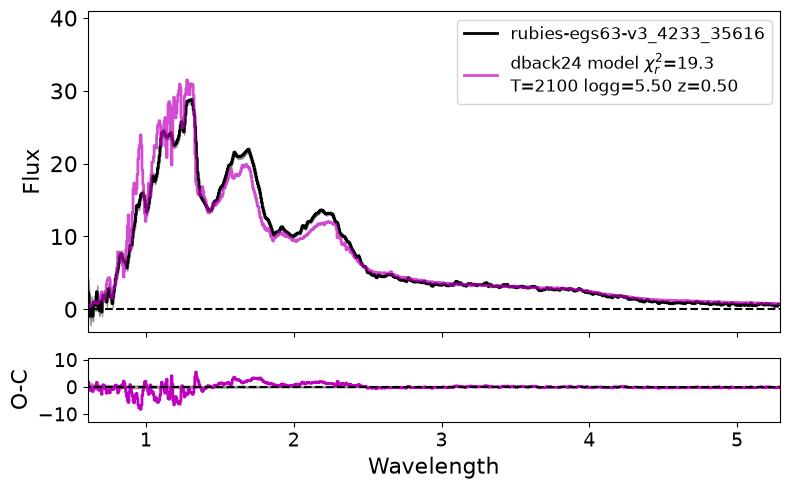

100%|██████████| 10000/10000 [00:11<00:00, 853.76it/s]


chi=16234.232915881941, scl=1.0000000000000002, dof=852


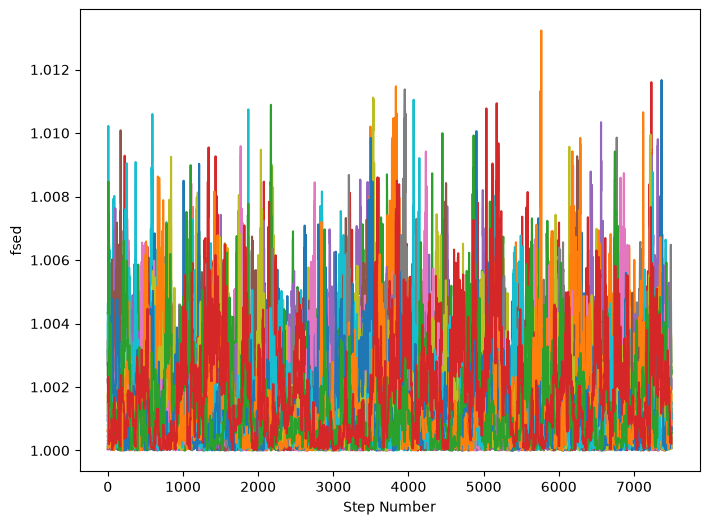

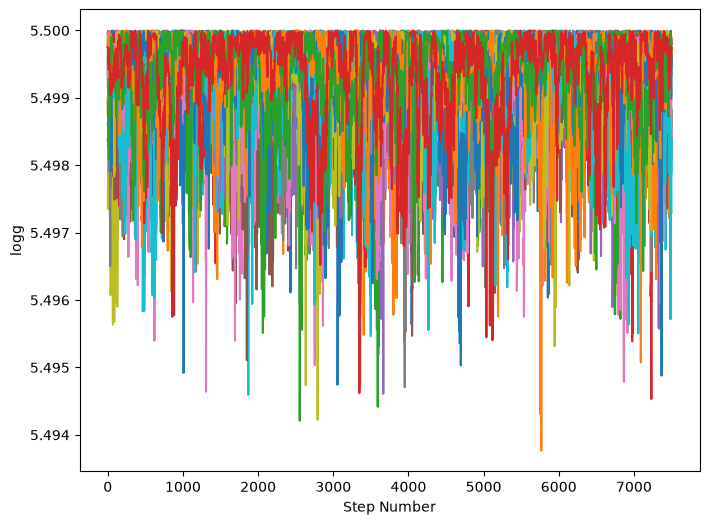

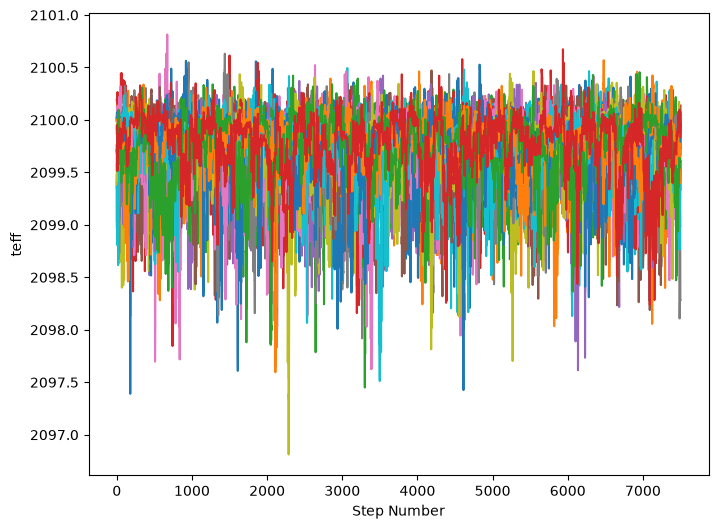

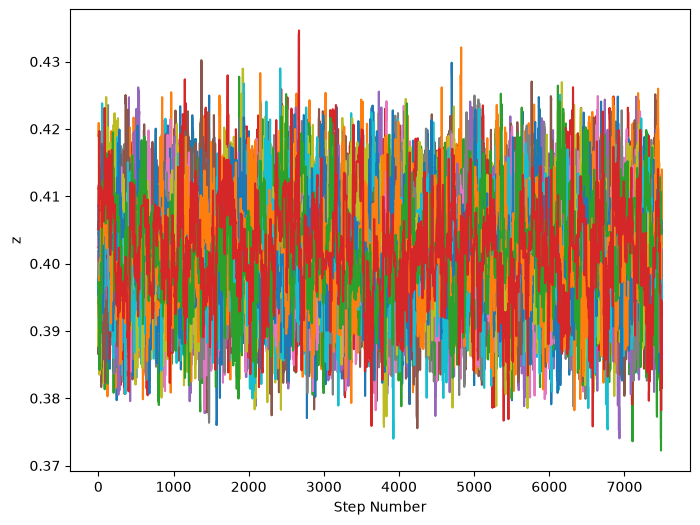

<Figure size 640x480 with 0 Axes>

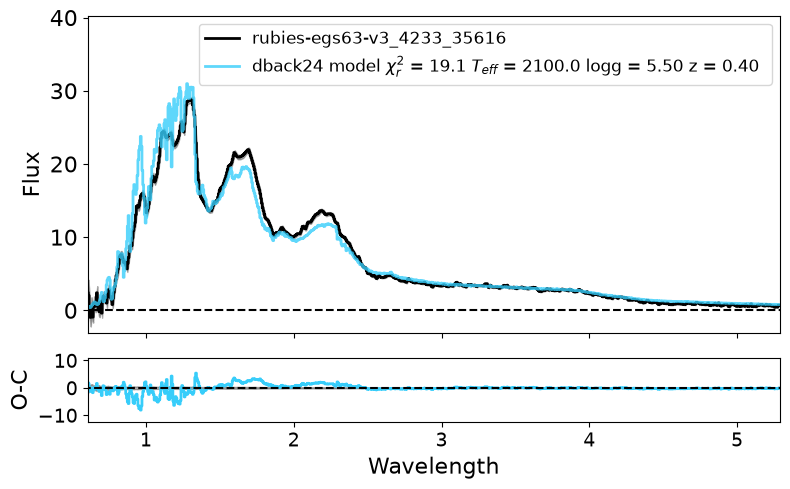

Quantiles:
[(0.16, 1.0002520107694441), (0.5, 1.0010211162426181), (0.84, 1.0026257101175902)]
Quantiles:
[(0.16, 5.498713587664382), (0.5, 5.499470669541347), (0.84, 5.499858210503832)]
Quantiles:
[(0.16, 2099.4687320606545), (0.5, 2099.8070879583906), (0.84, 2099.9976384258184)]
Quantiles:
[(0.16, 0.39457680391938865), (0.5, 0.4016836286992031), (0.84, 0.40886476717072984)]


<Figure size 640x480 with 0 Axes>

<Figure size 800x500 with 0 Axes>

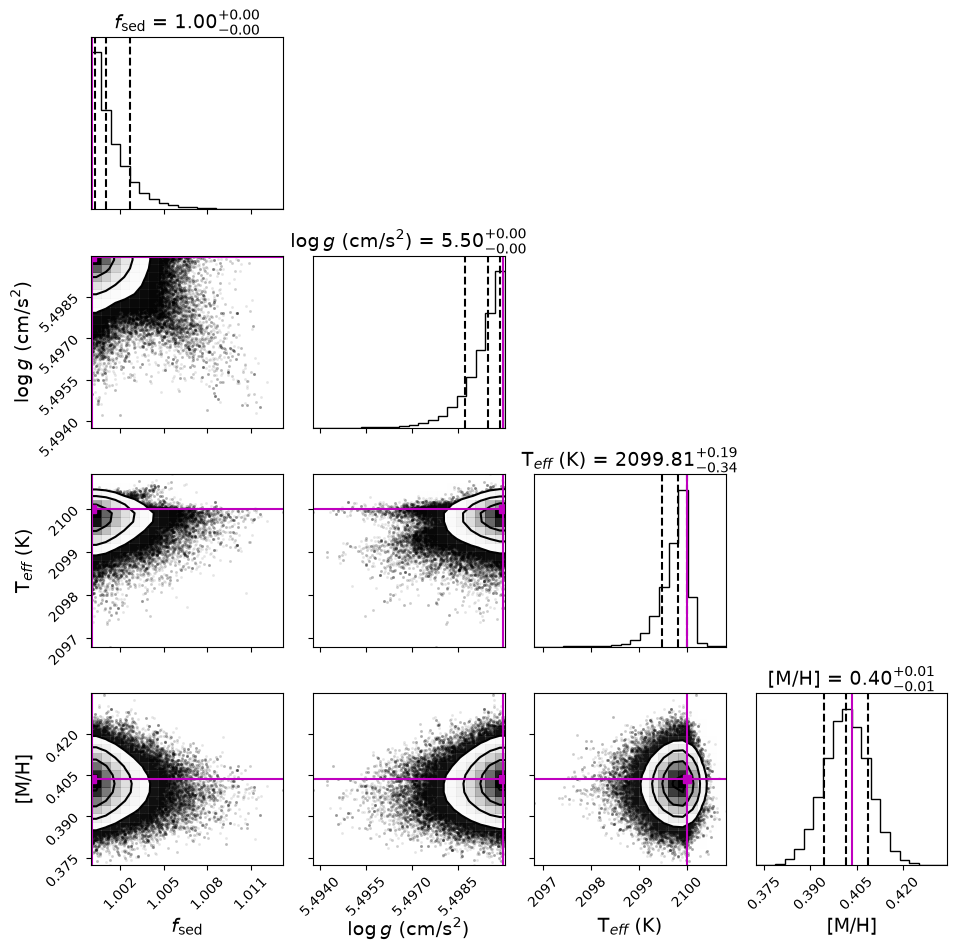

In [7]:
models, wave = getModelSet("dback24", "JWST-NIRSPEC-PRISM")
sp = TAPS.spec("/Users/epritchard/Research/TAPS/RUBIES_Sources/rubies-egs63-v3_prism-clear_4233_35616.spec.fits") # one of sarah's rubies objects 
sp.toWavelengths(wave)



gleep_ensembler = fitEMCEE(sp, models, NSTEPS=10000, initial_guess=True)

Reading in sample spectrum for instrument SPEX-PRISM of source 2MASS J0559-1404
('B', 'RO') rasied ValueError -- Grid COULD NOT be initialized (skipped)
{'broad': 'A', 'cld': 'LC'}
Constraining broad to within A
Constraining cld to within LC

Best parameters:
	model = atmos
	ad = 1.0
	broad = A
	cld = LC
	kzz = 0.0
	logg = 5.0
	logpmax = 4.0
	logpmin = -8.0
	teff = 1300.0
	z = -0.0
	scale = 5.478367986995365e-20
	chis = 53064.03798383584
	radius = 0.10381357387906431
	dof = 562.0
	rchi = 94.4199964125193


<Figure size 640x480 with 0 Axes>

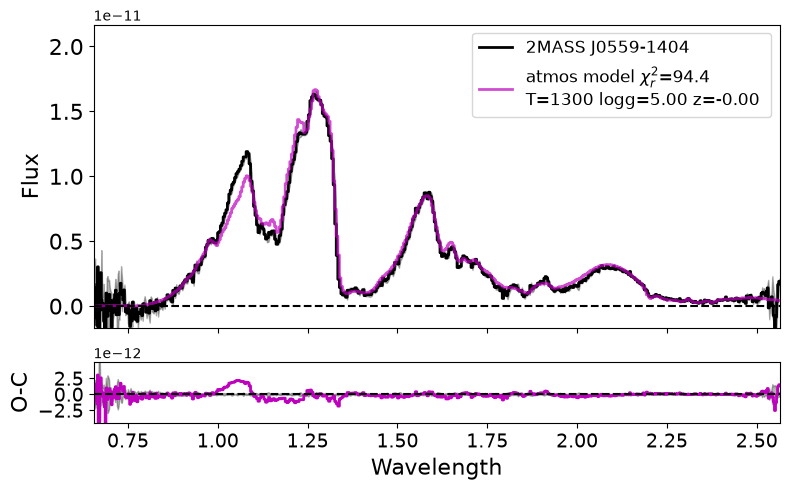

{'broad': 'A', 'cld': 'RO'}
Constraining broad to within A
Constraining cld to within RO

Best parameters:
	model = atmos
	ad = 1.0
	broad = A
	cld = RO
	kzz = 0.0
	logg = 4.5
	logpmax = 4.0
	logpmin = -8.0
	teff = 1300.0
	z = -0.0
	scale = 5.497293276108107e-20
	chis = 39875.34636661155
	radius = 0.1039927338076278
	dof = 562.0
	rchi = 70.95257360607037


<Figure size 640x480 with 0 Axes>

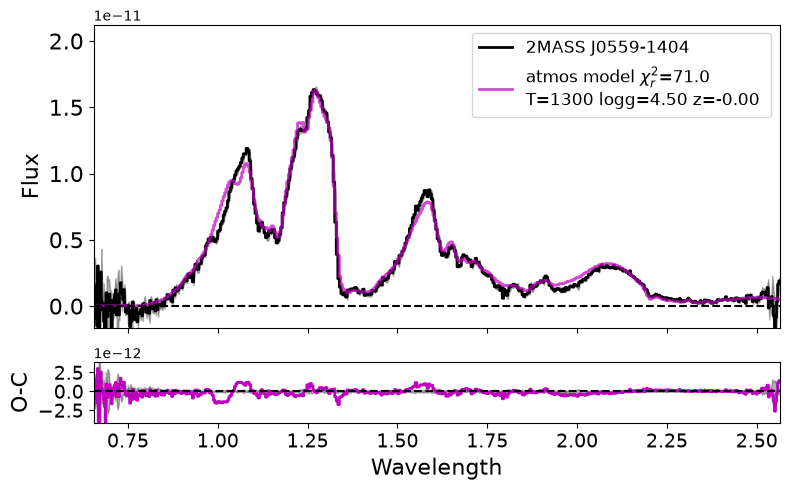

{'broad': 'B', 'cld': 'LC'}
Constraining broad to within B
Constraining cld to within LC

Best parameters:
	model = atmos
	ad = 1.0
	broad = B
	cld = LC
	kzz = 0.0
	logg = 4.5
	logpmax = 4.0
	logpmin = -8.0
	teff = 1300.0
	z = -0.0
	scale = 5.326999977590408e-20
	chis = 204954.67067697423
	radius = 0.10236933671169804
	dof = 562.0
	rchi = 364.6880261156125


<Figure size 640x480 with 0 Axes>

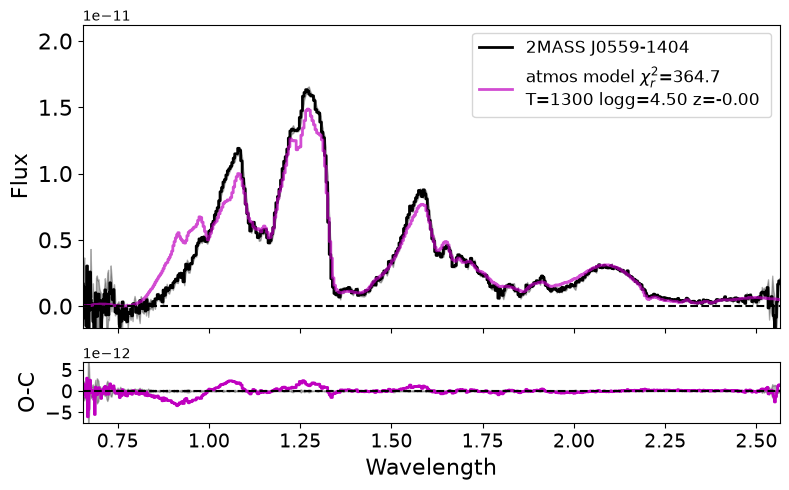

{'broad': 'B', 'cld': 'RO'}
Constraining broad to within B
Constraining cld to within RO
Key: ('B', 'RO') does not have a grid -- skipped


100%|██████████| 10000/10000 [00:05<00:00, 1958.16it/s]


chi=34776.40214129289, scl=0.9999999999999999, dof=562


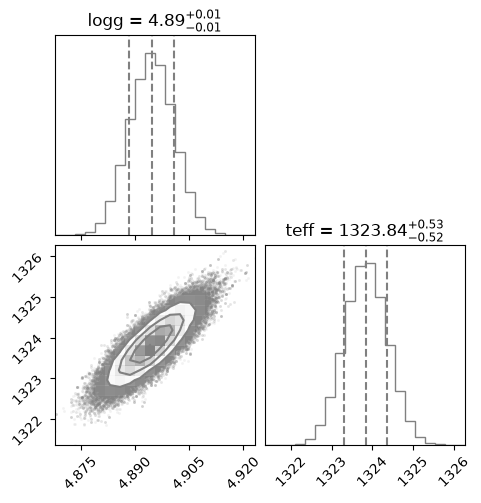

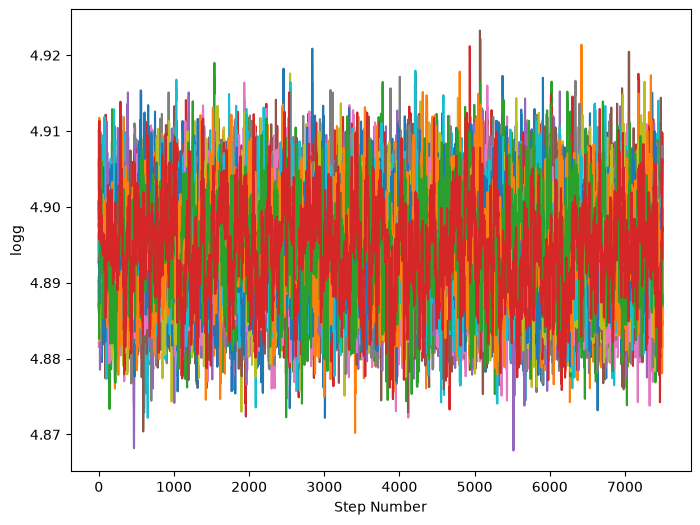

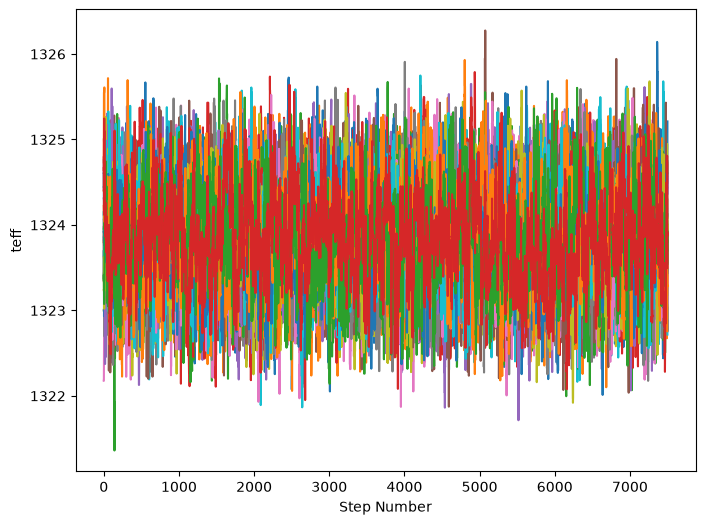

<Figure size 640x480 with 0 Axes>

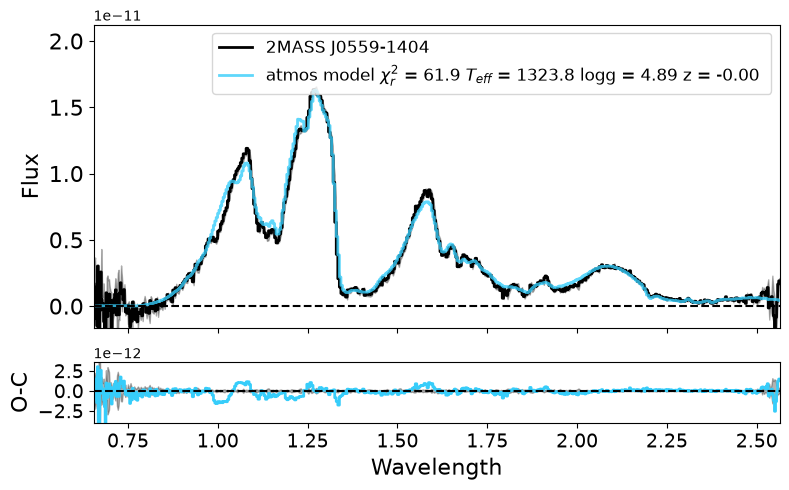

In [48]:
models, wave = getModelSet("atmo20", "SPEX-PRISM")
sp = getSample(instrument="SPEX-PRISM")
# sp = TAPS.spec("/Users/epritchard/Research/TAPS/RUBIES_Sources/rubies-egs63-v3_prism-clear_4233_35616.spec.fits")
# sp.toWavelengths(wave)

gleep_ensembler = fitEMCEE(sp, models, NSTEPS=10000, initial_guess=True)

In [52]:
((-2 * np.nanmax(gleep_ensembler.EnsembleSampler.get_log_prob())) - np.log(2*np.pi*gleep_ensembler.spectrum.noise.value))[20:40]

array([14755.54844551, 14756.14021966, 14756.18813512, 14755.89128027,
       14755.83862405, 14755.85637555, 14756.39698877, 14756.197247  ,
       14756.21557279, 14756.31640236, 14755.97724724, 14756.2149097 ,
       14756.26718251, 14756.1099993 , 14756.40387319, 14756.48141204,
       14756.53084553, 14756.56183679, 14756.56788095, 14756.52849331])

In [42]:
gleep_ensembler.emcee_flatchain_argmax

array([1.00031284e+00, 5.49998295e+00, 2.09996408e+03, 4.02724754e-01])

In [79]:
(-2 * np.nanmax(gleep_ensembler.EnsembleSampler.get_log_prob()) - np.nansum(np.log(2*np.pi*gleep_ensembler.spectrum.noise.value**2)))

17191.34824859973

In [84]:
np.nanmin((-2 * gleep_ensembler.EnsembleSampler.get_log_prob() - np.nansum(np.log(2*np.pi*gleep_ensembler.spectrum.noise.value**2))))

17191.34824859973